Loaded EEG segment: 106944 samples x 32 channels
Segment: [814.571, 921.515] sec
Using scales: [    5     6     8    10    14    18    24    31    40    52    68    89
   116   151   196   255   331   431   560   727   945  1229  1597  2076
  2697  3506  4556  5921  7694 10000]


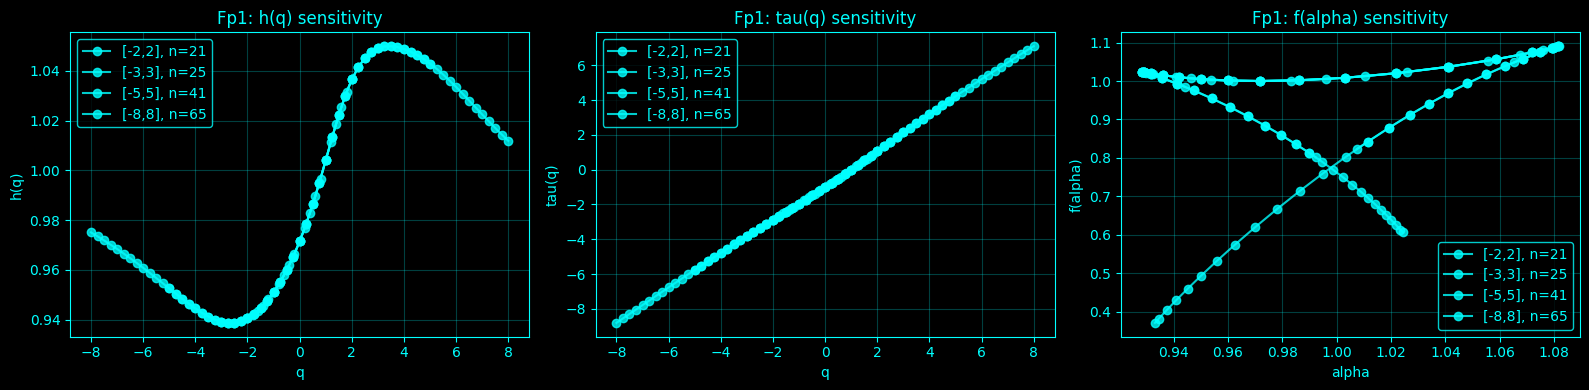

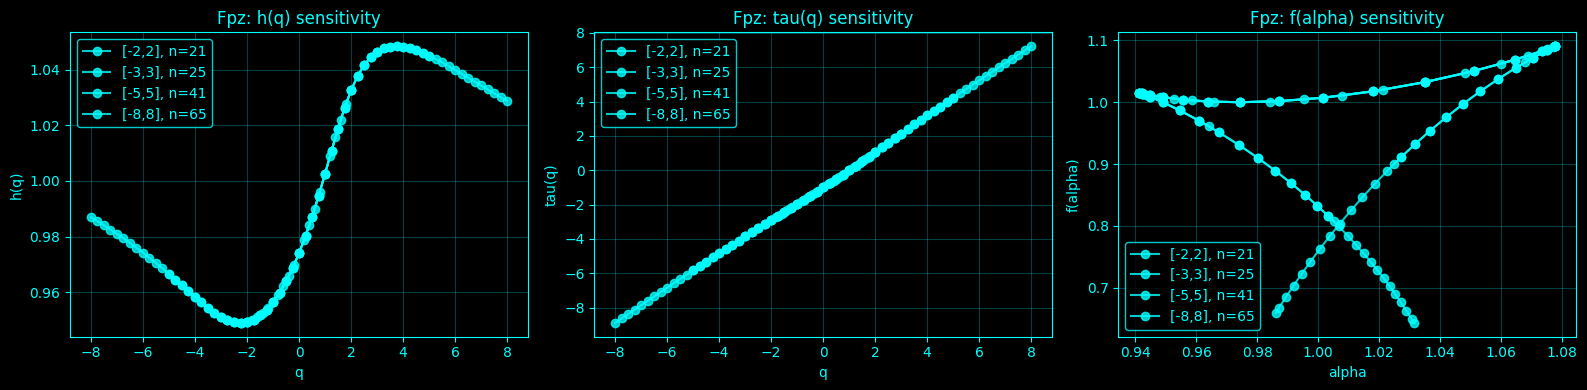

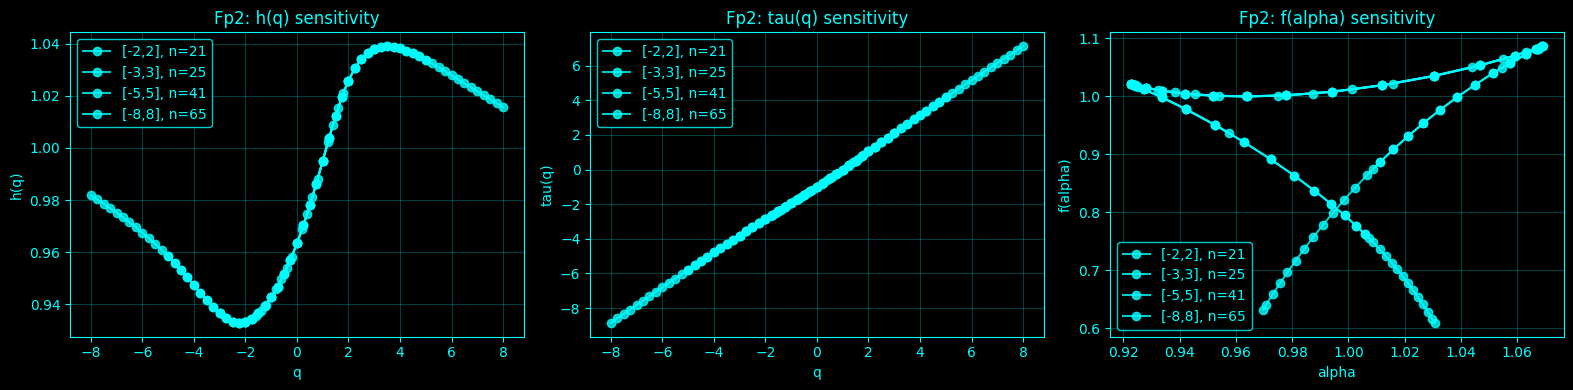

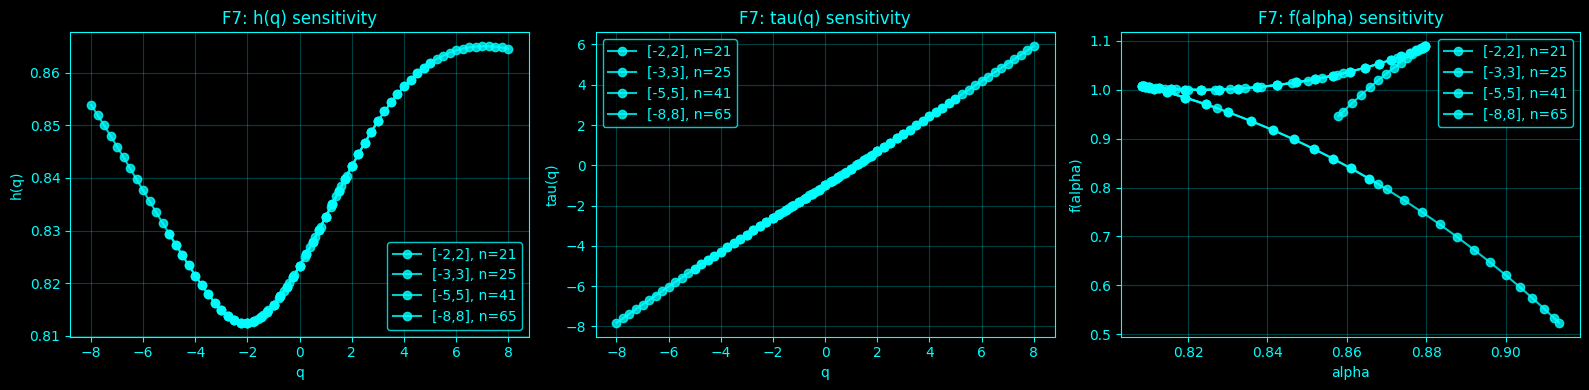

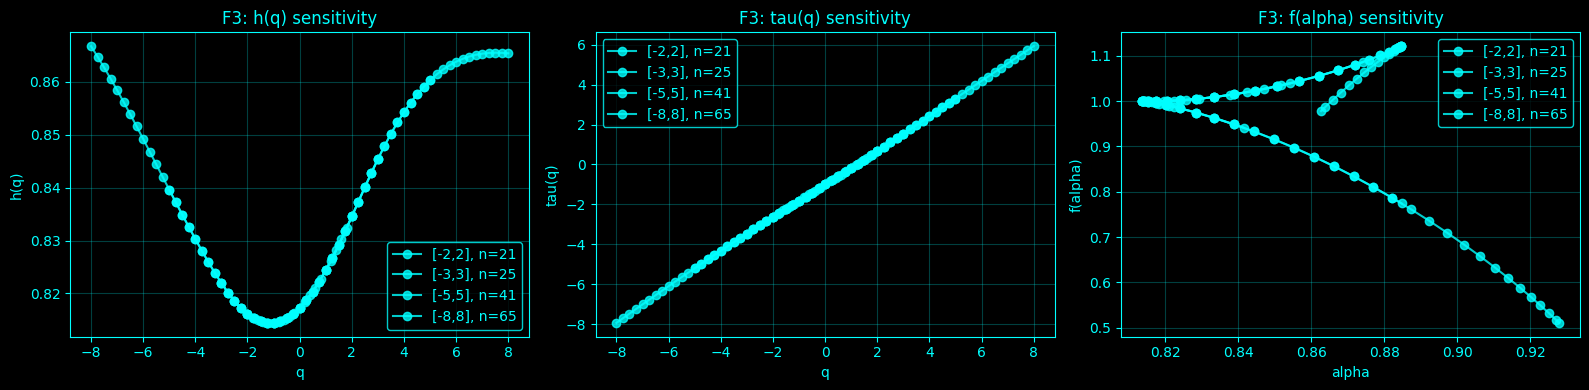

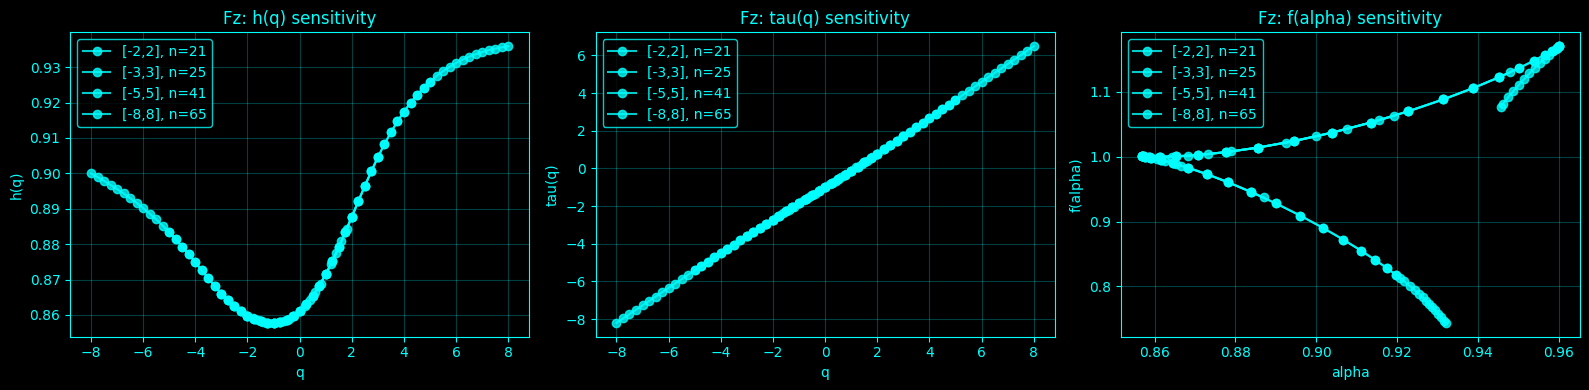

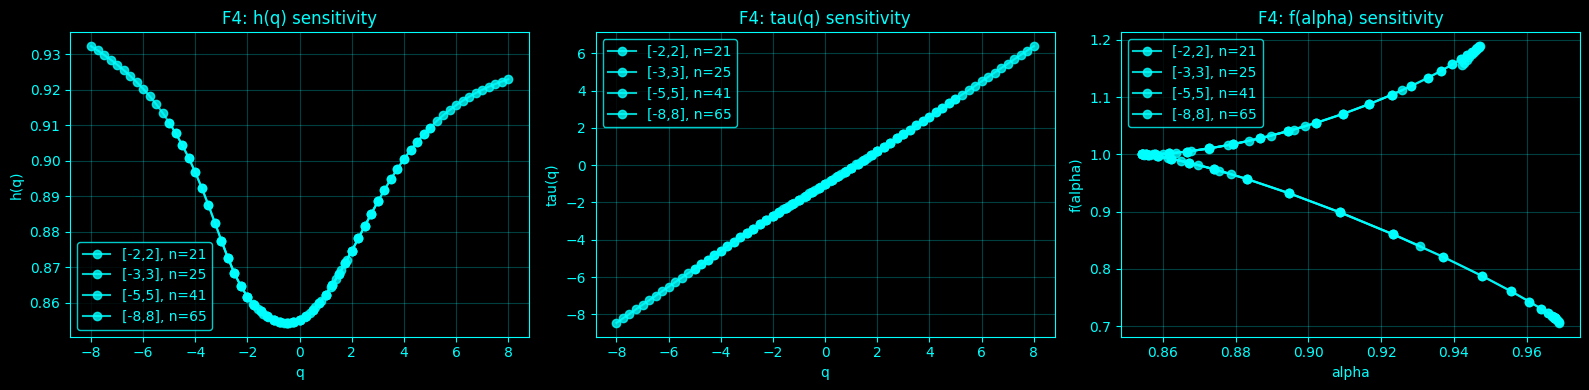

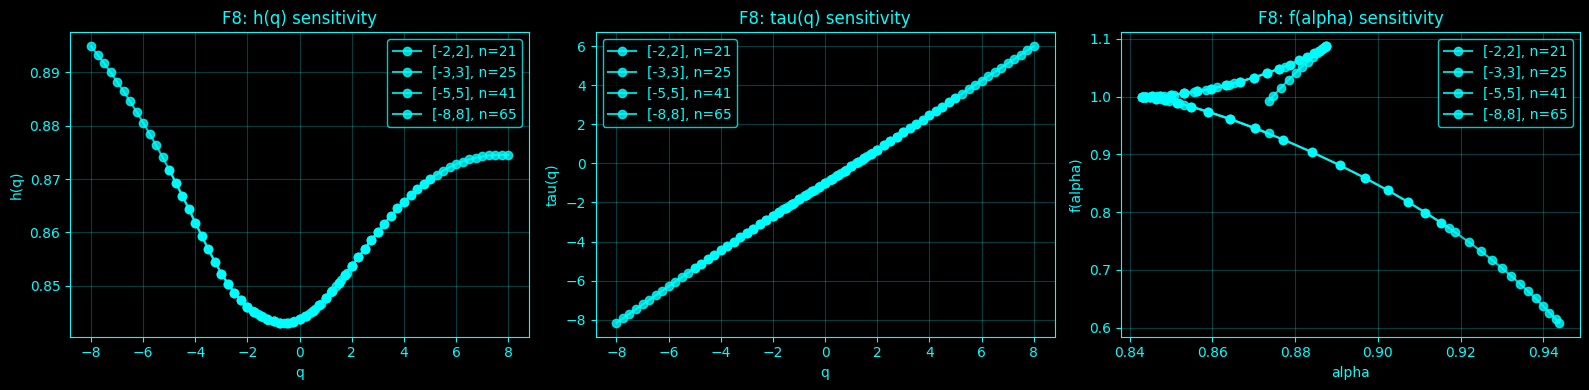

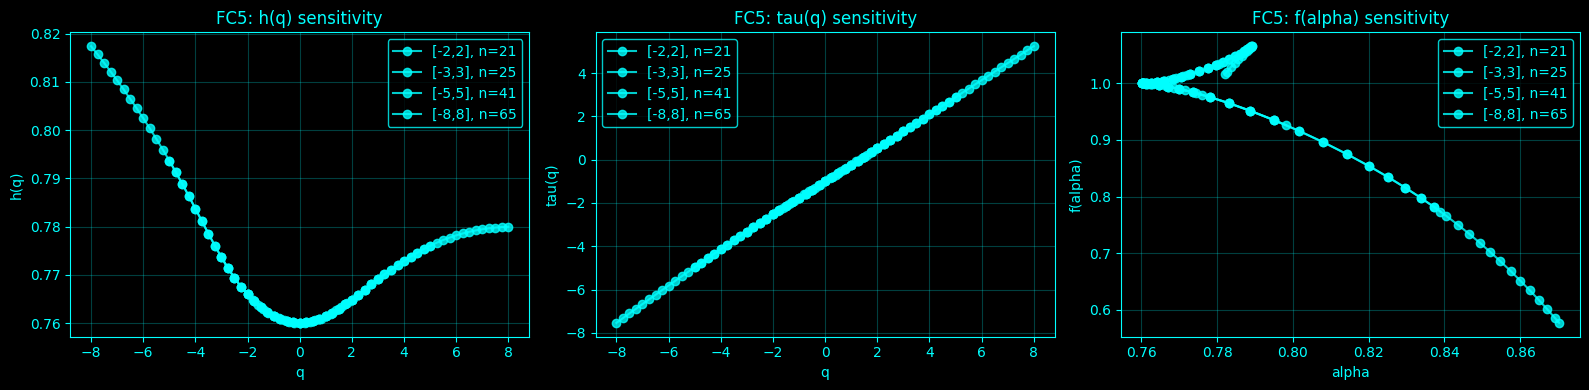

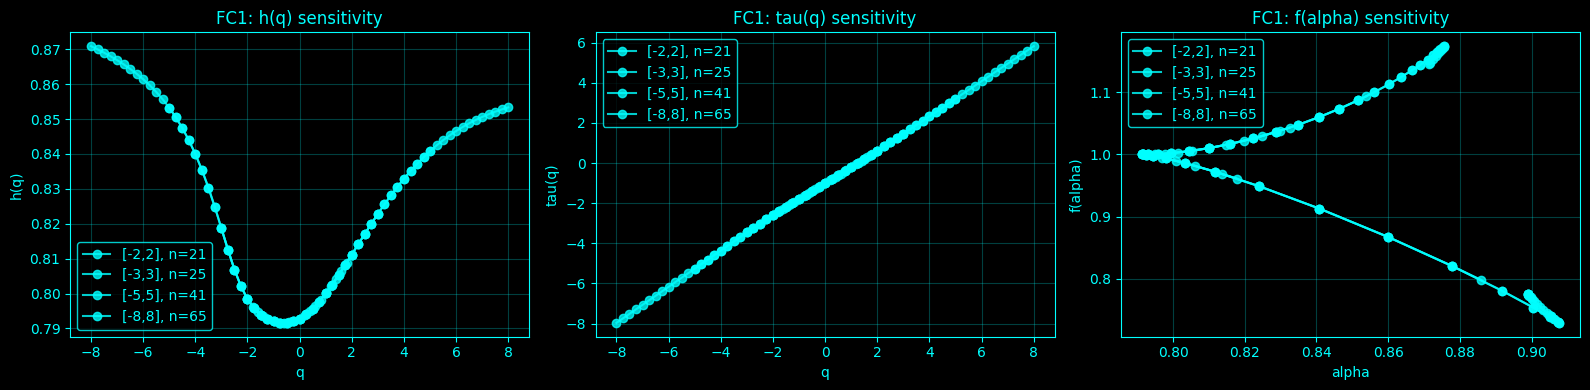

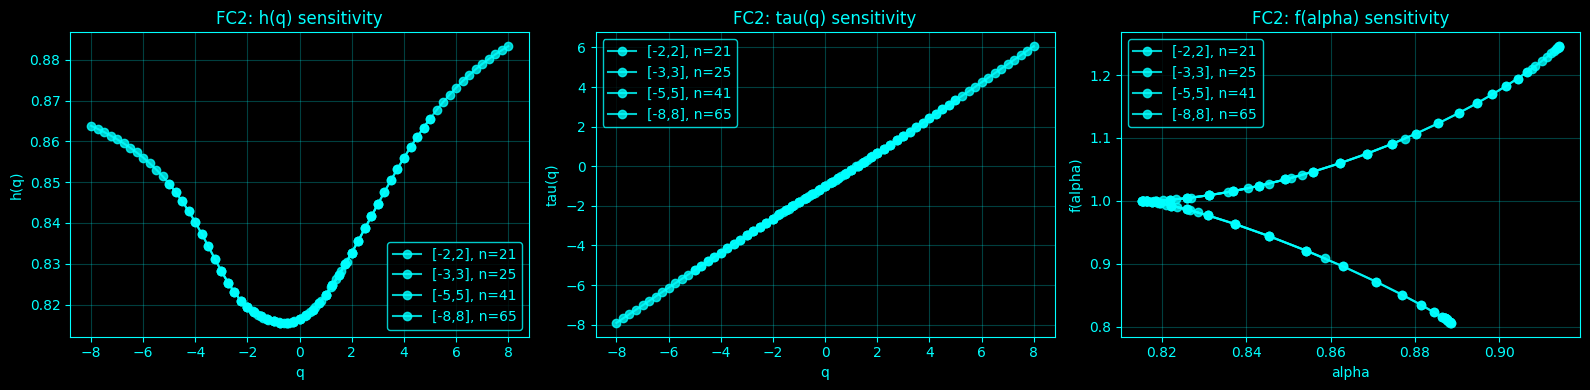

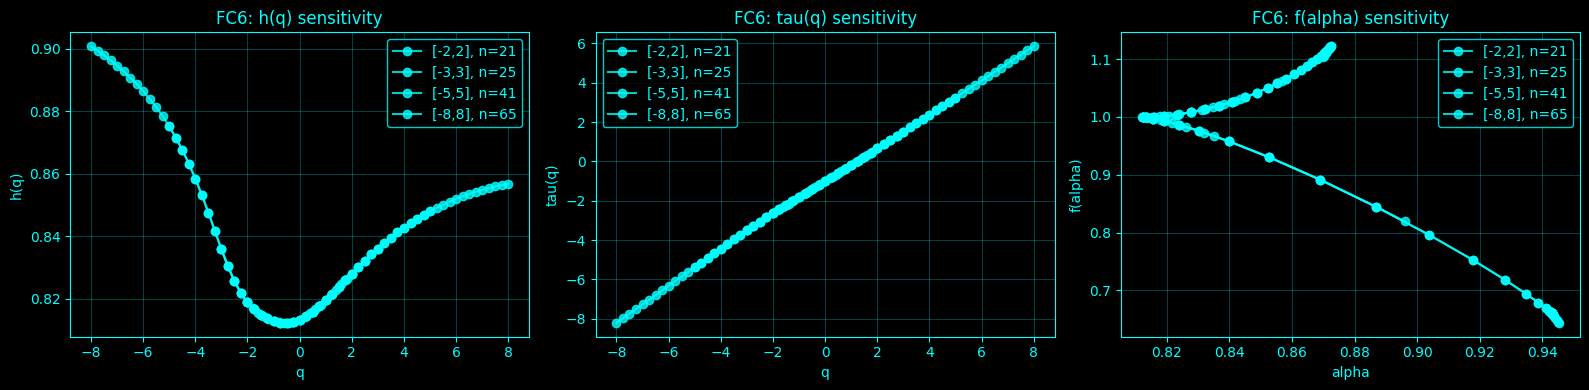

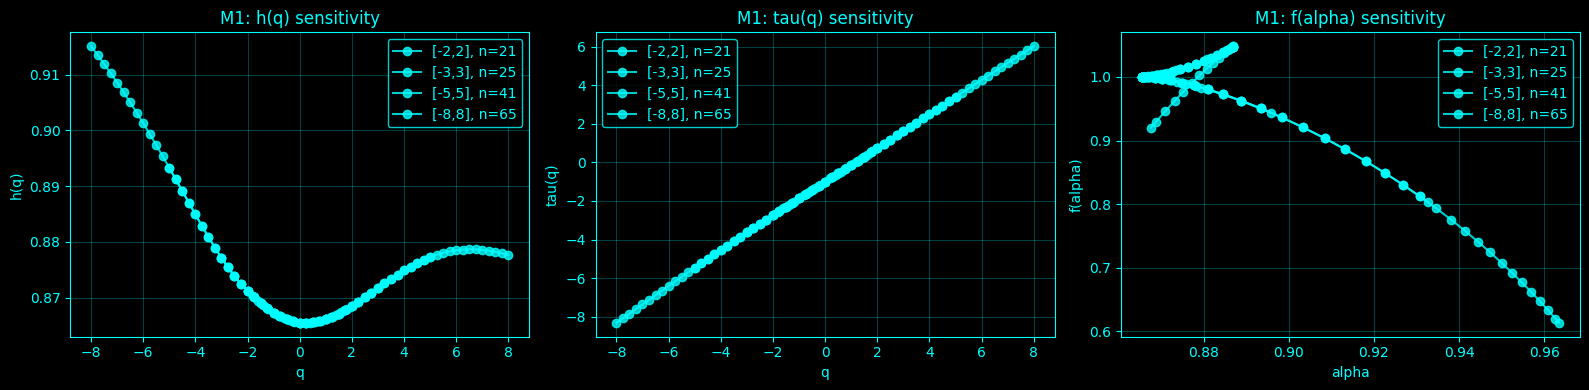

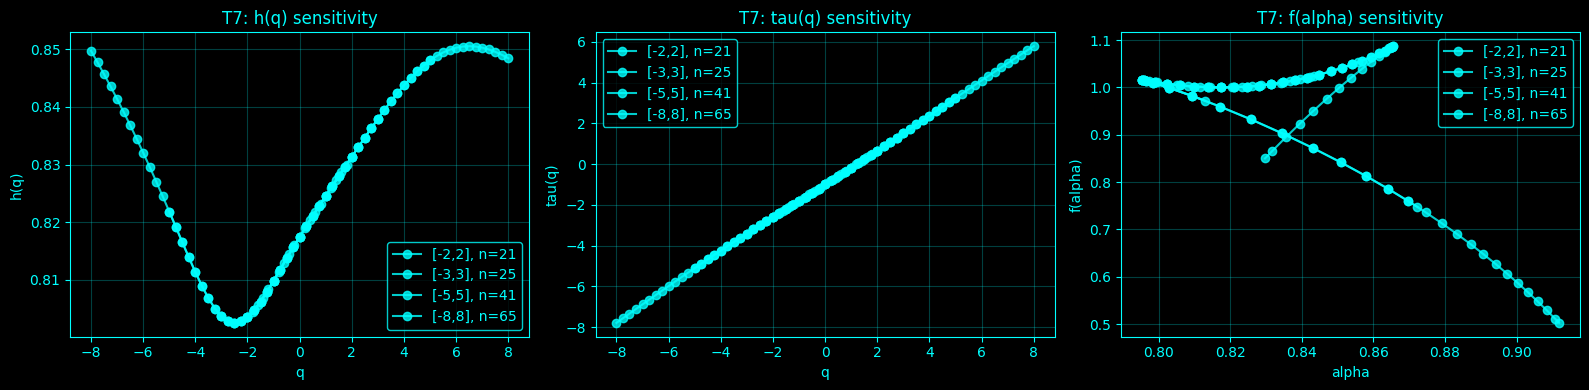

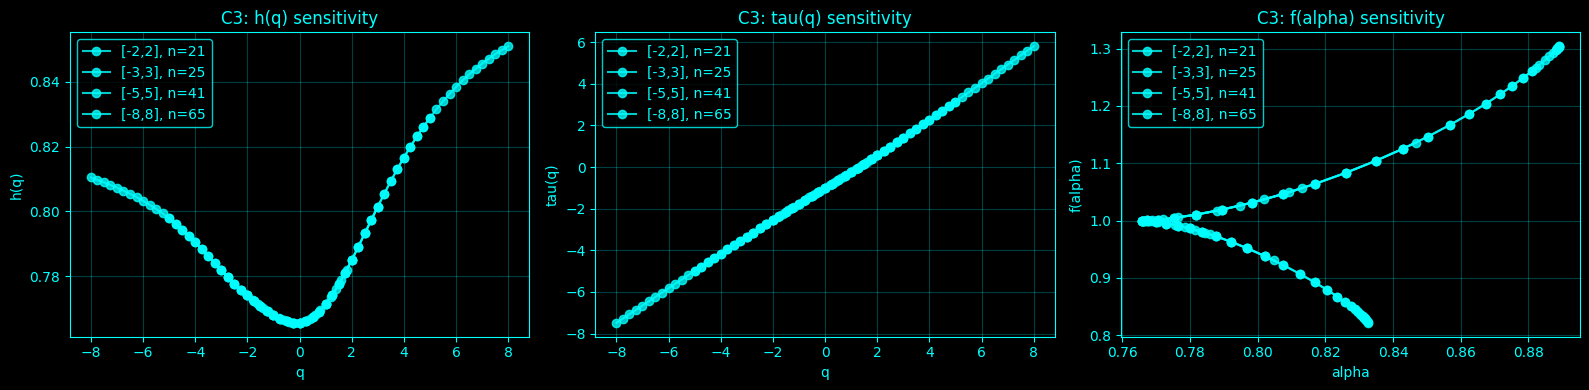

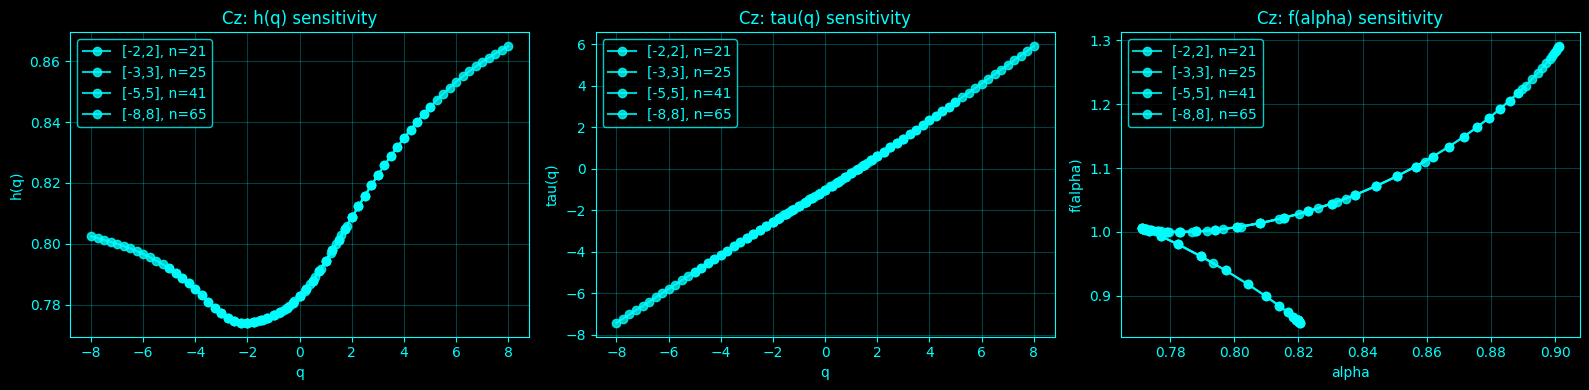

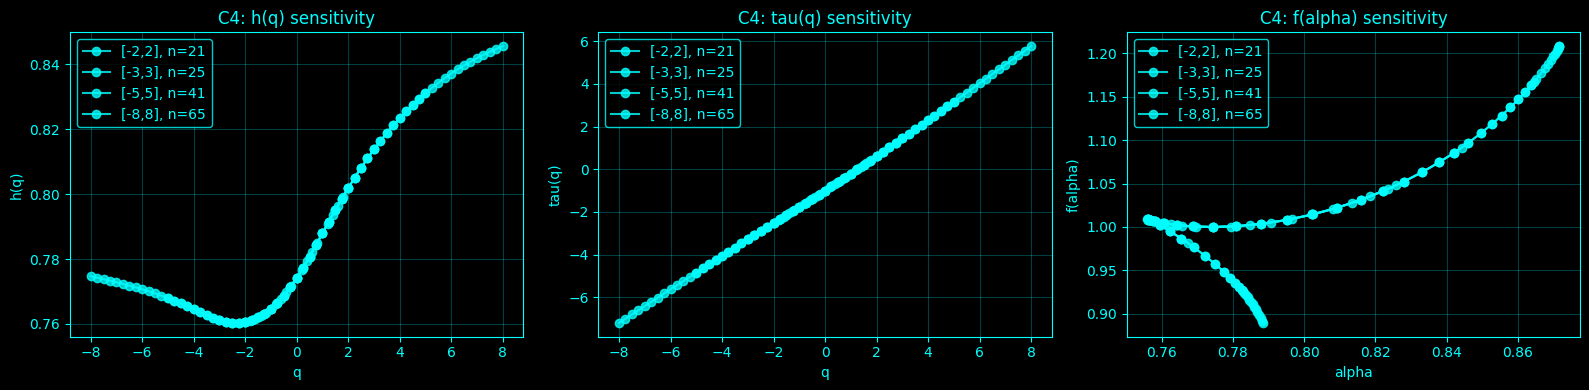

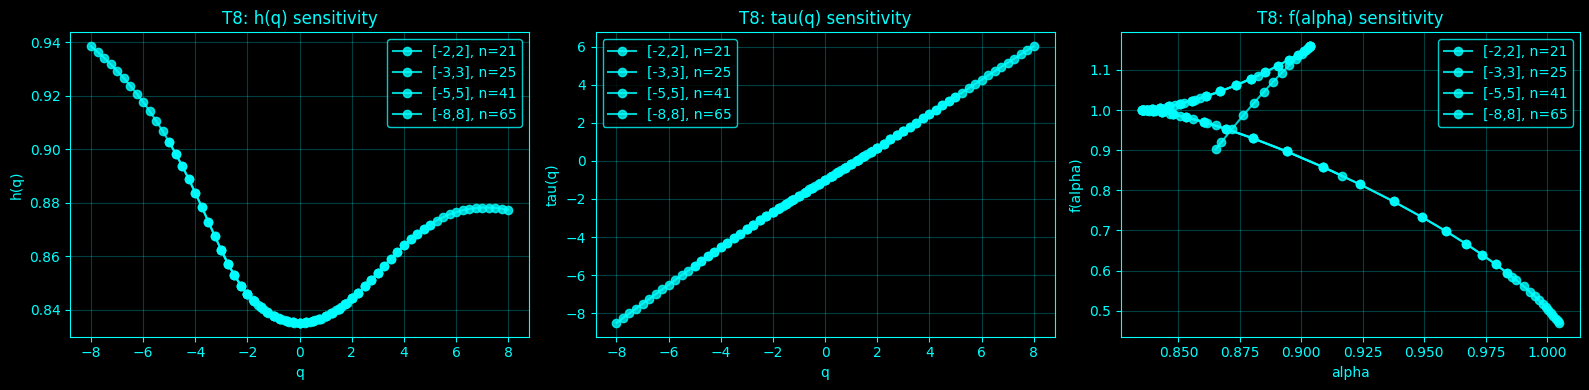

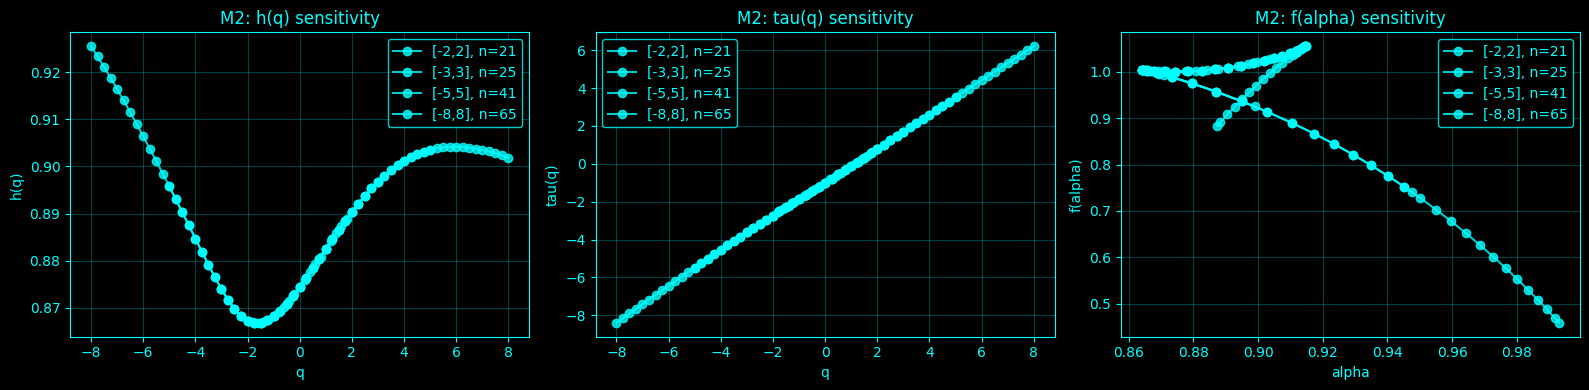

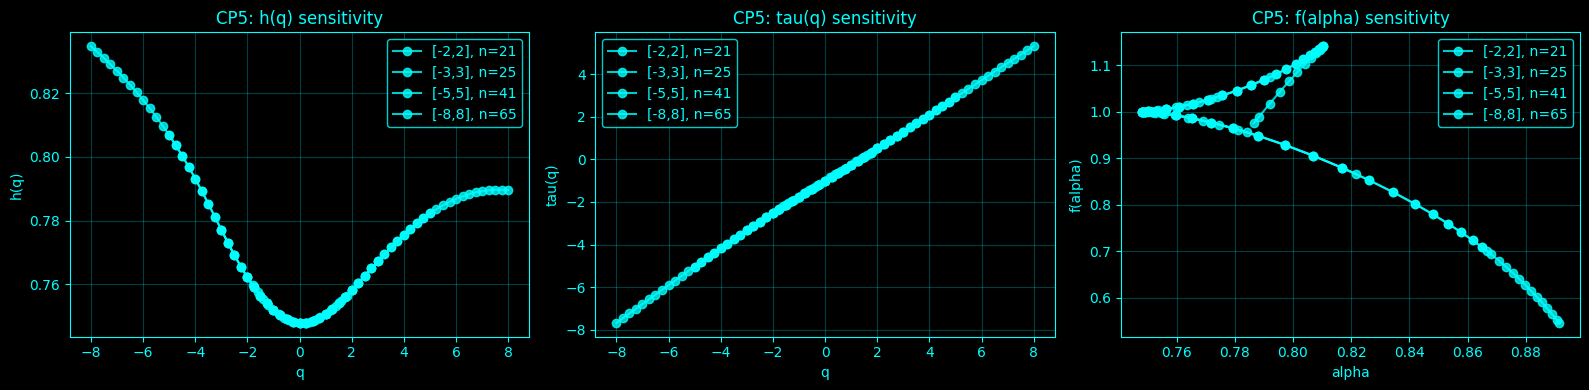

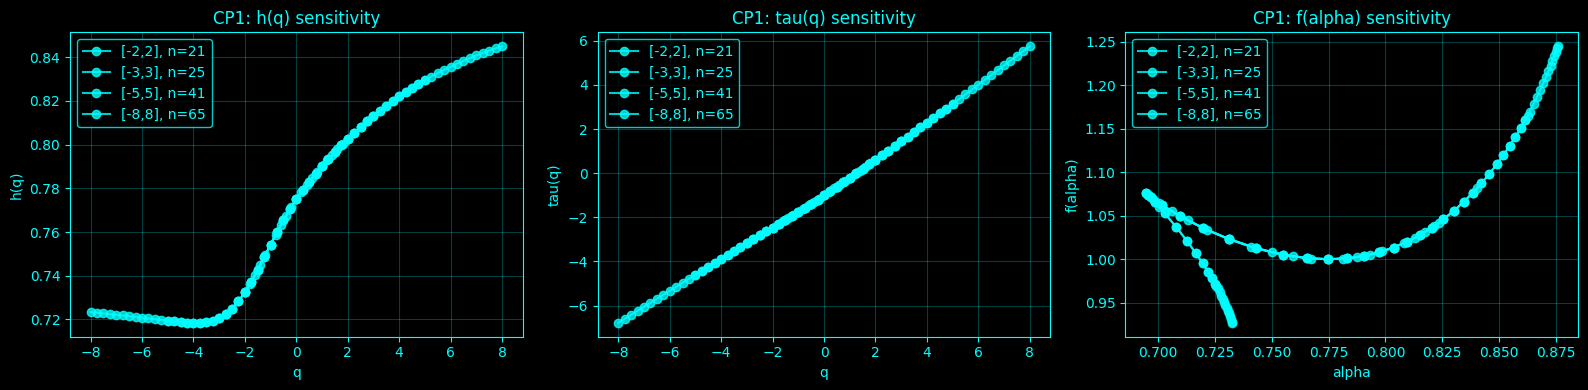

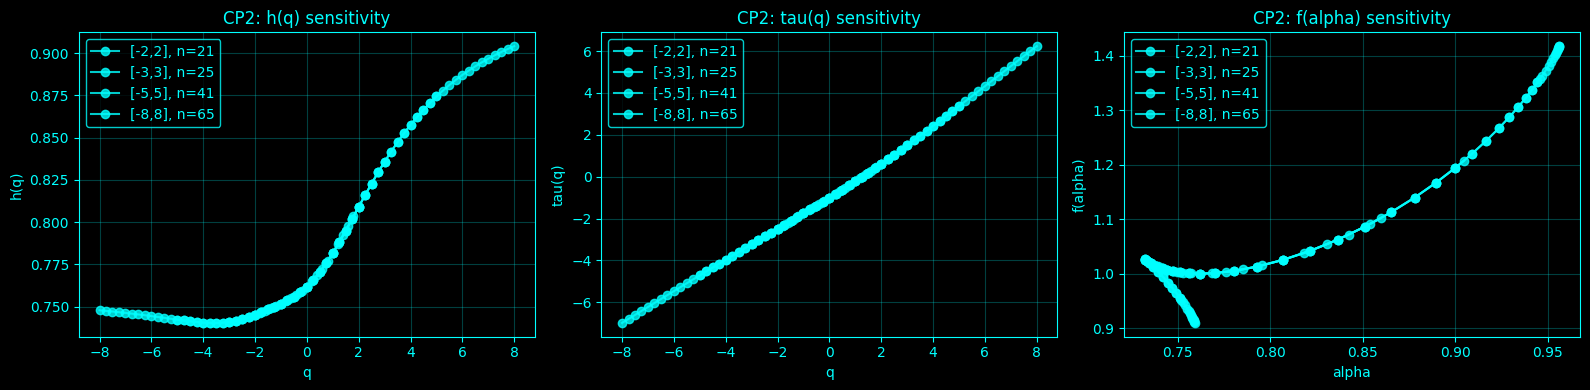

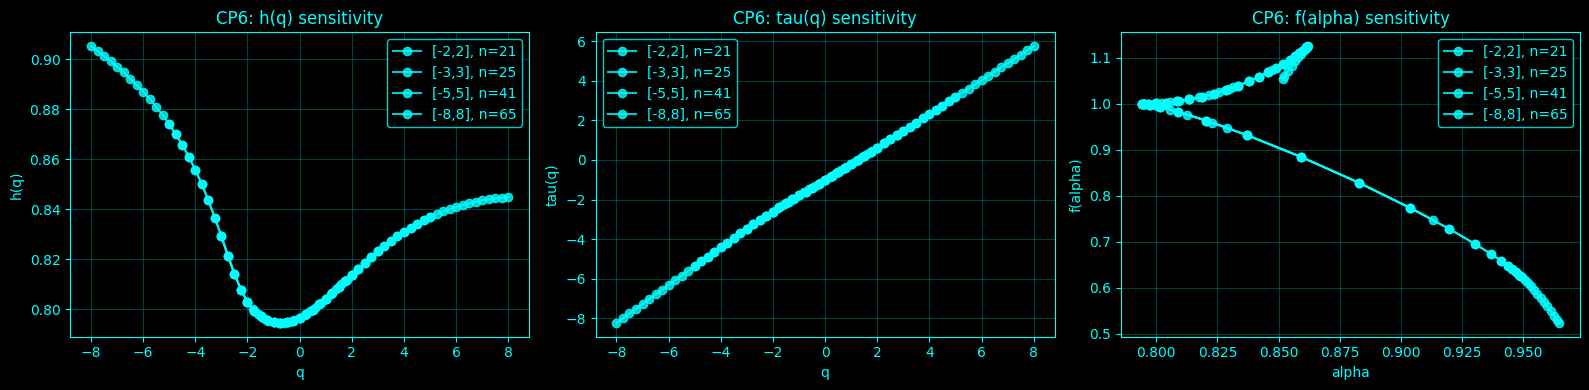

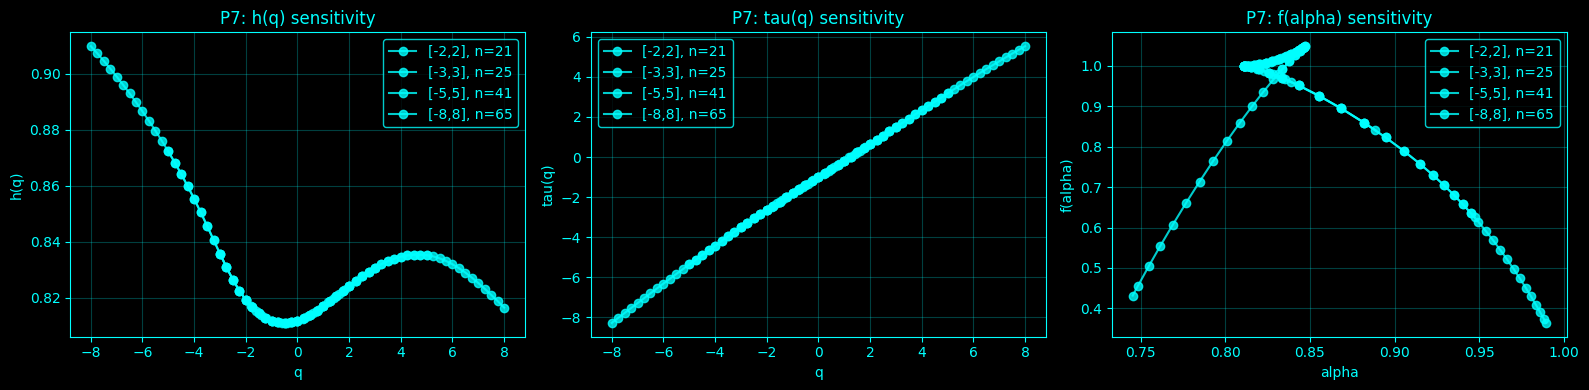

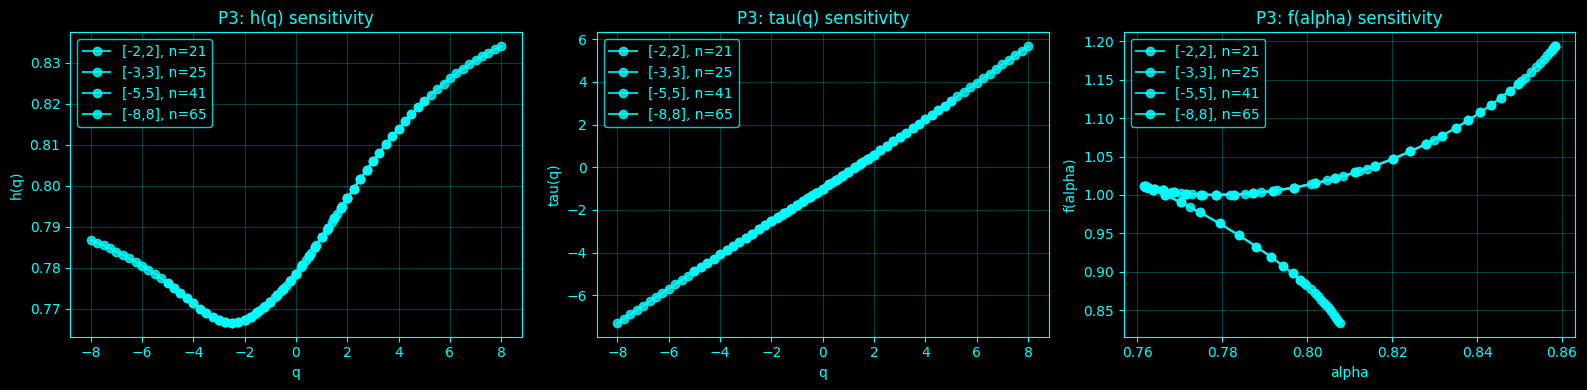

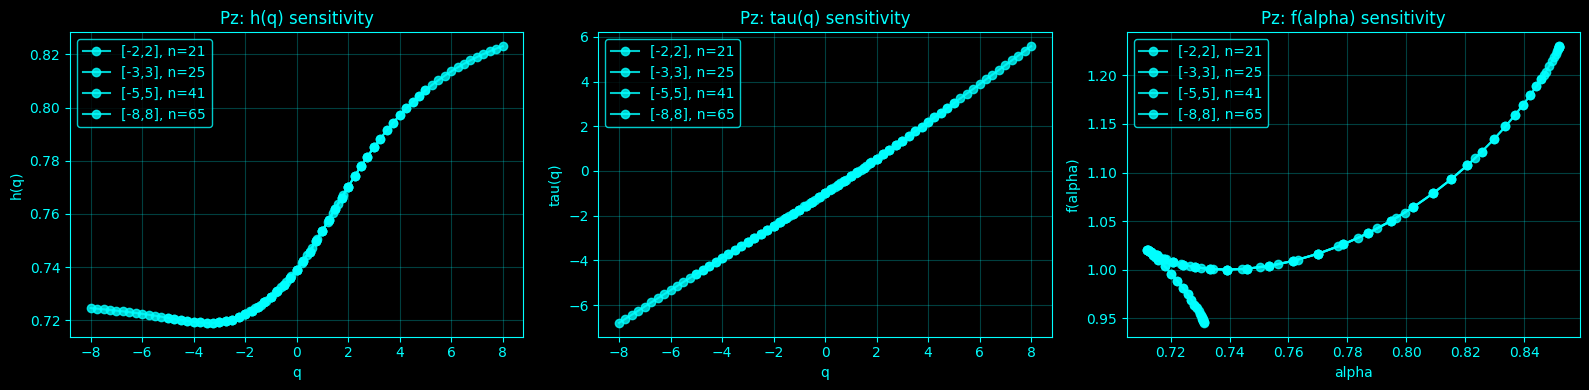

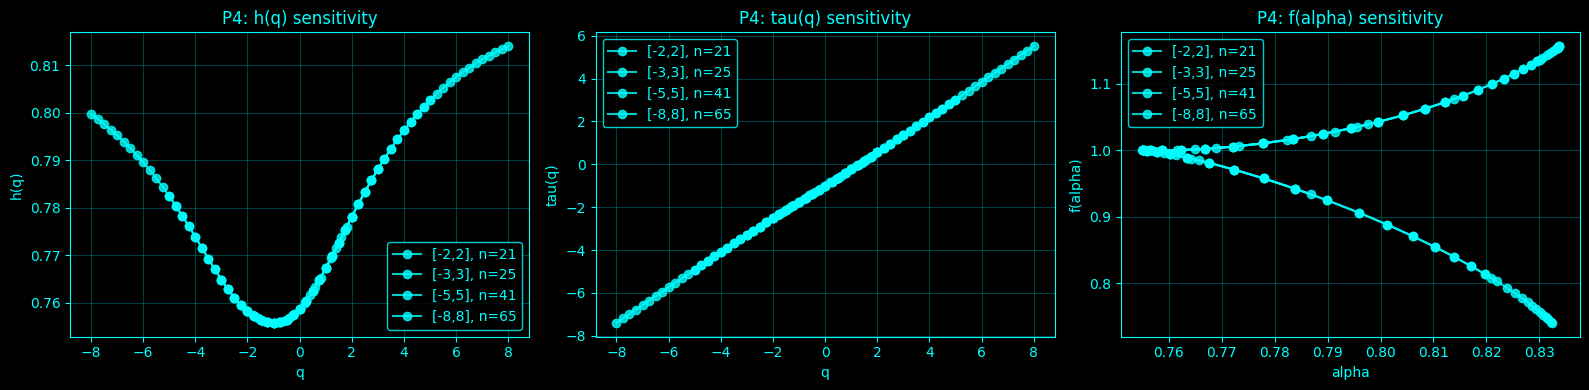

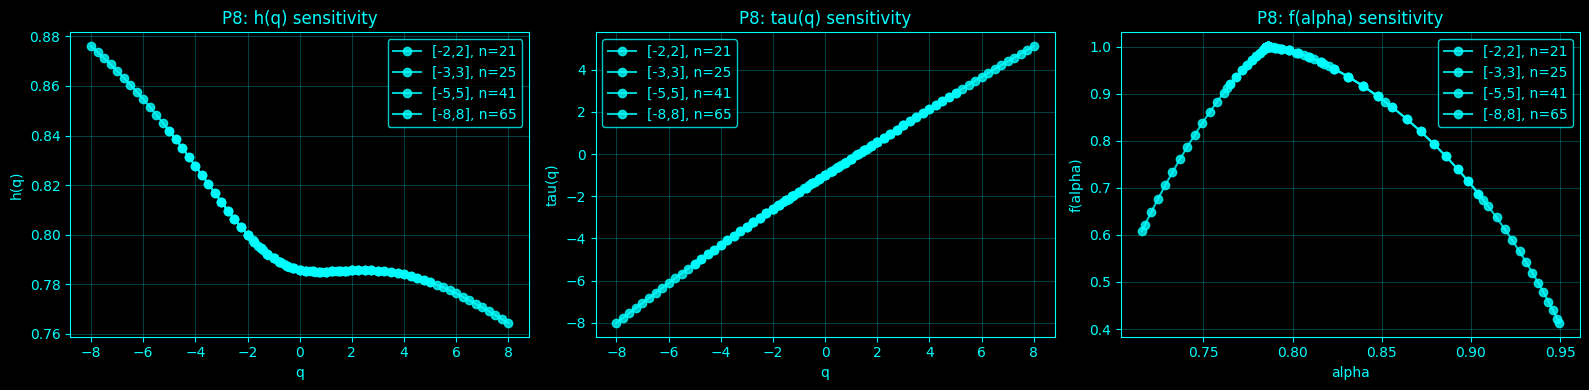

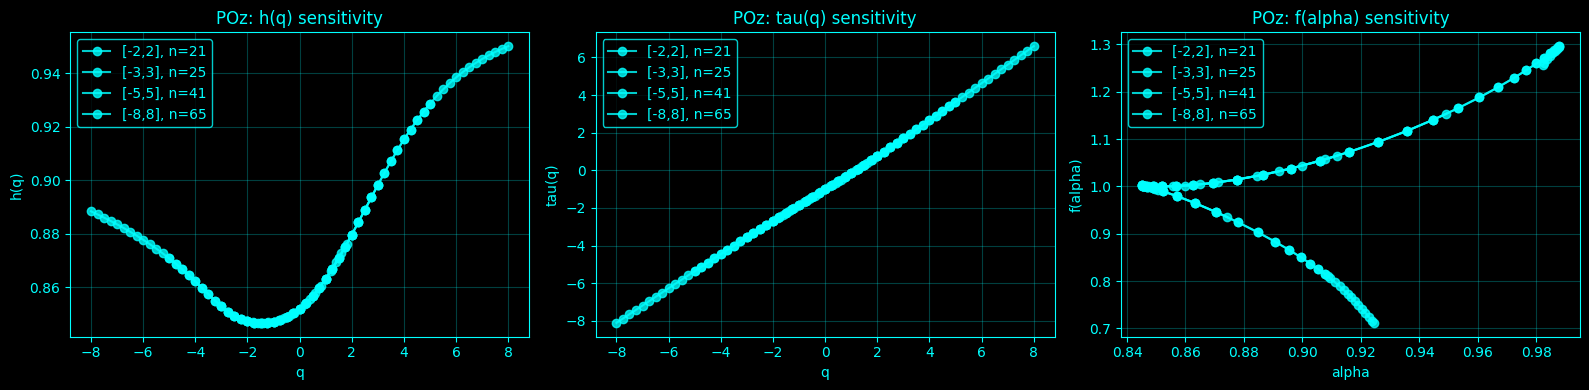

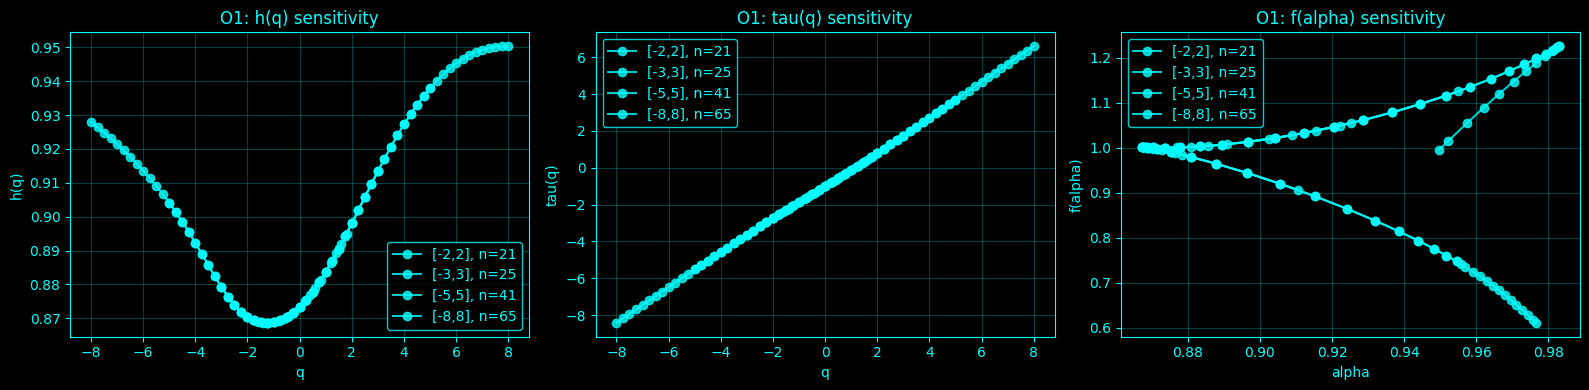

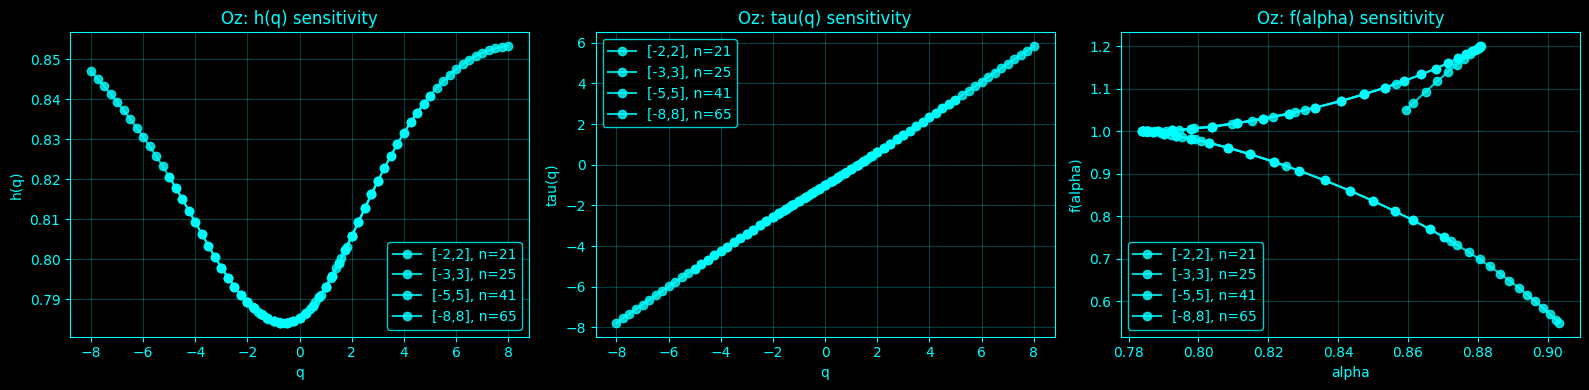

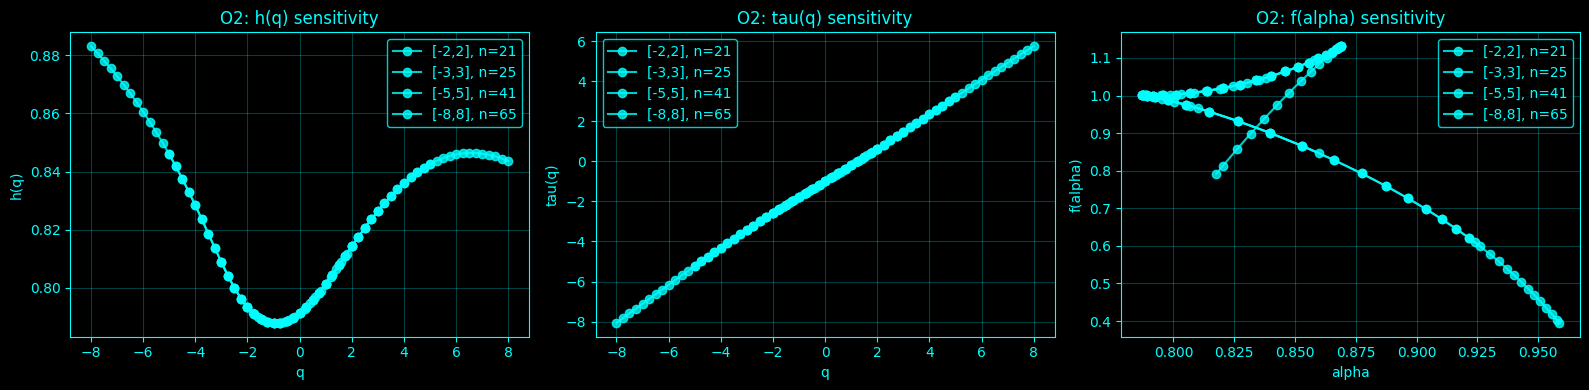


Q-range sensitivity summary:
    channel  q_min  q_max  n_q  alpha_min  alpha_max  alpha_width  \
0       Fp1     -2      2   21   0.928341   1.081800     0.153459   
1       Fp1     -3      3   25   0.928410   1.081400     0.152990   
2       Fp1     -5      5   41   0.928410   1.081400     0.152990   
3       Fp1     -8      8   65   0.928410   1.081400     0.152990   
4       Fpz     -2      2   21   0.941259   1.077269     0.136010   
..      ...    ...    ...  ...        ...        ...          ...   
123      Oz     -8      8   65   0.783980   0.903317     0.119337   
124      O2     -2      2   21   0.786999   0.837875     0.050876   
125      O2     -3      3   25   0.787248   0.859719     0.072470   
126      O2     -5      5   41   0.787248   0.923863     0.136615   
127      O2     -8      8   65   0.787248   0.958658     0.171409   

     alpha_at_peak    f_peak  asymmetry    h_qmin    h_qmax   delta_h  
0         1.081800  1.090666  -0.153459  0.940576  1.036467  0.095890

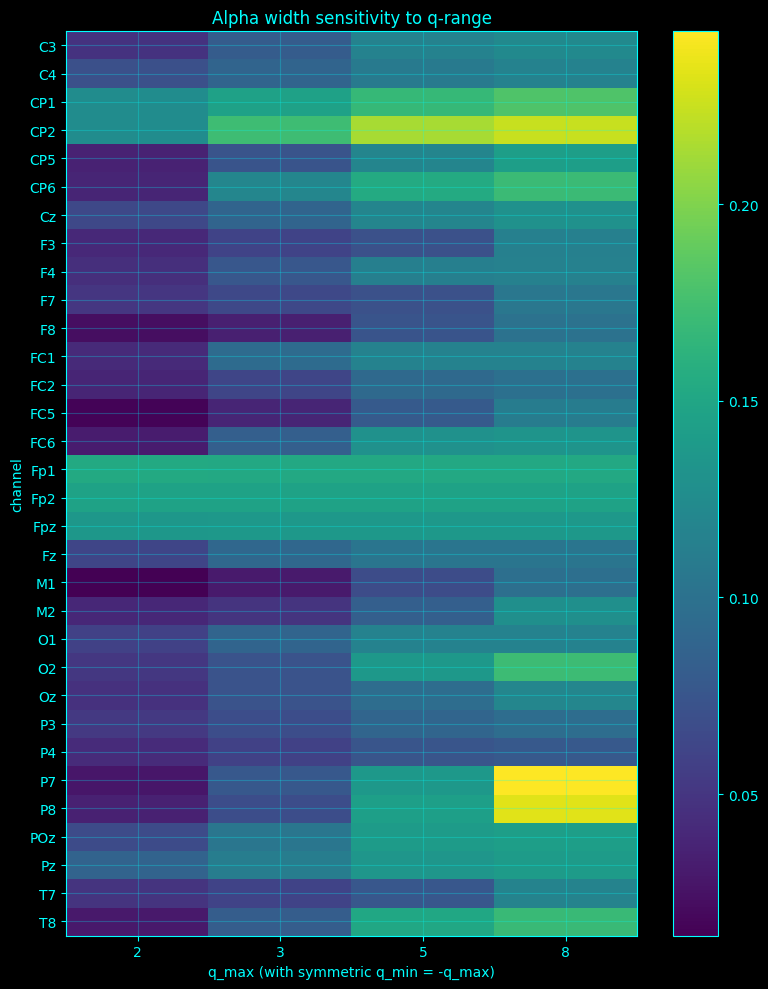


Saved outputs to: /home/a/projects/Complete-Neural-Signal-Analysis/mfdfa_qrange_sensitivity
Saved summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/mfdfa_qrange_sensitivity/qrange_sensitivity_summary.csv


In [12]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")
out_dir = os.path.join(base_dir, "mfdfa_qrange_sensitivity")
os.makedirs(out_dir, exist_ok=True)

# Same segment as before
sampling_rate = 1000
start_time, end_time = 814.571, 921.515
start_idx = int(start_time * sampling_rate)
end_idx   = int(end_time * sampling_rate)

eeg_channels = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

# Run all channels; change to ["C3"] if you want a lighter run
channels_to_run = eeg_channels.copy()

# q-range sensitivity settings
q_range_specs = [
    (-2,  2, 21),
    (-3,  3, 25),
    (-5,  5, 41),
    (-8,  8, 65),
]

poly_order = 1
lag = np.logspace(0.7, 4, 30).astype(int)
lag = np.unique(lag)

# Plot style
ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.grid(True, alpha=0.25, color=ACCENT)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
    ax.xaxis.label.set_color(ACCENT)
    ax.yaxis.label.set_color(ACCENT)
    ax.title.set_color(ACCENT)

def mfdfa_manual(x, scales, q_vals, order=1):
    x = np.asarray(x, dtype=float)
    N = len(x)
    profile = np.cumsum(x - np.mean(x))
    Fq = np.full((len(scales), len(q_vals)), np.nan, dtype=float)

    for si, s in enumerate(scales):
        s = int(s)
        Ns = N // s
        if Ns < 2:
            continue

        F2_segments = []

        # forward
        for v in range(Ns):
            start = v * s
            stop = start + s
            seg = profile[start:stop]
            t = np.arange(s)
            coeffs = np.polyfit(t, seg, order)
            trend = np.polyval(coeffs, t)
            F2_segments.append(np.mean((seg - trend) ** 2))

        # backward
        for v in range(Ns):
            start = N - (v + 1) * s
            stop = start + s
            seg = profile[start:stop]
            t = np.arange(s)
            coeffs = np.polyfit(t, seg, order)
            trend = np.polyval(coeffs, t)
            F2_segments.append(np.mean((seg - trend) ** 2))

        F2_segments = np.asarray(F2_segments, dtype=float)
        F2_segments = np.maximum(F2_segments, 1e-12)

        for qi, q in enumerate(q_vals):
            if np.isclose(q, 0.0):
                Fq[si, qi] = np.exp(0.5 * np.mean(np.log(F2_segments)))
            else:
                Fq[si, qi] = (np.mean(F2_segments ** (q / 2.0))) ** (1.0 / q)

    return scales, Fq

def estimate_hq(scales, Fq):
    log_s = np.log(scales)
    hq = np.full(Fq.shape[1], np.nan, dtype=float)

    for qi in range(Fq.shape[1]):
        y = Fq[:, qi]
        mask = np.isfinite(y) & (y > 0)
        if np.sum(mask) >= 5:
            coef = np.polyfit(log_s[mask], np.log(y[mask]), 1)
            hq[qi] = coef[0]

    return hq

def compute_multifractal_spectrum(q_vals, hq):
    q_vals = np.asarray(q_vals, dtype=float)
    hq = np.asarray(hq, dtype=float)

    valid = np.isfinite(q_vals) & np.isfinite(hq)
    if np.sum(valid) < 5:
        return {
            "tau": np.full_like(q_vals, np.nan, dtype=float),
            "alpha": np.full_like(q_vals, np.nan, dtype=float),
            "f_alpha": np.full_like(q_vals, np.nan, dtype=float),
        }

    qv = q_vals[valid]
    hv = hq[valid]

    tau_v = qv * hv - 1.0
    alpha_v = np.gradient(tau_v, qv)
    f_alpha_v = qv * alpha_v - tau_v

    tau = np.full_like(q_vals, np.nan, dtype=float)
    alpha = np.full_like(q_vals, np.nan, dtype=float)
    f_alpha = np.full_like(q_vals, np.nan, dtype=float)

    tau[valid] = tau_v
    alpha[valid] = alpha_v
    f_alpha[valid] = f_alpha_v

    return {
        "tau": tau,
        "alpha": alpha,
        "f_alpha": f_alpha,
    }

def summarize_spectrum(alpha, f_alpha):
    alpha = np.asarray(alpha, dtype=float)
    f_alpha = np.asarray(f_alpha, dtype=float)

    valid = np.isfinite(alpha) & np.isfinite(f_alpha)
    if np.sum(valid) < 5:
        return {
            "alpha_min": np.nan,
            "alpha_max": np.nan,
            "alpha_width": np.nan,
            "alpha_at_peak": np.nan,
            "f_peak": np.nan,
            "asymmetry": np.nan,
        }

    a = alpha[valid]
    f = f_alpha[valid]

    alpha_min = np.min(a)
    alpha_max = np.max(a)
    alpha_width = alpha_max - alpha_min

    peak_idx = np.argmax(f)
    alpha_at_peak = a[peak_idx]
    f_peak = f[peak_idx]

    left_width = alpha_at_peak - alpha_min
    right_width = alpha_max - alpha_at_peak
    asymmetry = right_width - left_width

    return {
        "alpha_min": alpha_min,
        "alpha_max": alpha_max,
        "alpha_width": alpha_width,
        "alpha_at_peak": alpha_at_peak,
        "f_peak": f_peak,
        "asymmetry": asymmetry,
    }

def run_mfdfa_setting(x, lag, q_vals, poly_order):
    scales_out, Fq = mfdfa_manual(x, lag, q_vals, order=poly_order)
    hq = estimate_hq(scales_out, Fq)
    spec = compute_multifractal_spectrum(q_vals, hq)
    summary = summarize_spectrum(spec["alpha"], spec["f_alpha"])
    return {
        "scales": scales_out,
        "Fq": Fq,
        "hq": hq,
        "tau": spec["tau"],
        "alpha": spec["alpha"],
        "f_alpha": spec["f_alpha"],
        **summary
    }

# -------------------------------------------------------
# LOAD EEG SEGMENT FROM PATH
# -------------------------------------------------------
EEG_data = np.load(eeg_path, allow_pickle=True)

if EEG_data.ndim != 2:
    raise ValueError(f"Expected 2D EEG array, got shape {EEG_data.shape}")

if EEG_data.shape[1] == len(eeg_channels):
    EEG_segment = EEG_data[start_idx:end_idx, :]
elif EEG_data.shape[0] == len(eeg_channels):
    EEG_segment = EEG_data[:, start_idx:end_idx].T
else:
    raise ValueError(f"Unexpected EEG shape: {EEG_data.shape}")

num_timepoints, num_channels = EEG_segment.shape
print(f"Loaded EEG segment: {num_timepoints} samples x {num_channels} channels")
print(f"Segment: [{start_time}, {end_time}] sec")

lag = lag[(lag > poly_order + 2) & (lag < num_timepoints // 4)]
print("Using scales:", lag)

channel_to_idx = {ch: i for i, ch in enumerate(eeg_channels)}

# -------------------------------------------------------
# RUN Q-RANGE SENSITIVITY
# -------------------------------------------------------
summary_rows = []

for channel_name in channels_to_run:
    if channel_name not in channel_to_idx:
        print(f"Skipping unknown channel: {channel_name}")
        continue

    ch_idx = channel_to_idx[channel_name]
    x = EEG_segment[:, ch_idx].astype(float)

    channel_results = []

    for qmin, qmax, nq in q_range_specs:
        q_vals = np.linspace(qmin, qmax, nq)
        res = run_mfdfa_setting(x, lag, q_vals, poly_order)

        tag = f"q{qmin}_{qmax}_n{nq}".replace("-", "m").replace(".", "p")
        npz_path = os.path.join(out_dir, f"{channel_name}_{tag}.npz")
        np.savez(
            npz_path,
            channel=channel_name,
            start_time=start_time,
            end_time=end_time,
            sampling_rate=sampling_rate,
            q_vals=q_vals,
            scales=res["scales"],
            Fq=res["Fq"],
            hq=res["hq"],
            tau=res["tau"],
            alpha=res["alpha"],
            f_alpha=res["f_alpha"],
            alpha_min=res["alpha_min"],
            alpha_max=res["alpha_max"],
            alpha_width=res["alpha_width"],
            alpha_at_peak=res["alpha_at_peak"],
            f_peak=res["f_peak"],
            asymmetry=res["asymmetry"],
        )

        channel_results.append((qmin, qmax, nq, q_vals, res))

        summary_rows.append({
            "channel": channel_name,
            "q_min": qmin,
            "q_max": qmax,
            "n_q": nq,
            "alpha_min": res["alpha_min"],
            "alpha_max": res["alpha_max"],
            "alpha_width": res["alpha_width"],
            "alpha_at_peak": res["alpha_at_peak"],
            "f_peak": res["f_peak"],
            "asymmetry": res["asymmetry"],
            "h_qmin": res["hq"][0] if len(res["hq"]) > 0 else np.nan,
            "h_qmax": res["hq"][-1] if len(res["hq"]) > 0 else np.nan,
            "delta_h": (res["hq"][-1] - res["hq"][0]) if len(res["hq"]) > 1 else np.nan,
        })

    # ---------------------------------------------------
    # PER-CHANNEL PLOTS
    # ---------------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(16, 4), facecolor=BG)
    for ax in axes:
        style_ax(ax)

    for qmin, qmax, nq, q_vals, res in channel_results:
        label = f"[{qmin},{qmax}], n={nq}"

        axes[0].plot(
            q_vals, res["hq"],
            marker='o',
            color=ACCENT,
            markerfacecolor=ACCENT,
            markeredgecolor=ACCENT,
            alpha=0.8,
            label=label
        )

        axes[1].plot(
            q_vals, res["tau"],
            marker='o',
            color=ACCENT,
            markerfacecolor=ACCENT,
            markeredgecolor=ACCENT,
            alpha=0.8,
            label=label
        )

        mask = np.isfinite(res["alpha"]) & np.isfinite(res["f_alpha"])
        axes[2].plot(
            res["alpha"][mask], res["f_alpha"][mask],
            marker='o',
            color=ACCENT,
            markerfacecolor=ACCENT,
            markeredgecolor=ACCENT,
            alpha=0.8,
            label=label
        )

    axes[0].set_title(f"{channel_name}: h(q) sensitivity")
    axes[0].set_xlabel("q")
    axes[0].set_ylabel("h(q)")
    axes[0].legend()

    axes[1].set_title(f"{channel_name}: tau(q) sensitivity")
    axes[1].set_xlabel("q")
    axes[1].set_ylabel("tau(q)")
    axes[1].legend()

    axes[2].set_title(f"{channel_name}: f(alpha) sensitivity")
    axes[2].set_xlabel("alpha")
    axes[2].set_ylabel("f(alpha)")
    axes[2].legend()

    plt.tight_layout()
    fig_path = os.path.join(out_dir, f"{channel_name}_qrange_sensitivity.png")
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

# -------------------------------------------------------
# SAVE SUMMARY TABLE
# -------------------------------------------------------
summary_df = pd.DataFrame(summary_rows)
summary_csv = os.path.join(out_dir, "qrange_sensitivity_summary.csv")
summary_df.to_csv(summary_csv, index=False)

print("\nQ-range sensitivity summary:")
print(summary_df)

# -------------------------------------------------------
# SUMMARY HEATMAP-LIKE MATRIX VIA IMAGESHOW
# alpha_width by channel x q-range
# -------------------------------------------------------
pivot = summary_df.pivot_table(
    index="channel",
    columns="q_max",
    values="alpha_width",
    aggfunc="mean"
)

fig, ax = plt.subplots(figsize=(8, 10), facecolor=BG)
style_ax(ax)

im = ax.imshow(pivot.values, aspect="auto")
ax.set_title("Alpha width sensitivity to q-range")
ax.set_xlabel("q_max (with symmetric q_min = -q_max)")
ax.set_ylabel("channel")
ax.set_xticks(np.arange(len(pivot.columns)))
ax.set_xticklabels([str(c) for c in pivot.columns], color=ACCENT)
ax.set_yticks(np.arange(len(pivot.index)))
ax.set_yticklabels(list(pivot.index), color=ACCENT)

cbar = plt.colorbar(im, ax=ax)
cbar.ax.yaxis.set_tick_params(color=ACCENT)
plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)

plt.tight_layout()
heatmap_path = os.path.join(out_dir, "qrange_alpha_width_heatmap.png")
plt.savefig(heatmap_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close()

print(f"\nSaved outputs to: {out_dir}")
print(f"Saved summary CSV: {summary_csv}")

Loaded EEG segment: 106944 samples x 32 channels
Segment: [814.571, 921.515] sec
Using scales: [    5     6     8    10    14    18    24    31    40    52    68    89
   116   151   196   255   331   431   560   727   945  1229  1597  2076
  2697  3506  4556  5921  7694 10000]


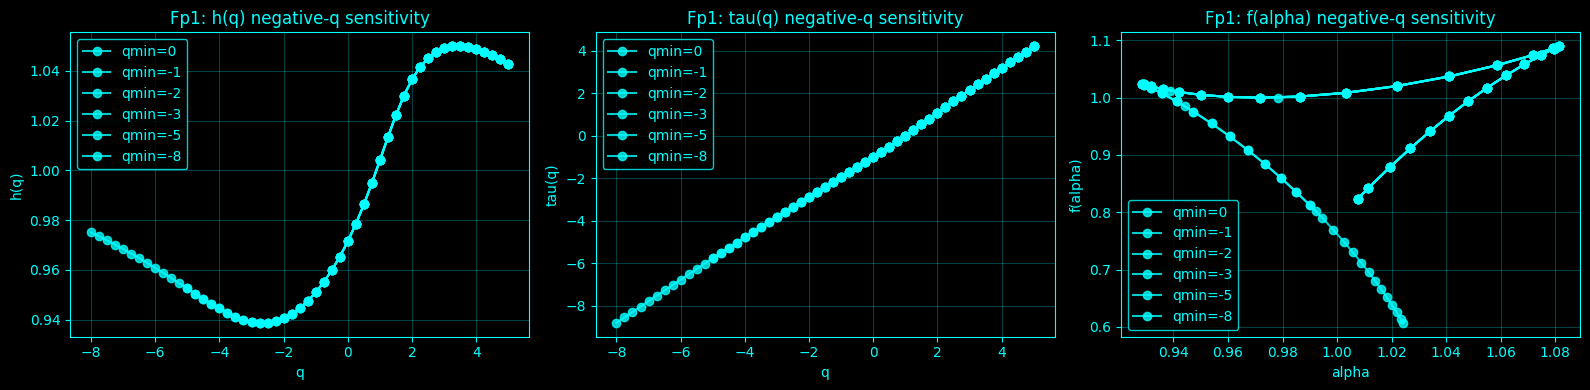

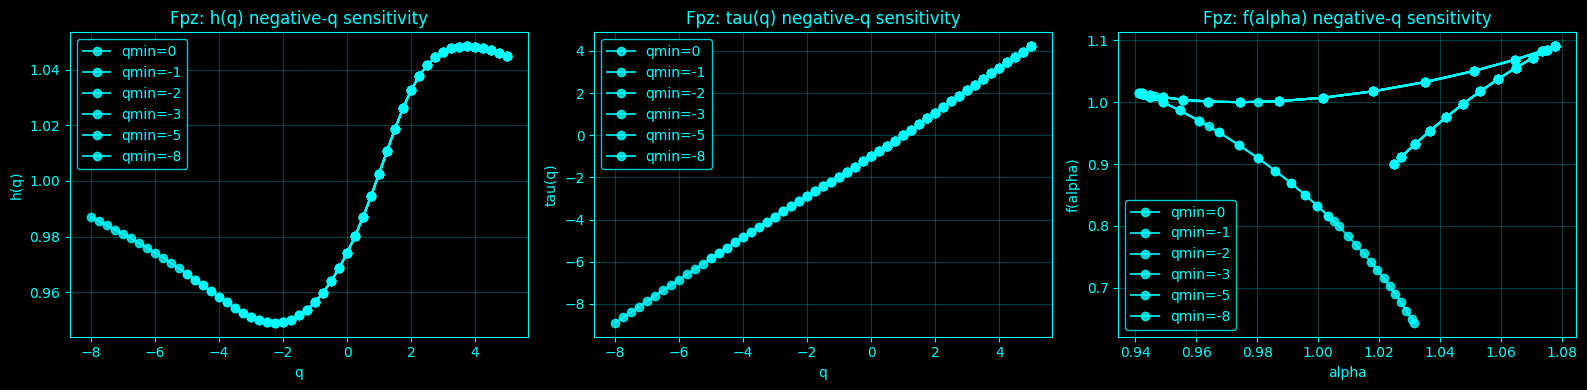

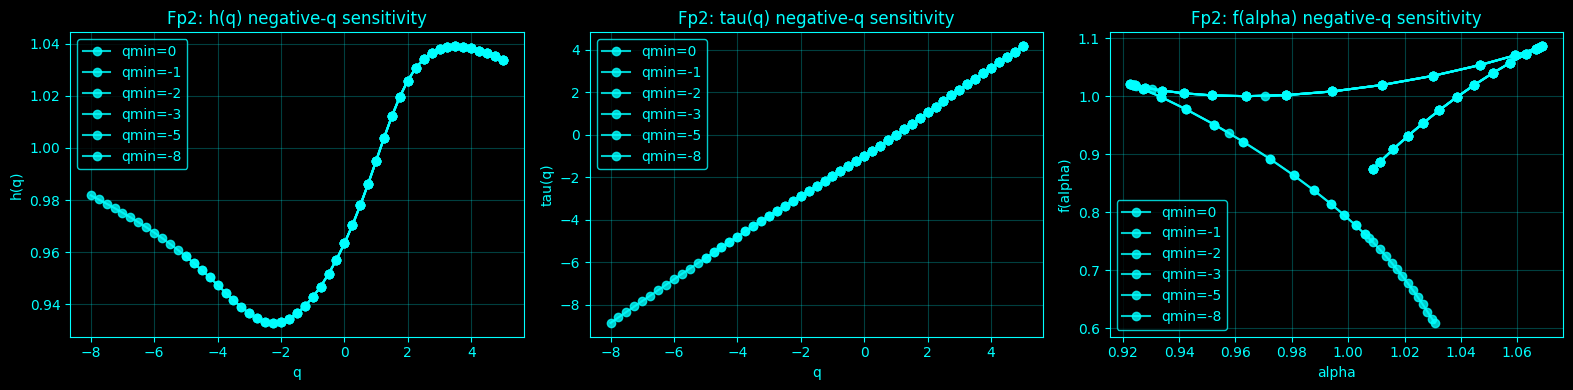

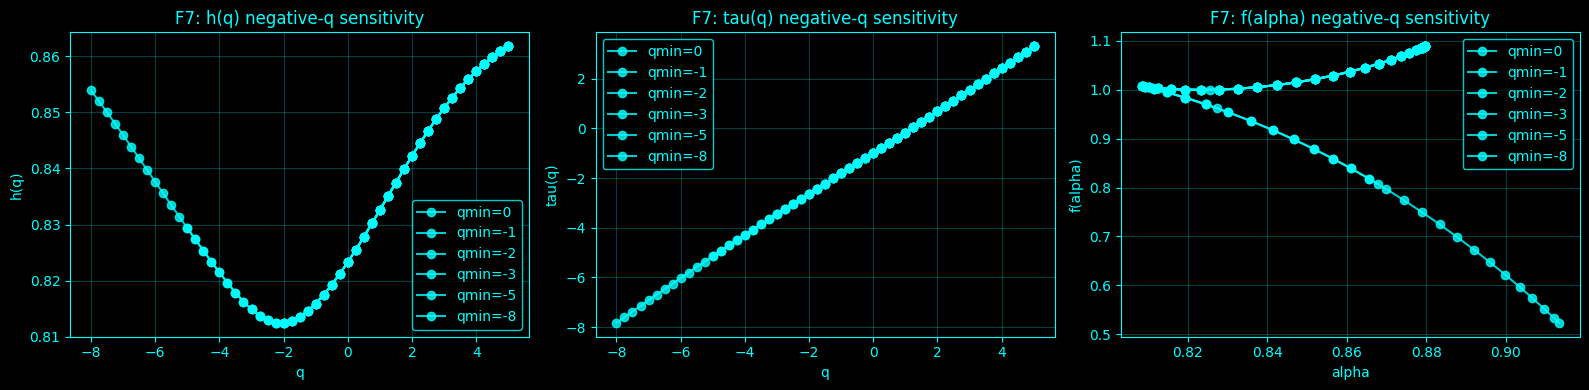

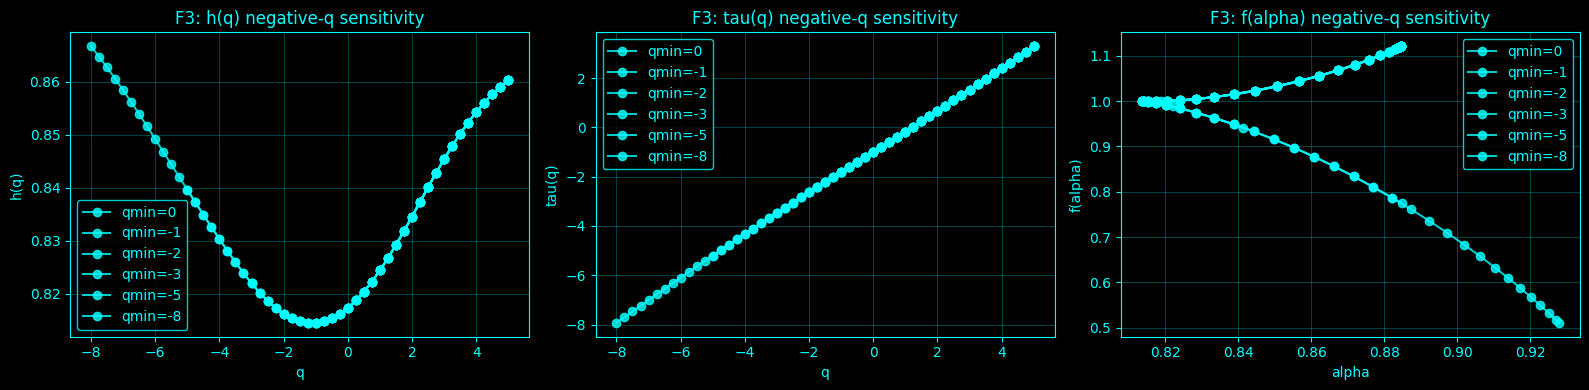

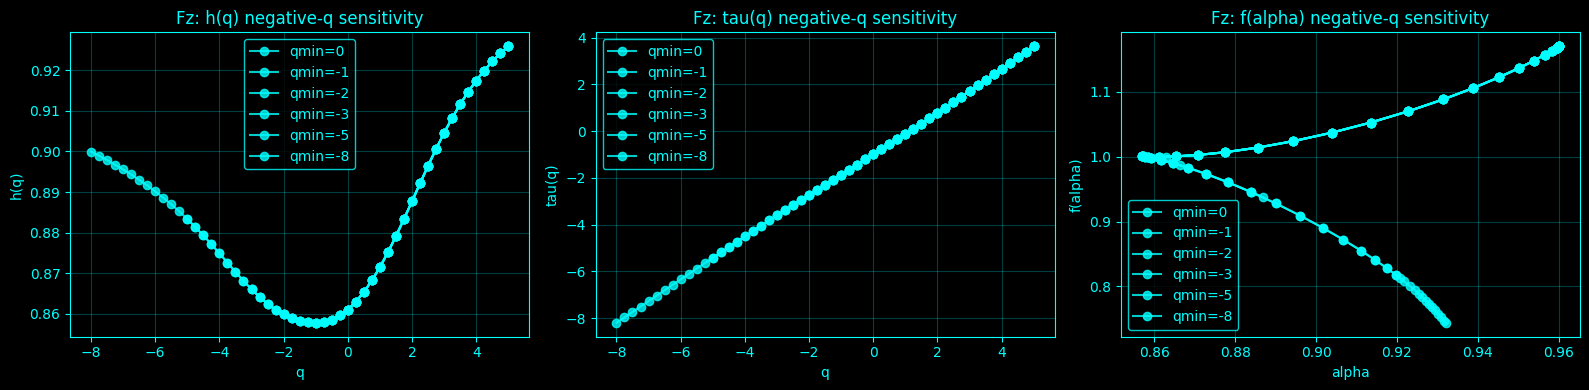

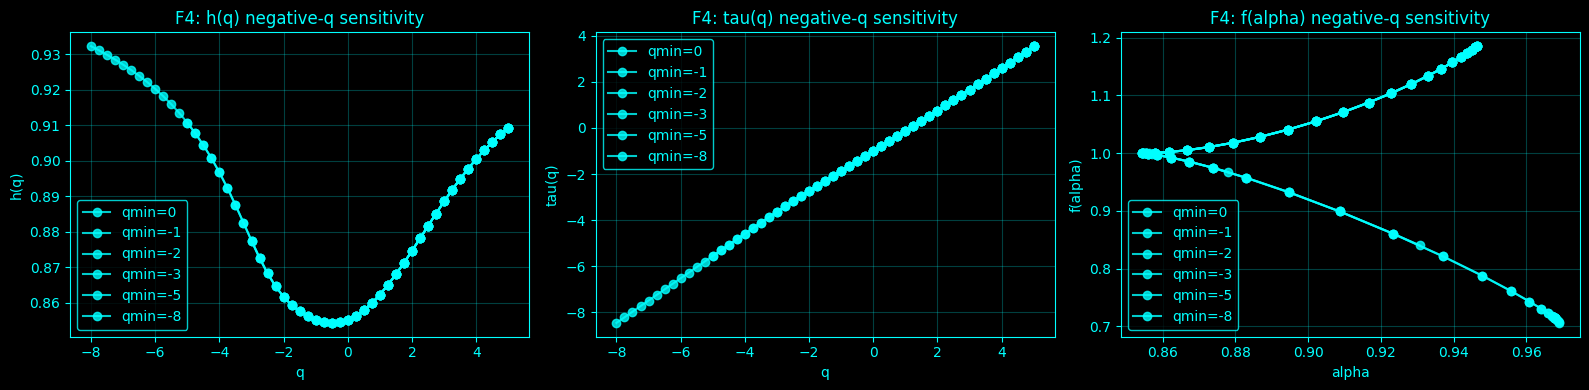

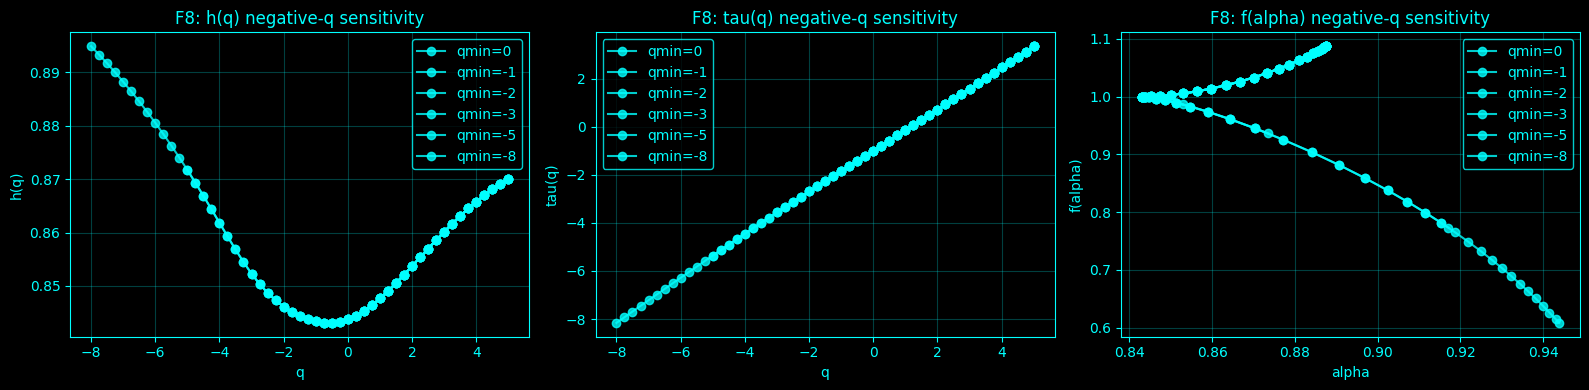

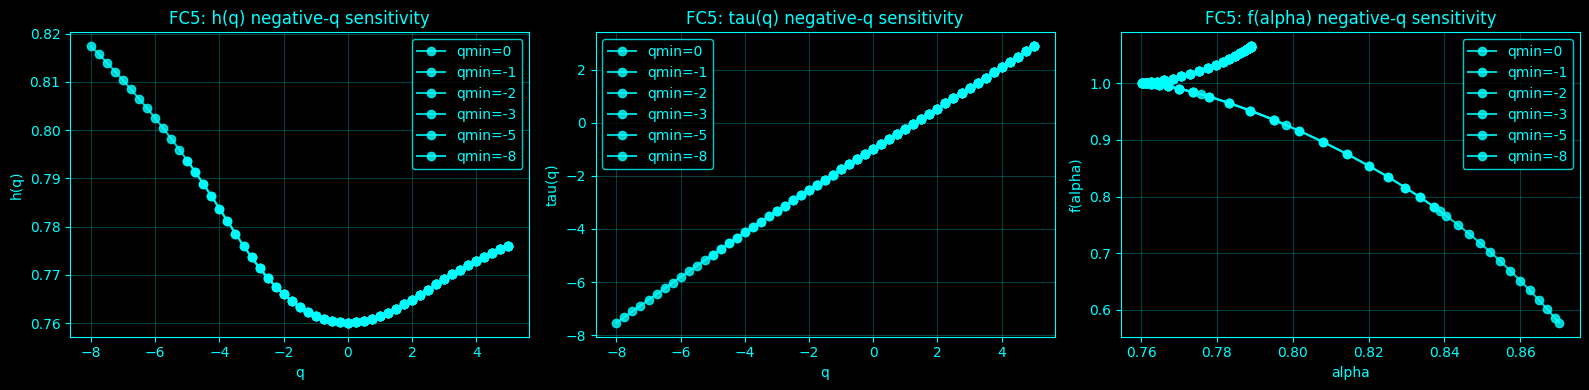

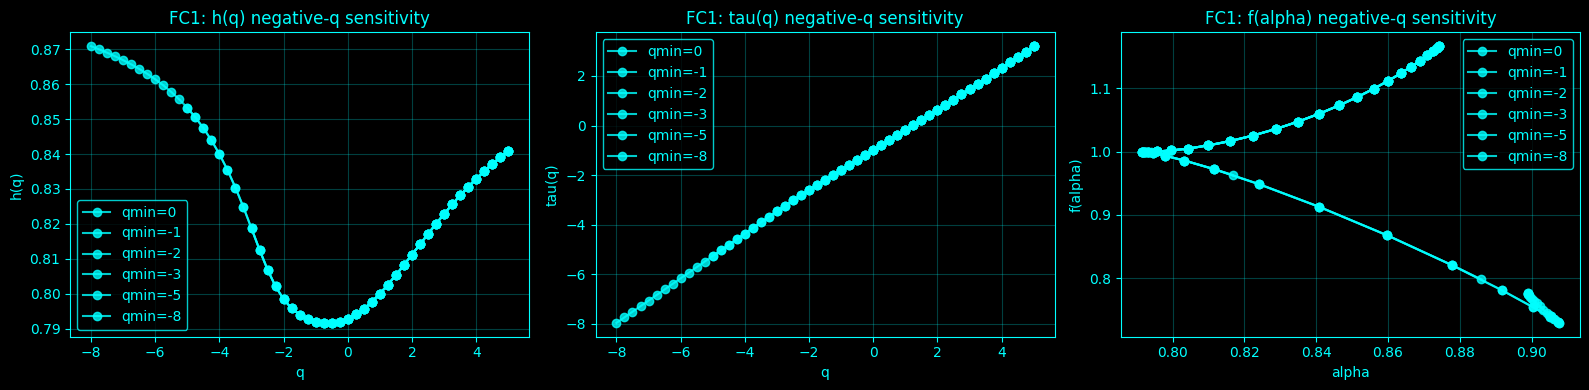

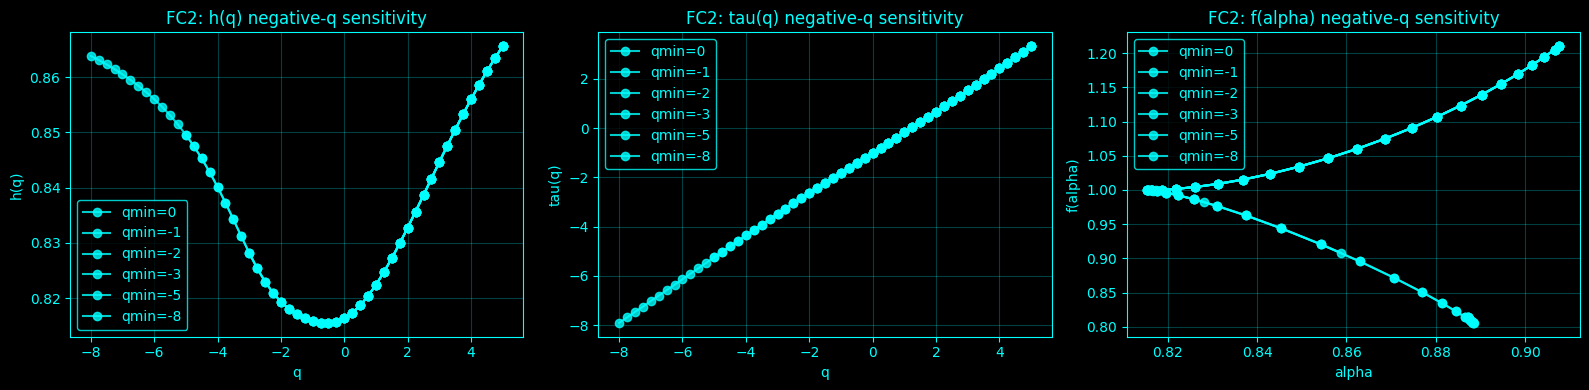

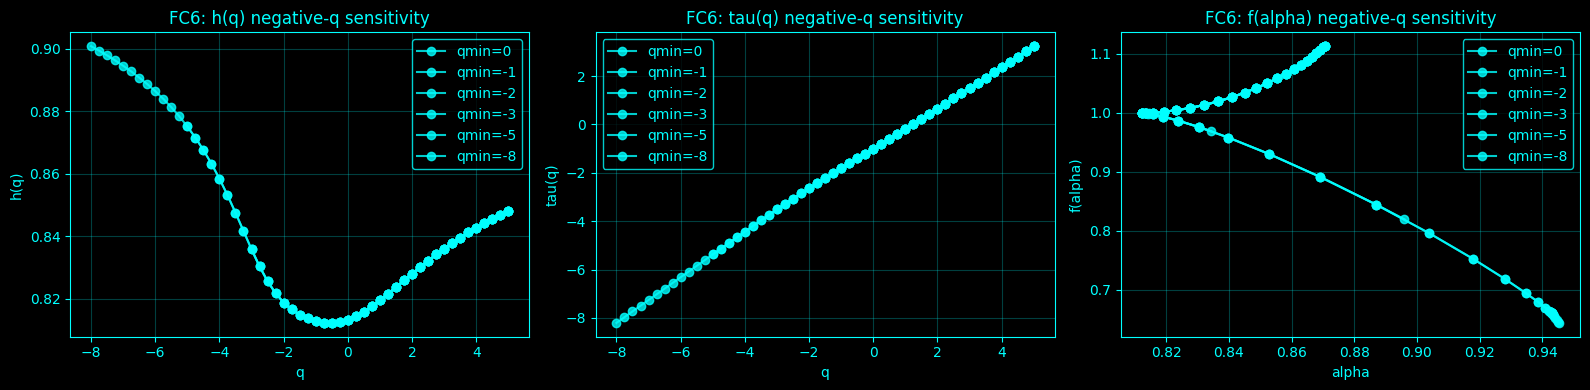

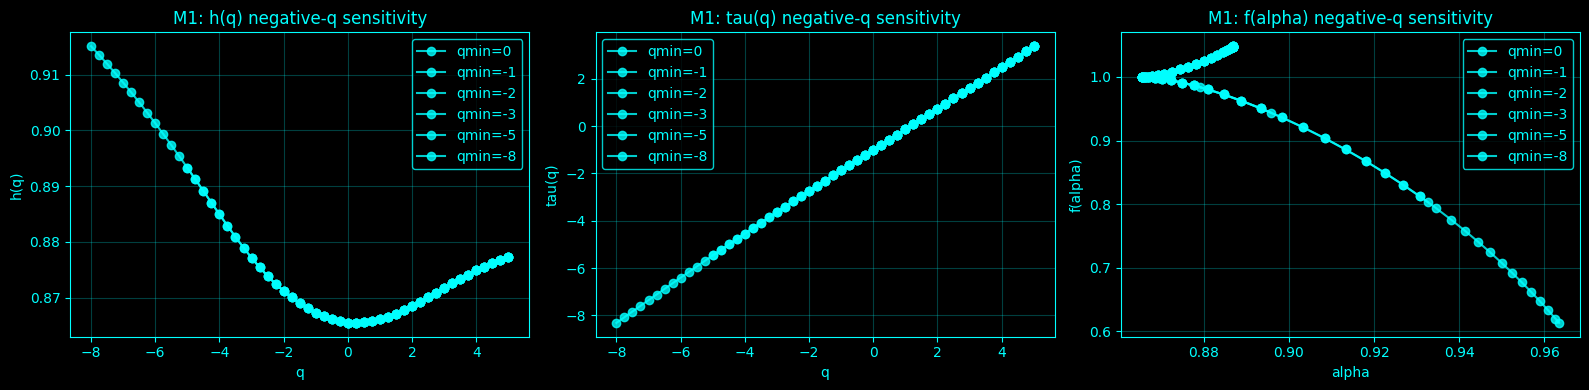

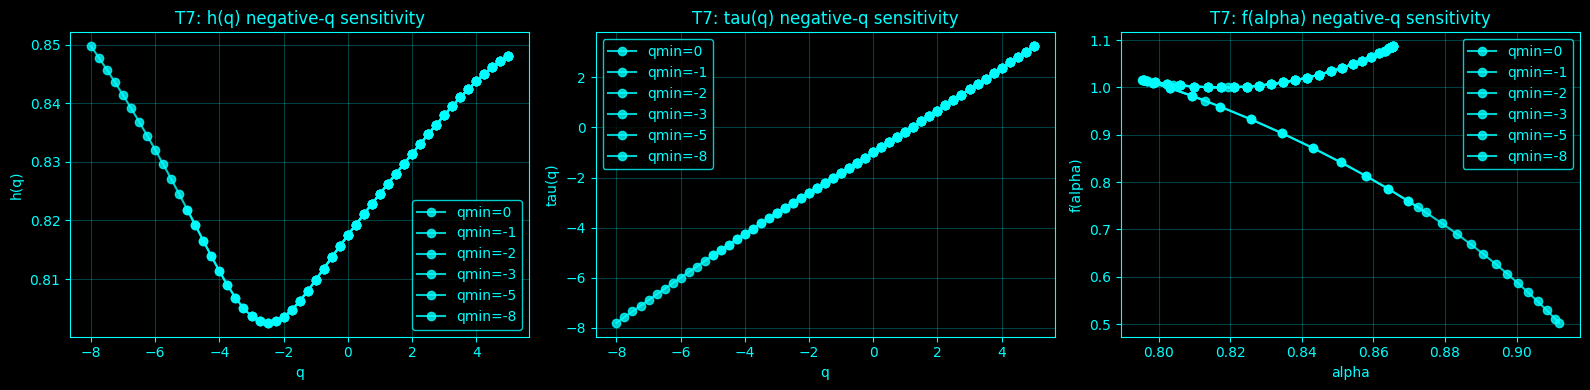

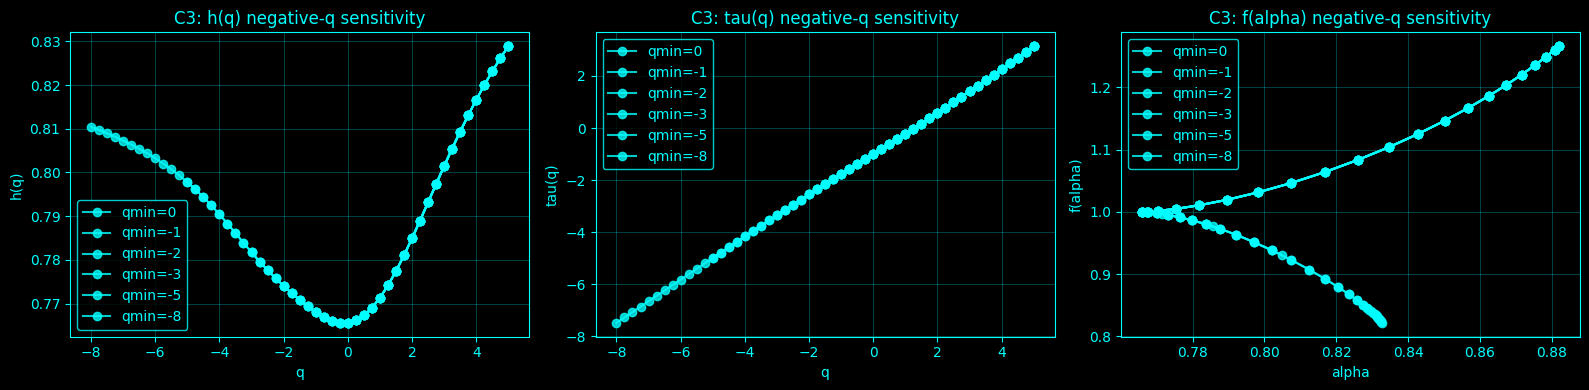

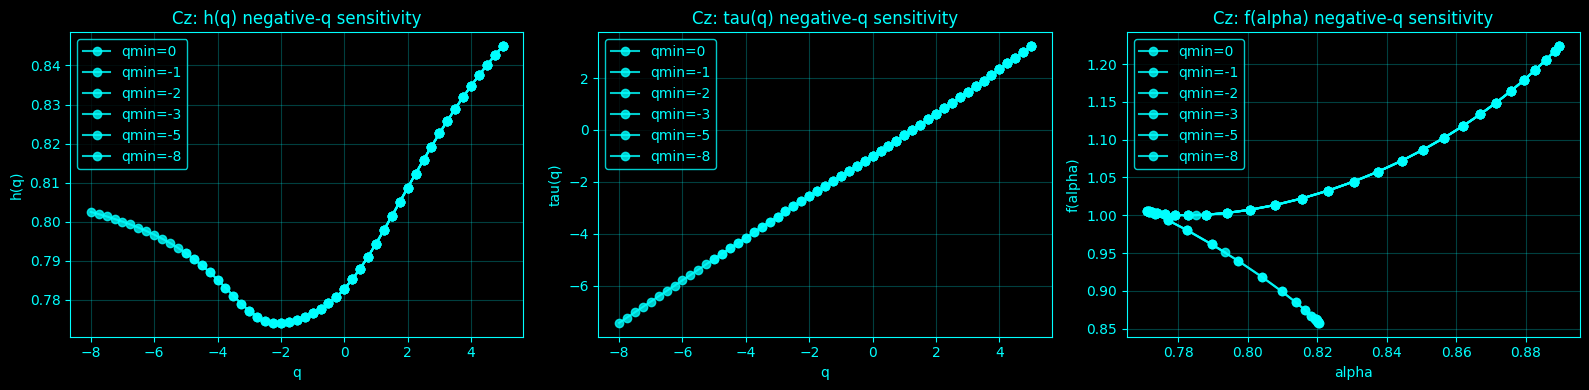

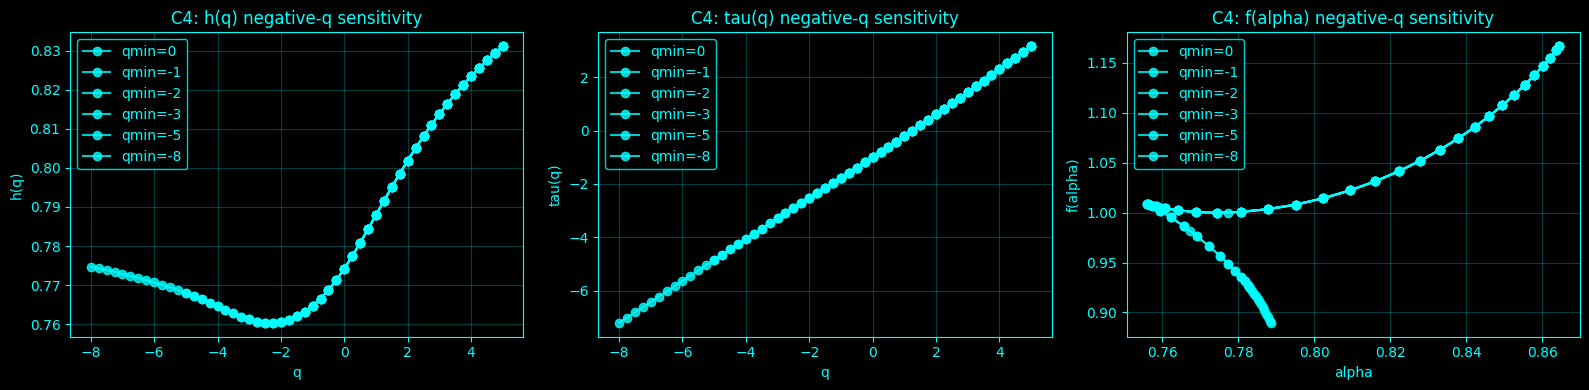

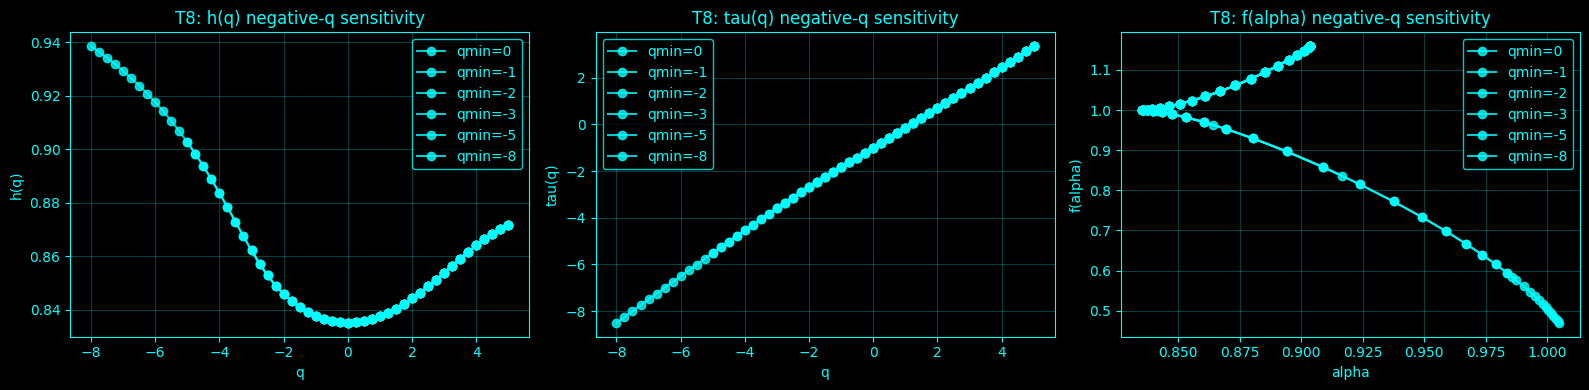

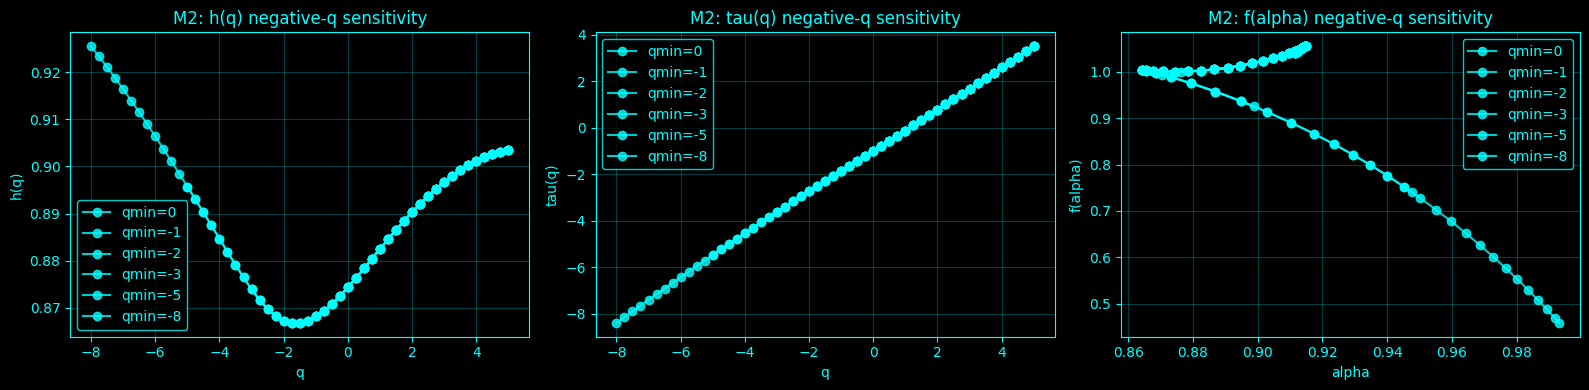

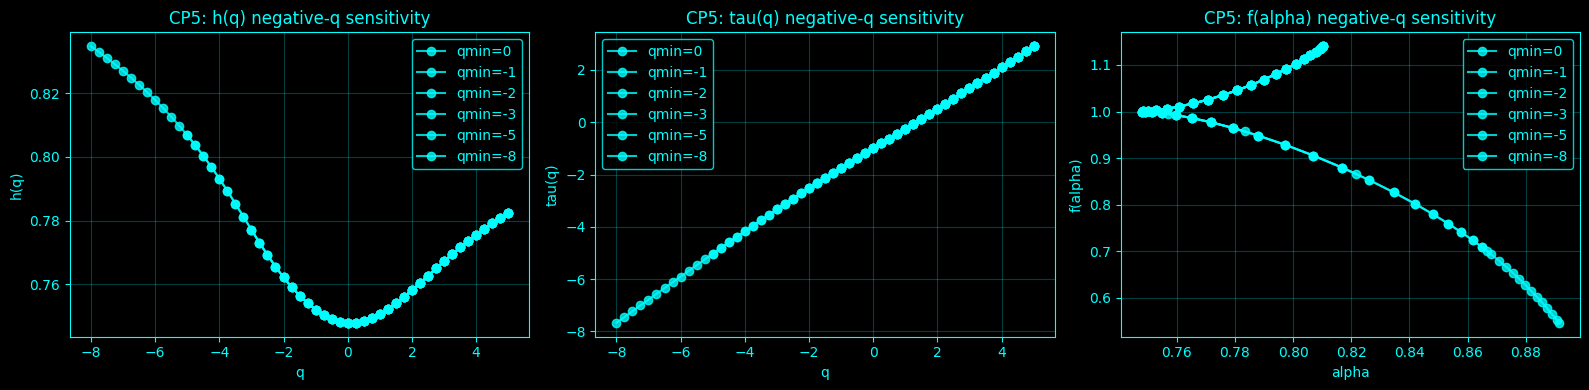

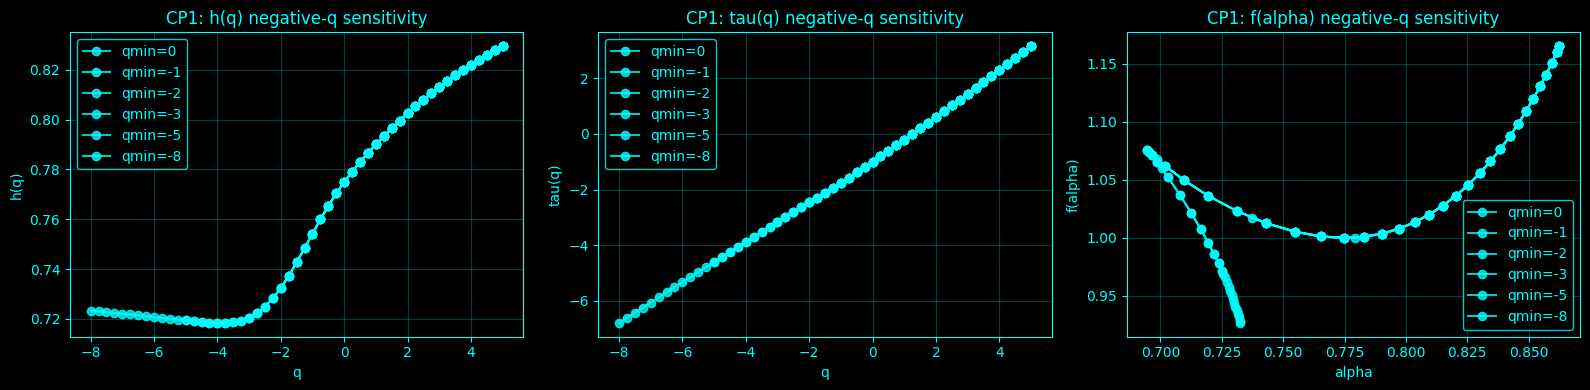

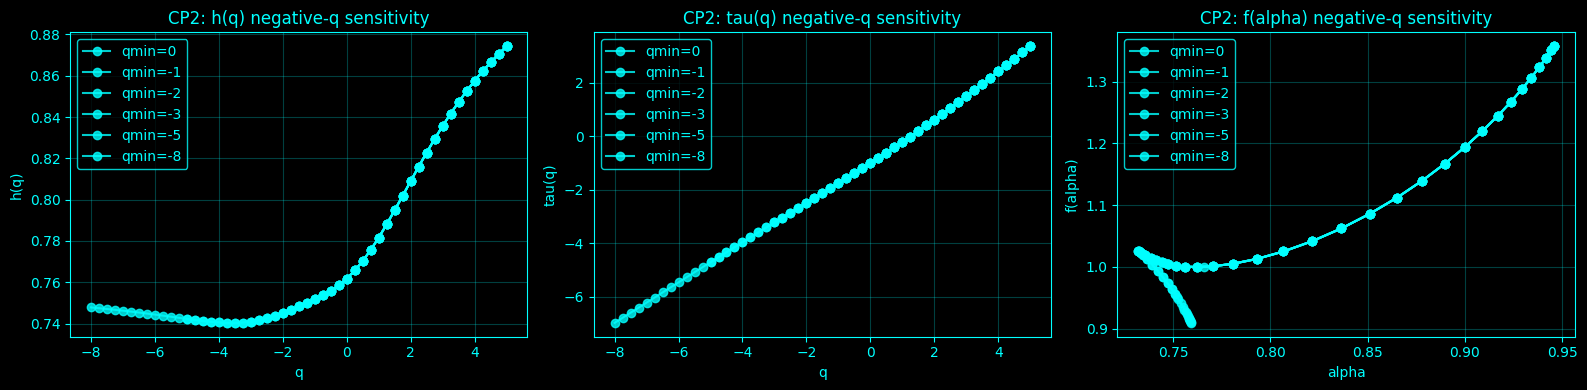

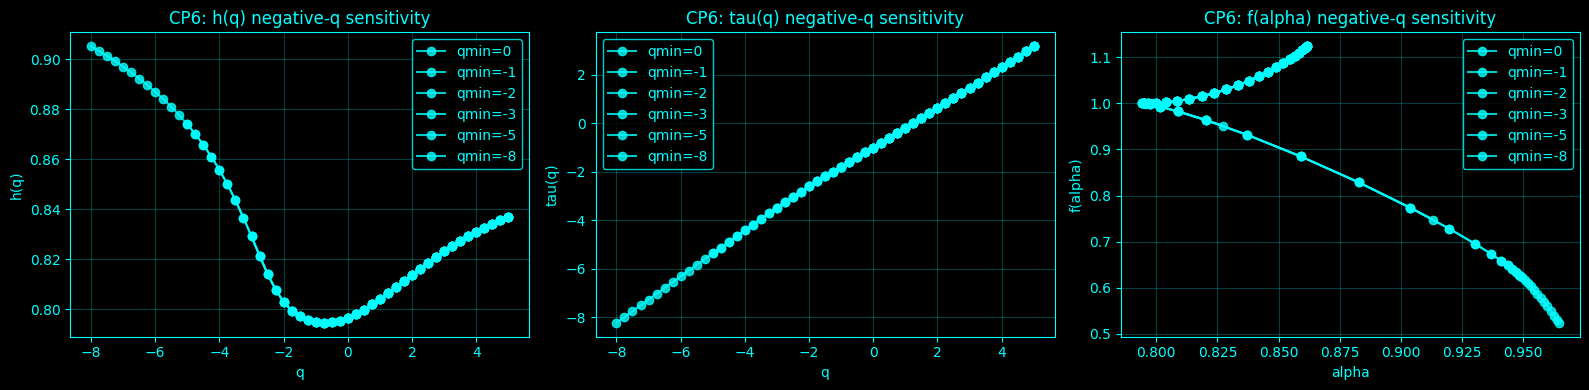

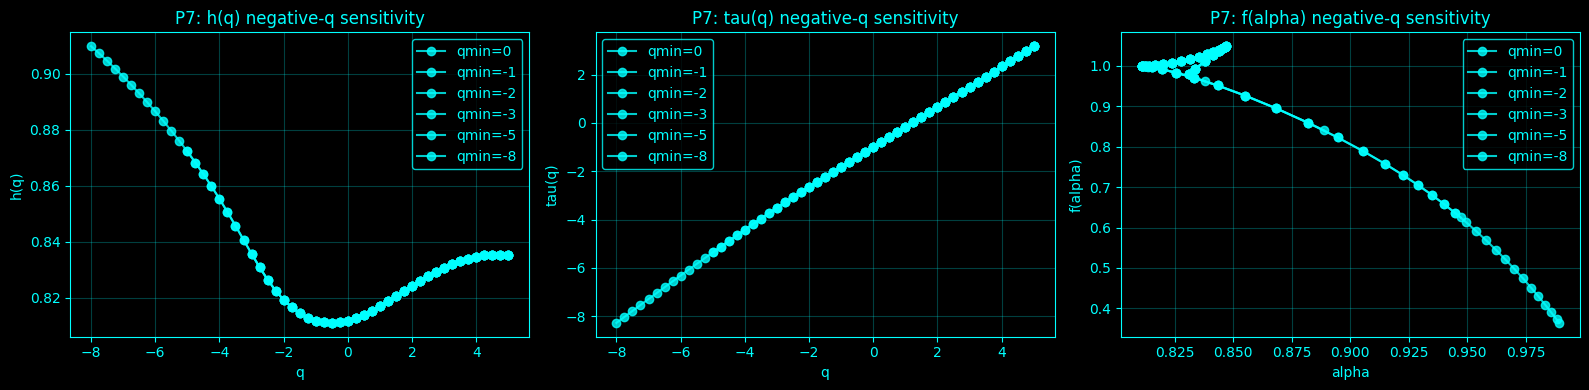

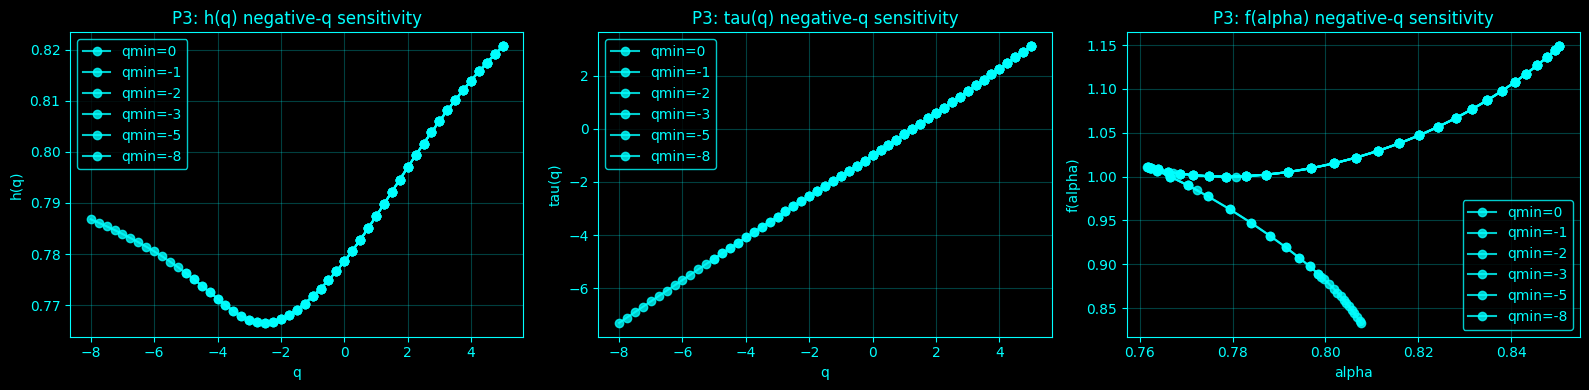

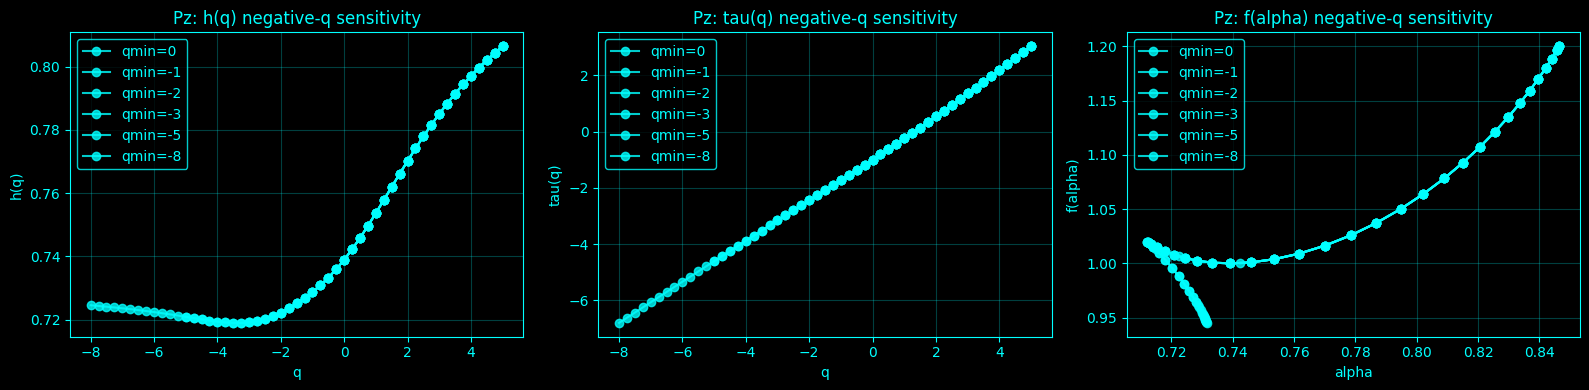

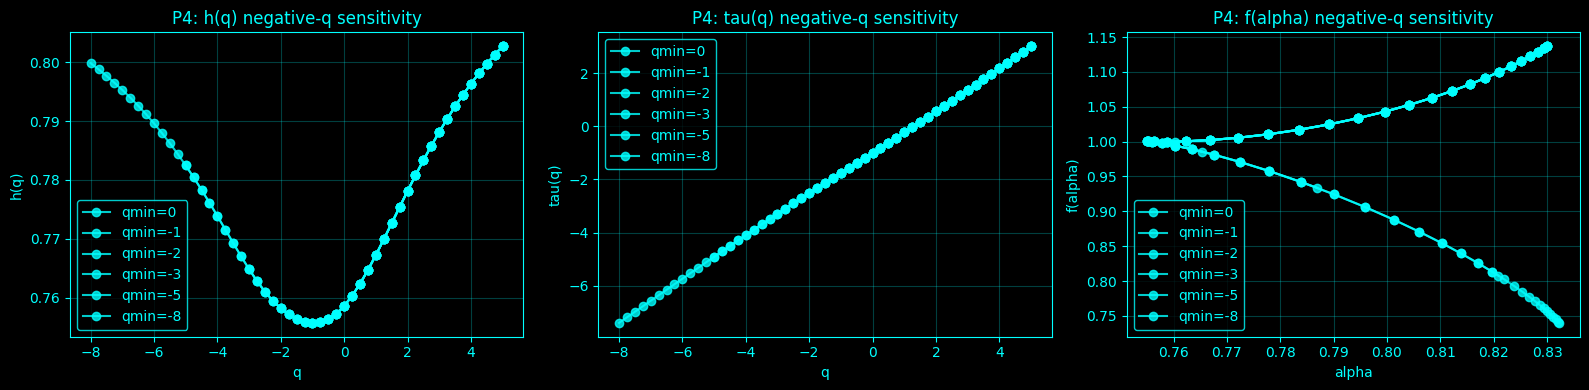

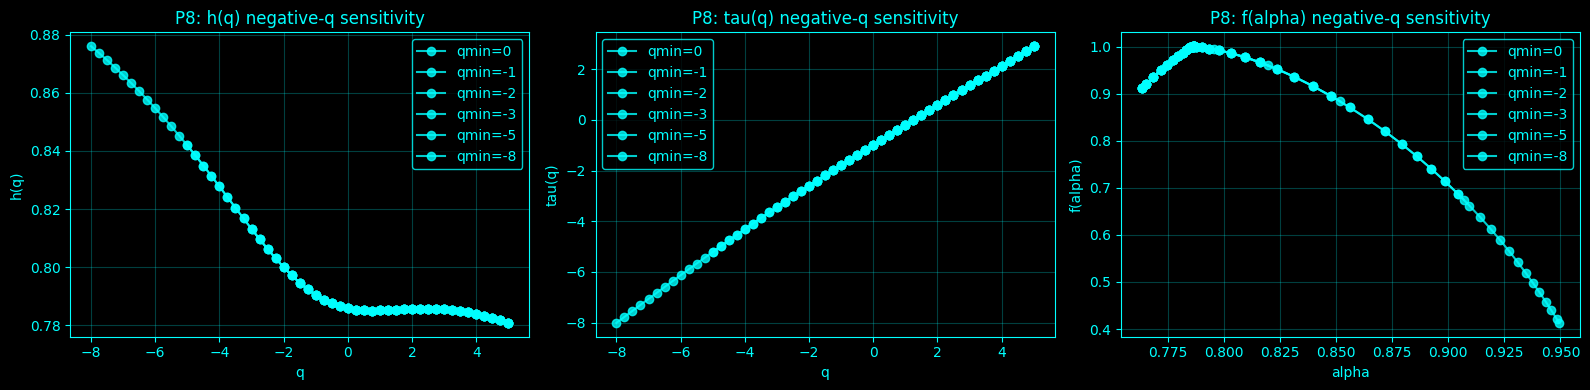

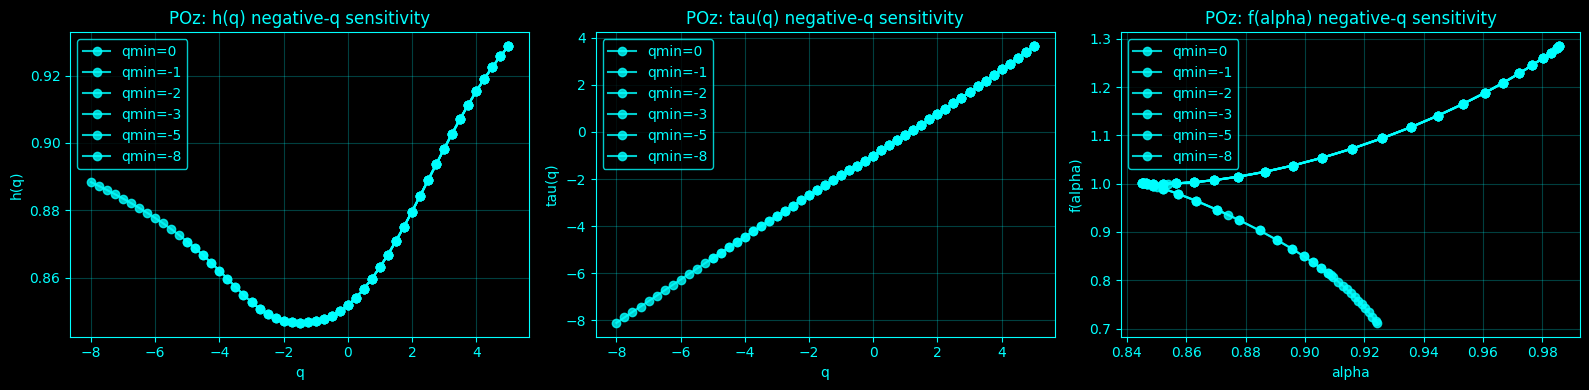

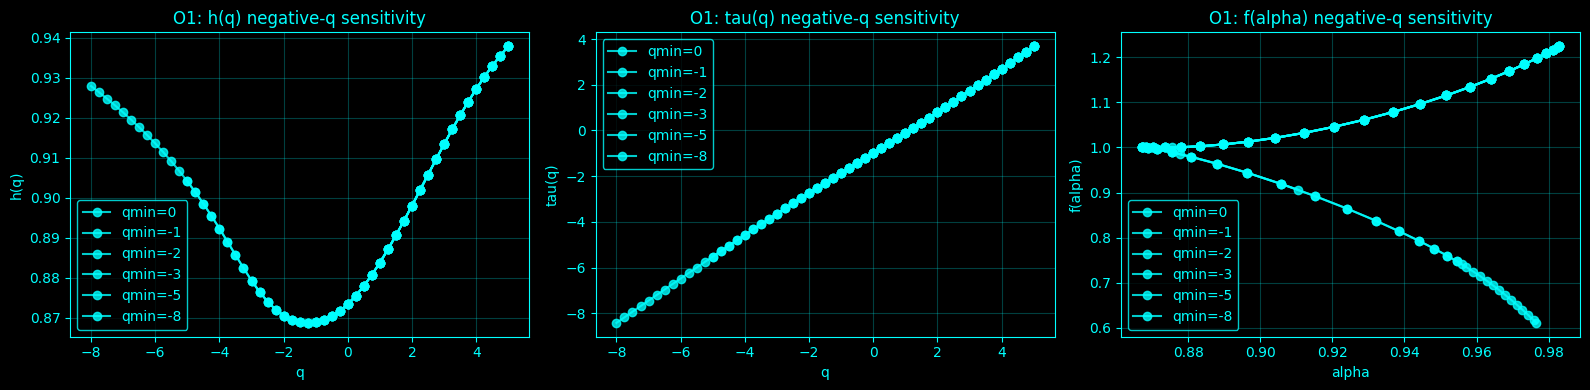

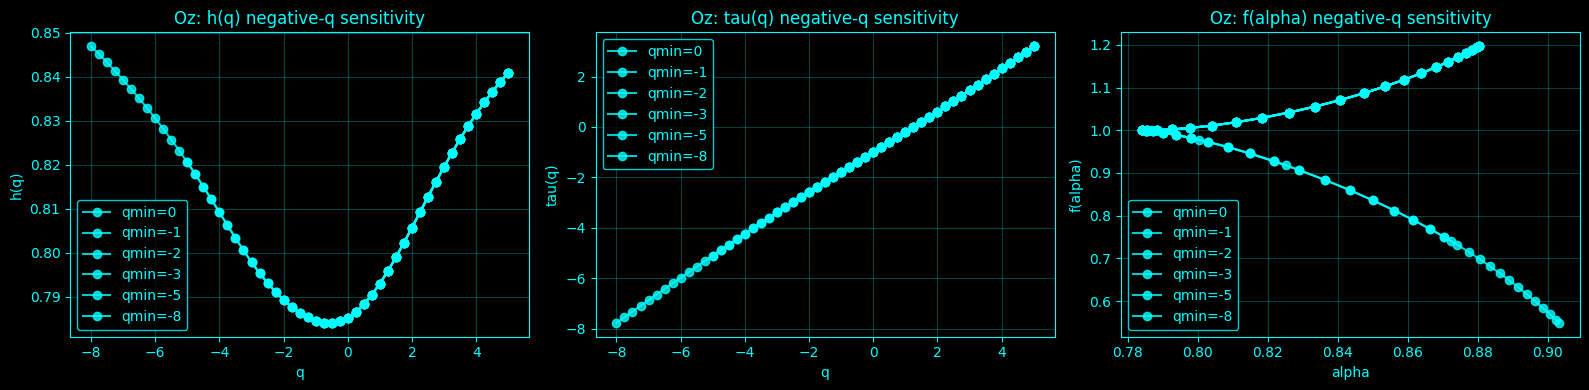

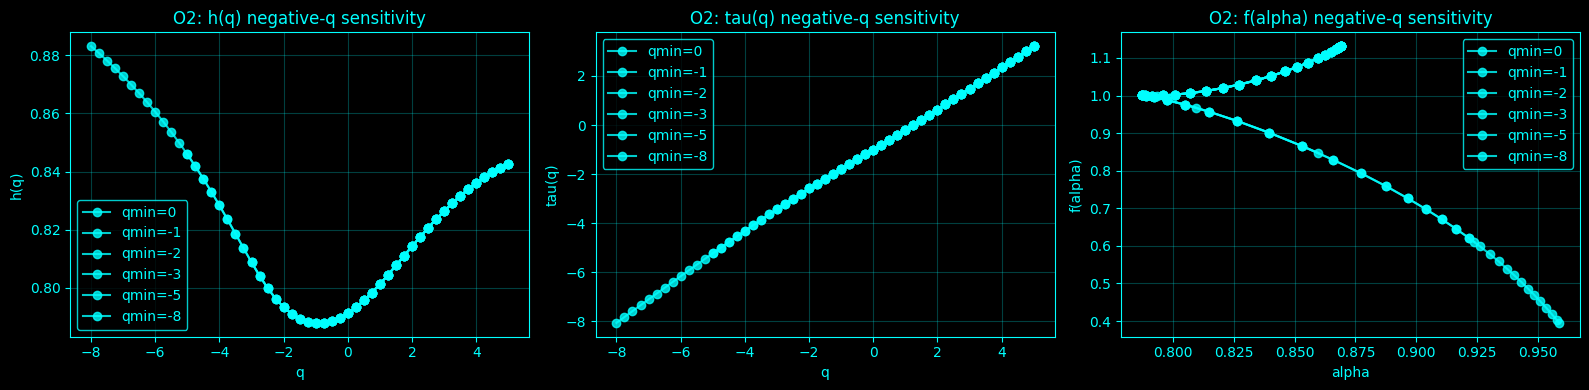


Negative-q stability summary:
    channel  q_min  q_max  n_q  alpha_min  alpha_max  alpha_width  \
0       Fp1      0      5   21   0.978475   1.081400     0.102925   
1       Fp1     -1      5   25   0.938716   1.081400     0.142684   
2       Fp1     -2      5   29   0.928410   1.081400     0.152990   
3       Fp1     -3      5   33   0.928410   1.081400     0.152990   
4       Fp1     -5      5   41   0.928410   1.081400     0.152990   
..      ...    ...    ...  ...        ...        ...          ...   
187      O2     -1      5   25   0.787248   0.868906     0.081658   
188      O2     -2      5   29   0.787248   0.868906     0.081658   
189      O2     -3      5   33   0.787248   0.868906     0.081658   
190      O2     -5      5   41   0.787248   0.923863     0.136615   
191      O2     -8      5   53   0.787248   0.958658     0.171409   

     alpha_at_peak    f_peak  asymmetry  peak_locked_max    h_qmin    h_qmax  \
0         1.081400  1.089866  -0.102925                1  0.

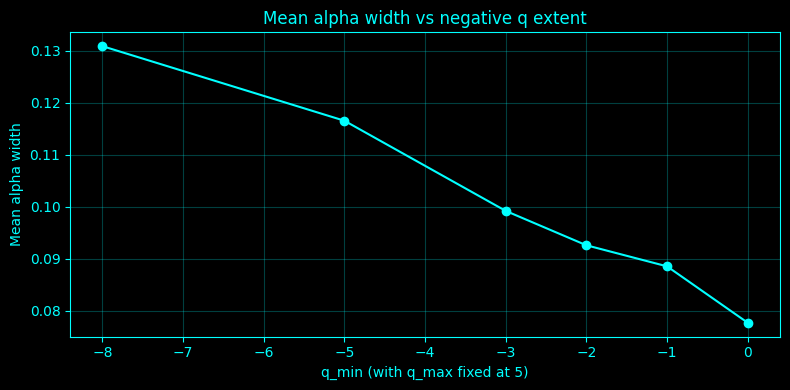

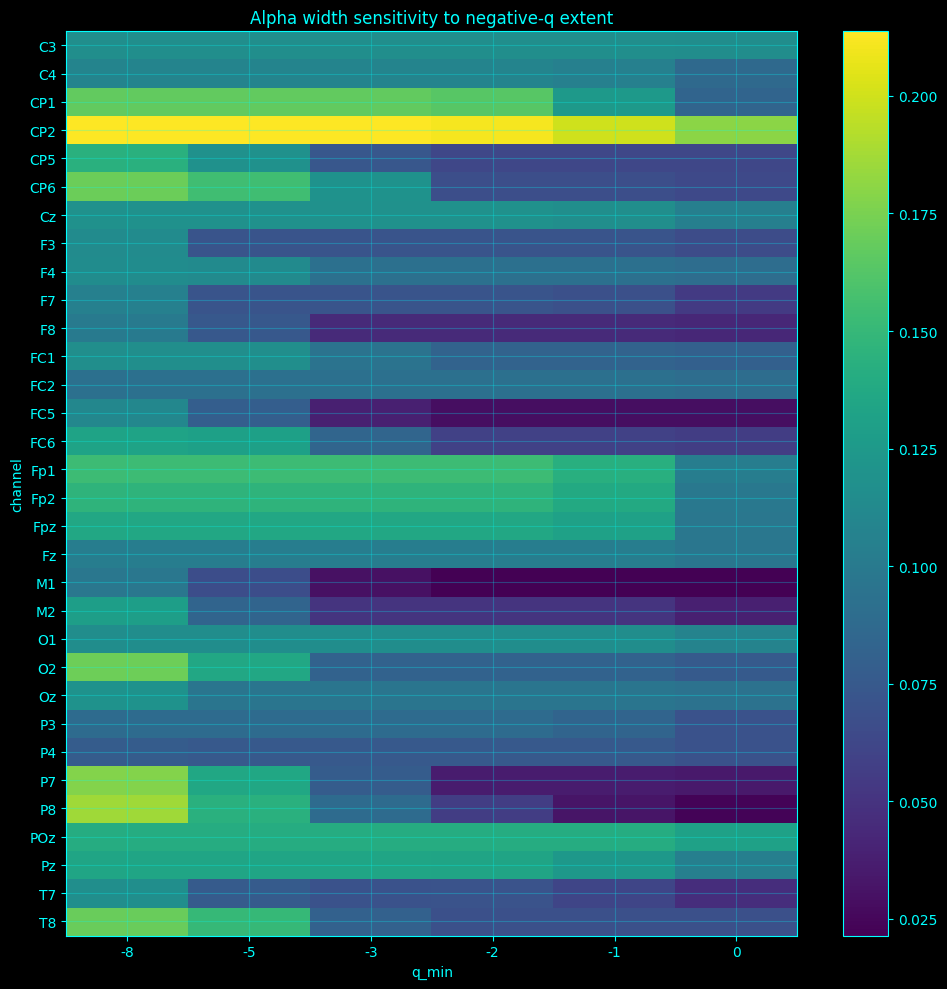


Saved outputs to: /home/a/projects/Complete-Neural-Signal-Analysis/mfdfa_negative_q_stability
Saved summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/mfdfa_negative_q_stability/negative_q_stability_summary.csv


In [13]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")
out_dir = os.path.join(base_dir, "mfdfa_negative_q_stability")
os.makedirs(out_dir, exist_ok=True)

# Same segment as before
sampling_rate = 1000
start_time, end_time = 814.571, 921.515
start_idx = int(start_time * sampling_rate)
end_idx   = int(end_time * sampling_rate)

eeg_channels = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

channels_to_run = eeg_channels.copy()

# Negative-q study:
# hold q_max fixed, progressively extend q_min leftward
q_max_fixed = 5
q_min_list = [0, -1, -2, -3, -5, -8]
q_step = 0.25

poly_order = 1
lag = np.logspace(0.7, 4, 30).astype(int)
lag = np.unique(lag)

# Plot style
ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.grid(True, alpha=0.25, color=ACCENT)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
    ax.xaxis.label.set_color(ACCENT)
    ax.yaxis.label.set_color(ACCENT)
    ax.title.set_color(ACCENT)

def mfdfa_manual(x, scales, q_vals, order=1):
    x = np.asarray(x, dtype=float)
    N = len(x)
    profile = np.cumsum(x - np.mean(x))
    Fq = np.full((len(scales), len(q_vals)), np.nan, dtype=float)

    for si, s in enumerate(scales):
        s = int(s)
        Ns = N // s
        if Ns < 2:
            continue

        F2_segments = []

        # forward segments
        for v in range(Ns):
            start = v * s
            stop = start + s
            seg = profile[start:stop]
            t = np.arange(s)
            coeffs = np.polyfit(t, seg, order)
            trend = np.polyval(coeffs, t)
            F2_segments.append(np.mean((seg - trend) ** 2))

        # backward segments
        for v in range(Ns):
            start = N - (v + 1) * s
            stop = start + s
            seg = profile[start:stop]
            t = np.arange(s)
            coeffs = np.polyfit(t, seg, order)
            trend = np.polyval(coeffs, t)
            F2_segments.append(np.mean((seg - trend) ** 2))

        F2_segments = np.asarray(F2_segments, dtype=float)
        F2_segments = np.maximum(F2_segments, 1e-12)

        for qi, q in enumerate(q_vals):
            if np.isclose(q, 0.0):
                Fq[si, qi] = np.exp(0.5 * np.mean(np.log(F2_segments)))
            else:
                Fq[si, qi] = (np.mean(F2_segments ** (q / 2.0))) ** (1.0 / q)

    return scales, Fq

def estimate_hq(scales, Fq):
    log_s = np.log(scales)
    hq = np.full(Fq.shape[1], np.nan, dtype=float)

    for qi in range(Fq.shape[1]):
        y = Fq[:, qi]
        mask = np.isfinite(y) & (y > 0)
        if np.sum(mask) >= 5:
            coef = np.polyfit(log_s[mask], np.log(y[mask]), 1)
            hq[qi] = coef[0]

    return hq

def compute_multifractal_spectrum(q_vals, hq):
    q_vals = np.asarray(q_vals, dtype=float)
    hq = np.asarray(hq, dtype=float)

    valid = np.isfinite(q_vals) & np.isfinite(hq)
    if np.sum(valid) < 5:
        return {
            "tau": np.full_like(q_vals, np.nan, dtype=float),
            "alpha": np.full_like(q_vals, np.nan, dtype=float),
            "f_alpha": np.full_like(q_vals, np.nan, dtype=float),
        }

    qv = q_vals[valid]
    hv = hq[valid]

    tau_v = qv * hv - 1.0
    alpha_v = np.gradient(tau_v, qv)
    f_alpha_v = qv * alpha_v - tau_v

    tau = np.full_like(q_vals, np.nan, dtype=float)
    alpha = np.full_like(q_vals, np.nan, dtype=float)
    f_alpha = np.full_like(q_vals, np.nan, dtype=float)

    tau[valid] = tau_v
    alpha[valid] = alpha_v
    f_alpha[valid] = f_alpha_v

    return {
        "tau": tau,
        "alpha": alpha,
        "f_alpha": f_alpha,
    }

def summarize_spectrum(alpha, f_alpha):
    alpha = np.asarray(alpha, dtype=float)
    f_alpha = np.asarray(f_alpha, dtype=float)

    valid = np.isfinite(alpha) & np.isfinite(f_alpha)
    if np.sum(valid) < 5:
        return {
            "alpha_min": np.nan,
            "alpha_max": np.nan,
            "alpha_width": np.nan,
            "alpha_at_peak": np.nan,
            "f_peak": np.nan,
            "asymmetry": np.nan,
            "peak_locked_max": np.nan,
        }

    a = alpha[valid]
    f = f_alpha[valid]

    alpha_min = np.min(a)
    alpha_max = np.max(a)
    alpha_width = alpha_max - alpha_min

    peak_idx = np.argmax(f)
    alpha_at_peak = a[peak_idx]
    f_peak = f[peak_idx]

    left_width = alpha_at_peak - alpha_min
    right_width = alpha_max - alpha_at_peak
    asymmetry = right_width - left_width

    peak_locked_max = np.isclose(alpha_at_peak, alpha_max)

    return {
        "alpha_min": alpha_min,
        "alpha_max": alpha_max,
        "alpha_width": alpha_width,
        "alpha_at_peak": alpha_at_peak,
        "f_peak": f_peak,
        "asymmetry": asymmetry,
        "peak_locked_max": peak_locked_max,
    }

def run_mfdfa_setting(x, lag, q_vals, poly_order):
    scales_out, Fq = mfdfa_manual(x, lag, q_vals, order=poly_order)
    hq = estimate_hq(scales_out, Fq)
    spec = compute_multifractal_spectrum(q_vals, hq)
    summary = summarize_spectrum(spec["alpha"], spec["f_alpha"])
    return {
        "scales": scales_out,
        "Fq": Fq,
        "hq": hq,
        "tau": spec["tau"],
        "alpha": spec["alpha"],
        "f_alpha": spec["f_alpha"],
        **summary
    }

# -------------------------------------------------------
# LOAD EEG SEGMENT
# -------------------------------------------------------
EEG_data = np.load(eeg_path, allow_pickle=True)

if EEG_data.ndim != 2:
    raise ValueError(f"Expected 2D EEG array, got shape {EEG_data.shape}")

if EEG_data.shape[1] == len(eeg_channels):
    EEG_segment = EEG_data[start_idx:end_idx, :]
elif EEG_data.shape[0] == len(eeg_channels):
    EEG_segment = EEG_data[:, start_idx:end_idx].T
else:
    raise ValueError(f"Unexpected EEG shape: {EEG_data.shape}")

num_timepoints, num_channels = EEG_segment.shape
print(f"Loaded EEG segment: {num_timepoints} samples x {num_channels} channels")
print(f"Segment: [{start_time}, {end_time}] sec")

lag = lag[(lag > poly_order + 2) & (lag < num_timepoints // 4)]
print("Using scales:", lag)

channel_to_idx = {ch: i for i, ch in enumerate(eeg_channels)}

# -------------------------------------------------------
# RUN NEGATIVE-Q STABILITY STUDY
# -------------------------------------------------------
summary_rows = []

for channel_name in channels_to_run:
    if channel_name not in channel_to_idx:
        continue

    ch_idx = channel_to_idx[channel_name]
    x = EEG_segment[:, ch_idx].astype(float)

    channel_results = []

    for q_min in q_min_list:
        q_vals = np.arange(q_min, q_max_fixed + q_step / 2, q_step)
        if not np.any(np.isclose(q_vals, 0.0)):
            q_vals = np.sort(np.unique(np.append(q_vals, 0.0)))

        res = run_mfdfa_setting(x, lag, q_vals, poly_order)

        tag = f"qmin_{str(q_min).replace('-', 'm').replace('.', 'p')}_qmax_{str(q_max_fixed).replace('.', 'p')}"
        npz_path = os.path.join(out_dir, f"{channel_name}_{tag}.npz")
        np.savez(
            npz_path,
            channel=channel_name,
            start_time=start_time,
            end_time=end_time,
            sampling_rate=sampling_rate,
            q_vals=q_vals,
            scales=res["scales"],
            Fq=res["Fq"],
            hq=res["hq"],
            tau=res["tau"],
            alpha=res["alpha"],
            f_alpha=res["f_alpha"],
            alpha_min=res["alpha_min"],
            alpha_max=res["alpha_max"],
            alpha_width=res["alpha_width"],
            alpha_at_peak=res["alpha_at_peak"],
            f_peak=res["f_peak"],
            asymmetry=res["asymmetry"],
            peak_locked_max=res["peak_locked_max"],
        )

        channel_results.append((q_min, q_vals, res))

        summary_rows.append({
            "channel": channel_name,
            "q_min": q_min,
            "q_max": q_max_fixed,
            "n_q": len(q_vals),
            "alpha_min": res["alpha_min"],
            "alpha_max": res["alpha_max"],
            "alpha_width": res["alpha_width"],
            "alpha_at_peak": res["alpha_at_peak"],
            "f_peak": res["f_peak"],
            "asymmetry": res["asymmetry"],
            "peak_locked_max": int(bool(res["peak_locked_max"])) if np.isfinite(res["peak_locked_max"]) else np.nan,
            "h_qmin": res["hq"][0] if len(res["hq"]) > 0 else np.nan,
            "h_qmax": res["hq"][-1] if len(res["hq"]) > 0 else np.nan,
            "delta_h": (res["hq"][-1] - res["hq"][0]) if len(res["hq"]) > 1 else np.nan,
        })

    # ---------------------------------------------------
    # PER-CHANNEL PLOTS
    # ---------------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(16, 4), facecolor=BG)
    for ax in axes:
        style_ax(ax)

    for q_min, q_vals, res in channel_results:
        label = f"qmin={q_min}"

        axes[0].plot(
            q_vals, res["hq"],
            marker='o',
            color=ACCENT,
            markerfacecolor=ACCENT,
            markeredgecolor=ACCENT,
            alpha=0.8,
            label=label
        )

        axes[1].plot(
            q_vals, res["tau"],
            marker='o',
            color=ACCENT,
            markerfacecolor=ACCENT,
            markeredgecolor=ACCENT,
            alpha=0.8,
            label=label
        )

        mask = np.isfinite(res["alpha"]) & np.isfinite(res["f_alpha"])
        axes[2].plot(
            res["alpha"][mask], res["f_alpha"][mask],
            marker='o',
            color=ACCENT,
            markerfacecolor=ACCENT,
            markeredgecolor=ACCENT,
            alpha=0.8,
            label=label
        )

    axes[0].set_title(f"{channel_name}: h(q) negative-q sensitivity")
    axes[0].set_xlabel("q")
    axes[0].set_ylabel("h(q)")
    axes[0].legend()

    axes[1].set_title(f"{channel_name}: tau(q) negative-q sensitivity")
    axes[1].set_xlabel("q")
    axes[1].set_ylabel("tau(q)")
    axes[1].legend()

    axes[2].set_title(f"{channel_name}: f(alpha) negative-q sensitivity")
    axes[2].set_xlabel("alpha")
    axes[2].set_ylabel("f(alpha)")
    axes[2].legend()

    plt.tight_layout()
    fig_path = os.path.join(out_dir, f"{channel_name}_negative_q_sensitivity.png")
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

# -------------------------------------------------------
# SAVE SUMMARY TABLE
# -------------------------------------------------------
summary_df = pd.DataFrame(summary_rows)
summary_csv = os.path.join(out_dir, "negative_q_stability_summary.csv")
summary_df.to_csv(summary_csv, index=False)

print("\nNegative-q stability summary:")
print(summary_df)

# -------------------------------------------------------
# GLOBAL SUMMARY PLOTS
# -------------------------------------------------------
# 1) mean alpha width vs q_min
mean_width = summary_df.groupby("q_min")["alpha_width"].mean().reset_index()

fig, ax = plt.subplots(figsize=(8, 4), facecolor=BG)
style_ax(ax)
ax.plot(
    mean_width["q_min"], mean_width["alpha_width"],
    marker='o',
    color=ACCENT,
    markerfacecolor=ACCENT,
    markeredgecolor=ACCENT
)
ax.set_title("Mean alpha width vs negative q extent")
ax.set_xlabel("q_min (with q_max fixed at 5)")
ax.set_ylabel("Mean alpha width")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "mean_alpha_width_vs_qmin.png"), dpi=150, bbox_inches="tight")
plt.show()
plt.close()

# 2) heatmap of alpha width by channel and q_min
pivot = summary_df.pivot_table(
    index="channel",
    columns="q_min",
    values="alpha_width",
    aggfunc="mean"
).sort_index(axis=1)

fig, ax = plt.subplots(figsize=(10, 10), facecolor=BG)
style_ax(ax)
im = ax.imshow(pivot.values, aspect="auto")
ax.set_title("Alpha width sensitivity to negative-q extent")
ax.set_xlabel("q_min")
ax.set_ylabel("channel")
ax.set_xticks(np.arange(len(pivot.columns)))
ax.set_xticklabels([str(c) for c in pivot.columns], color=ACCENT)
ax.set_yticks(np.arange(len(pivot.index)))
ax.set_yticklabels(list(pivot.index), color=ACCENT)

cbar = plt.colorbar(im, ax=ax)
cbar.ax.yaxis.set_tick_params(color=ACCENT)
plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)

plt.tight_layout()
plt.savefig(os.path.join(out_dir, "alpha_width_negative_q_heatmap.png"), dpi=150, bbox_inches="tight")
plt.show()
plt.close()

print(f"\nSaved outputs to: {out_dir}")
print(f"Saved summary CSV: {summary_csv}")

Loaded EEG segment: 106944 samples x 32 channels
Segment: [814.571, 921.515] sec
Using scales: [    5     6     8    10    14    18    24    31    40    52    68    89
   116   151   196   255   331   431   560   727   945  1229  1597  2076
  2697  3506  4556  5921  7694 10000]


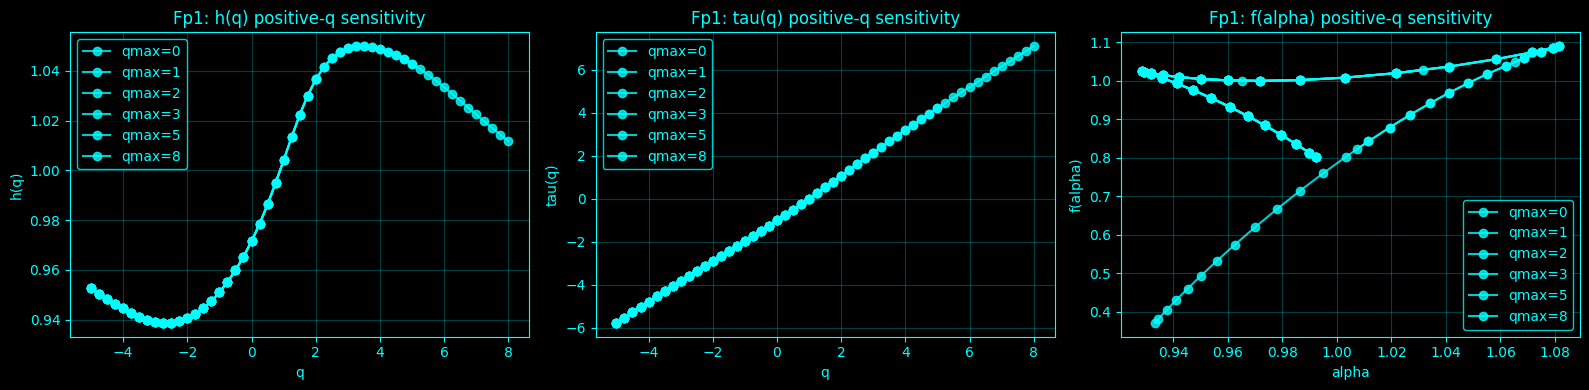

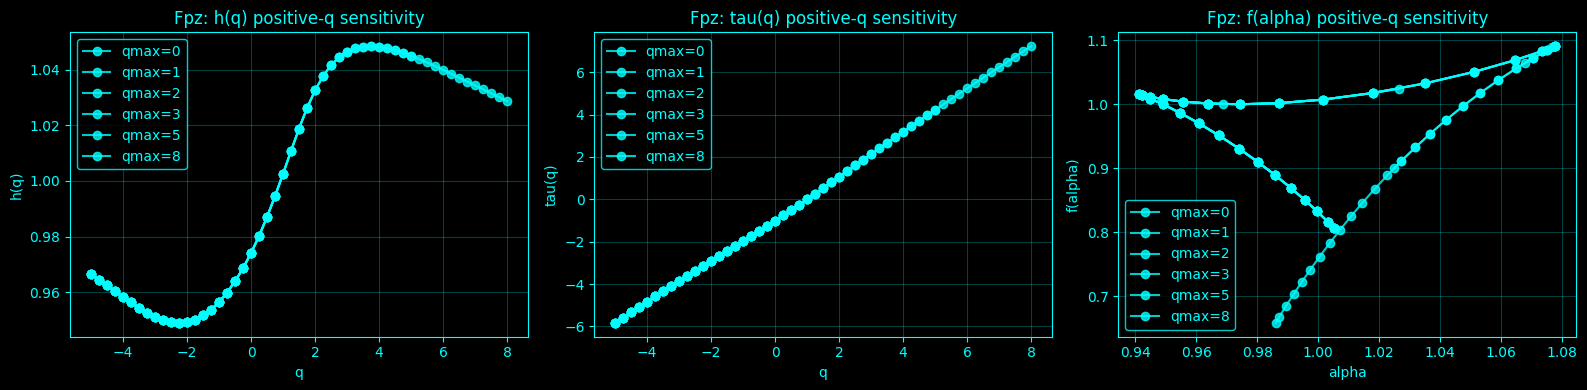

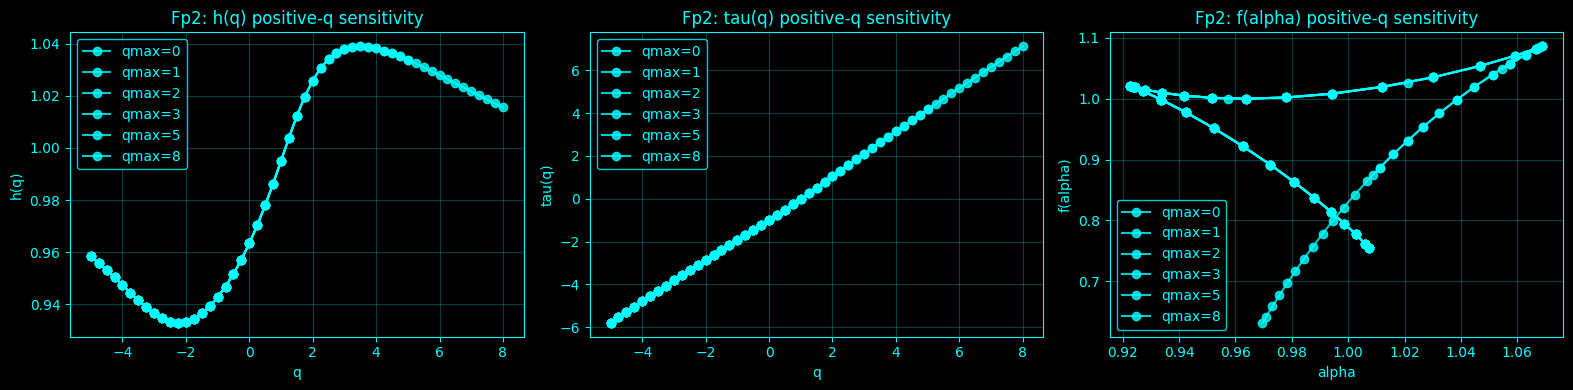

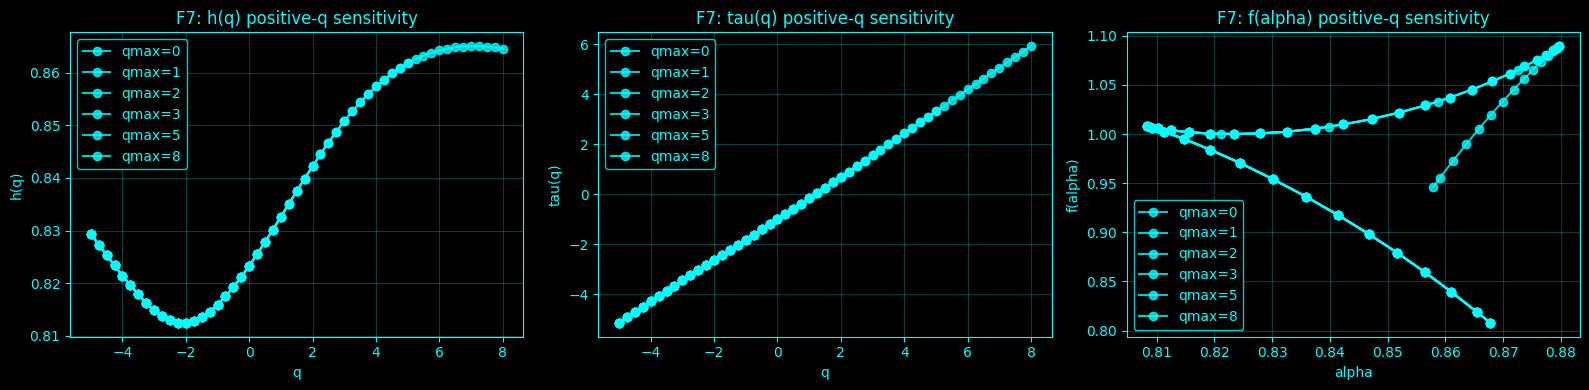

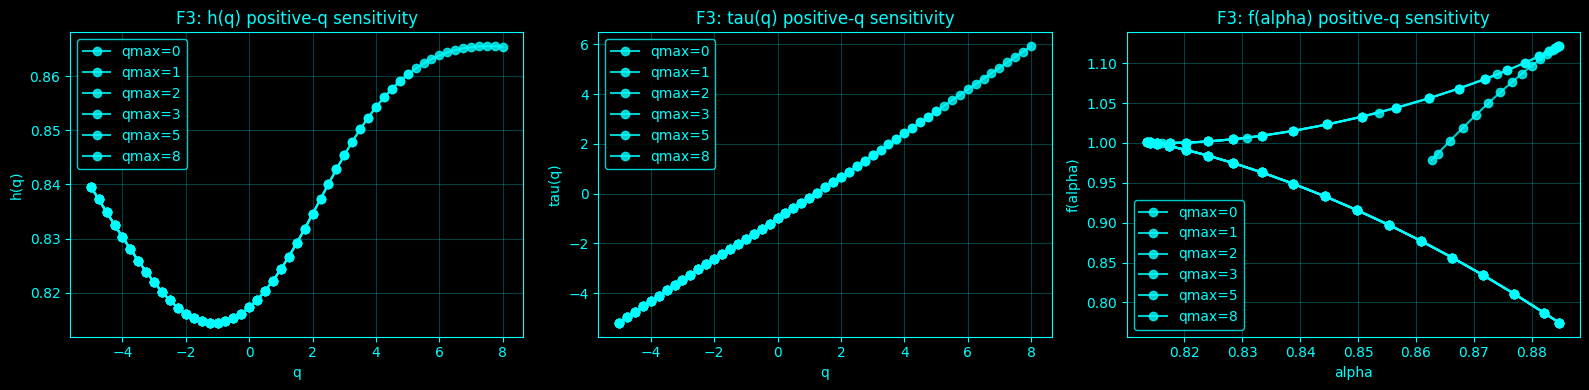

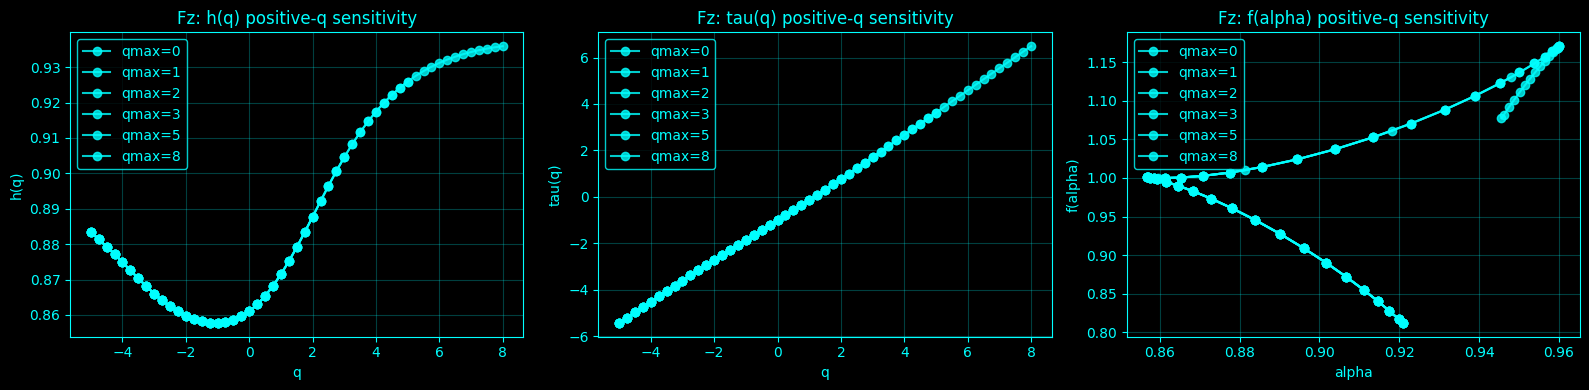

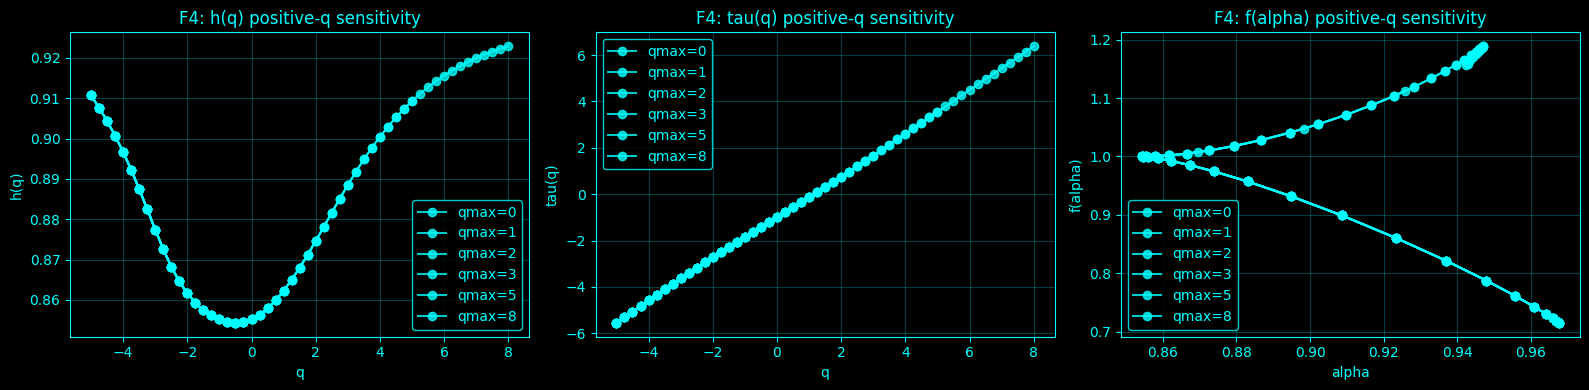

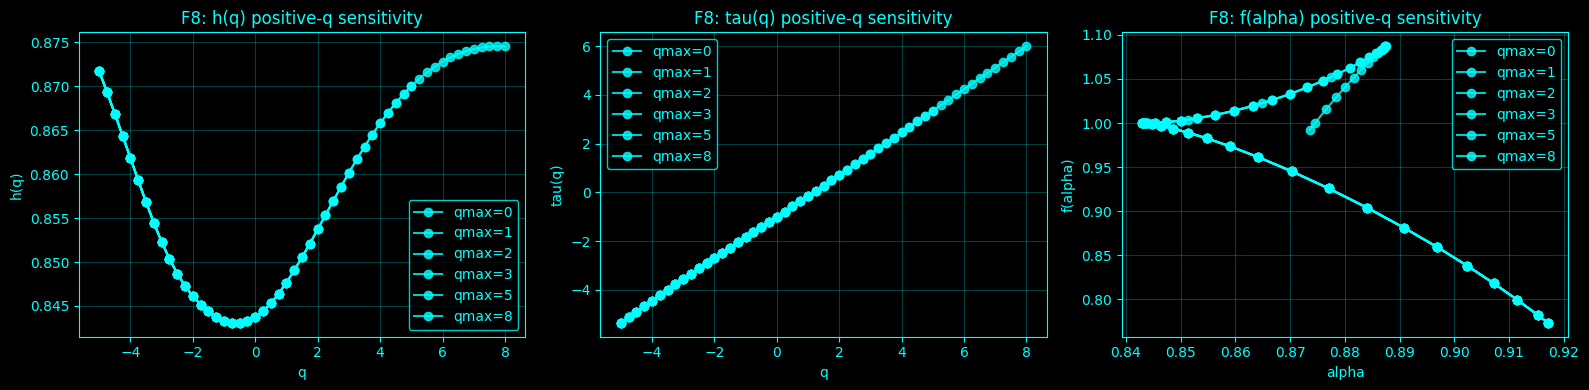

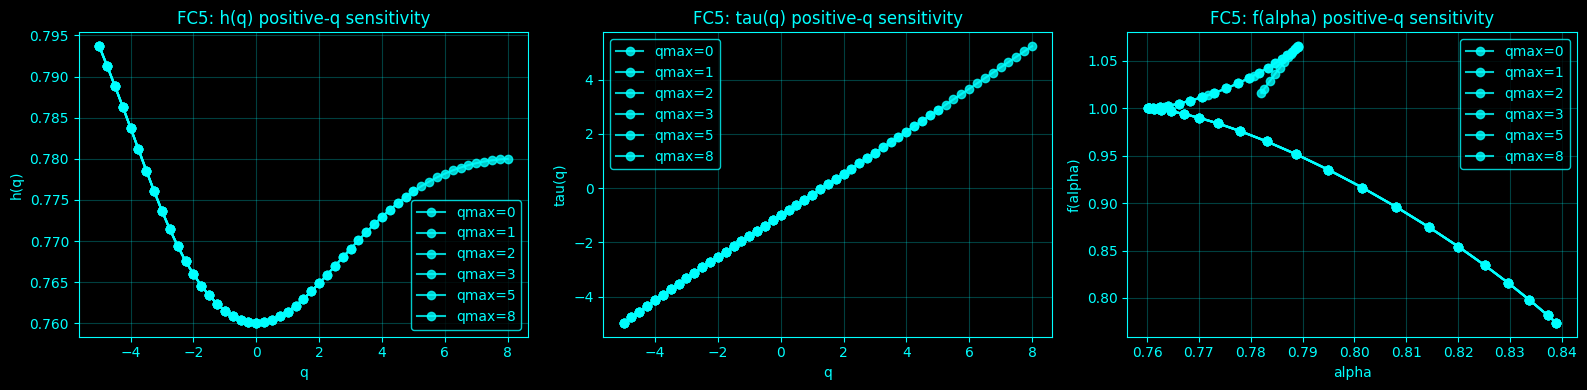

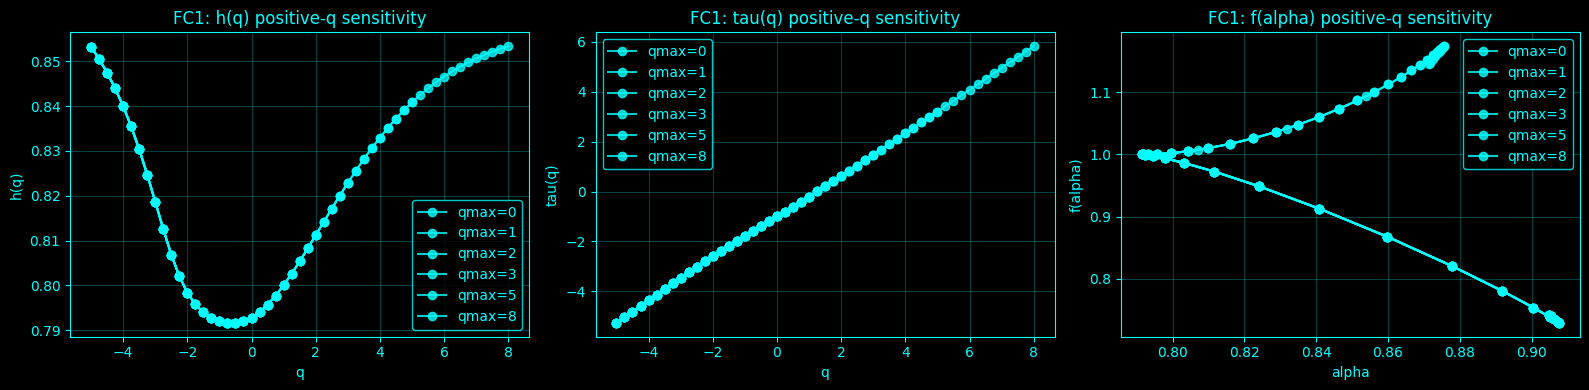

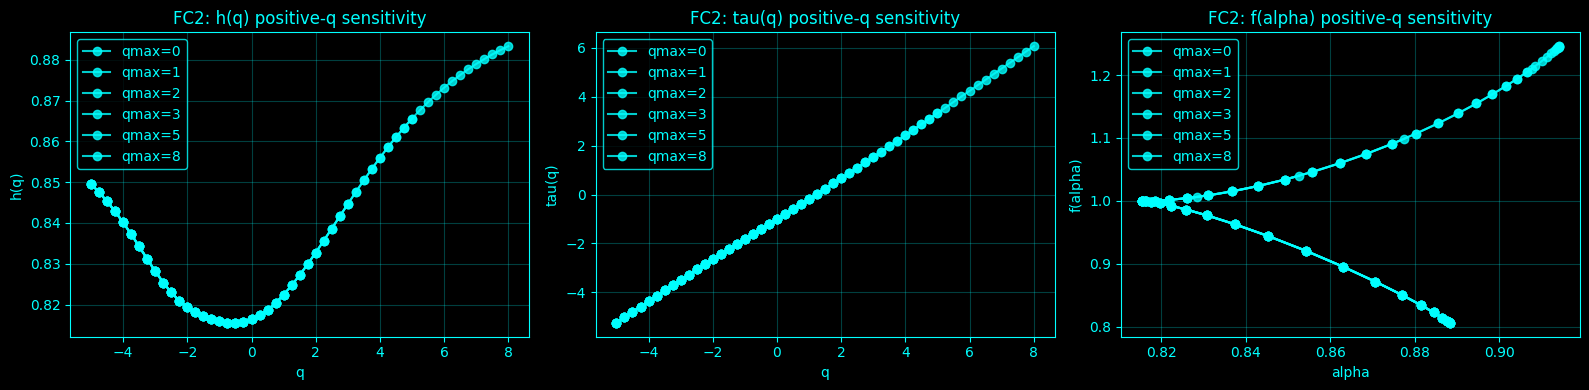

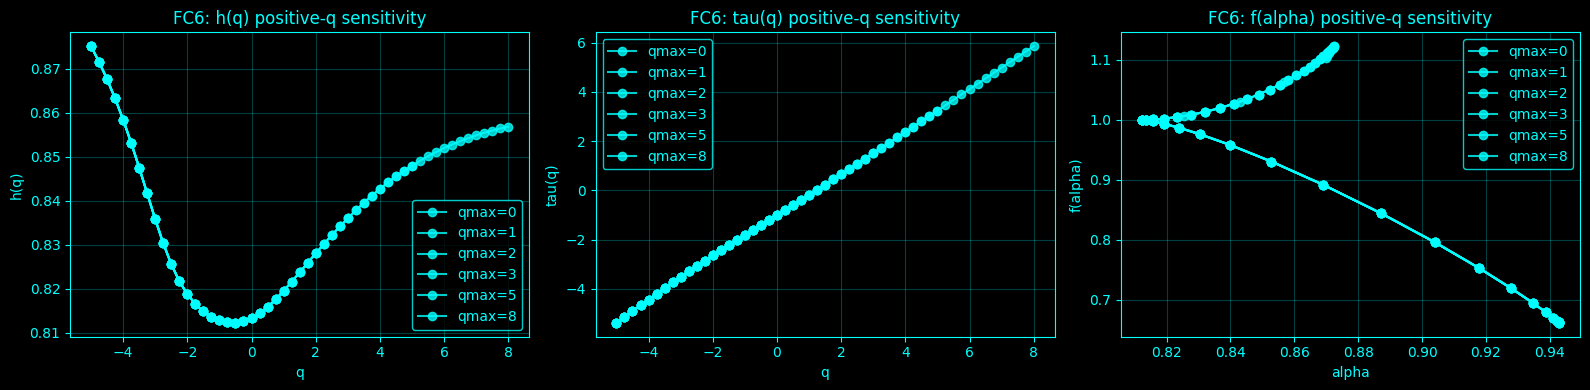

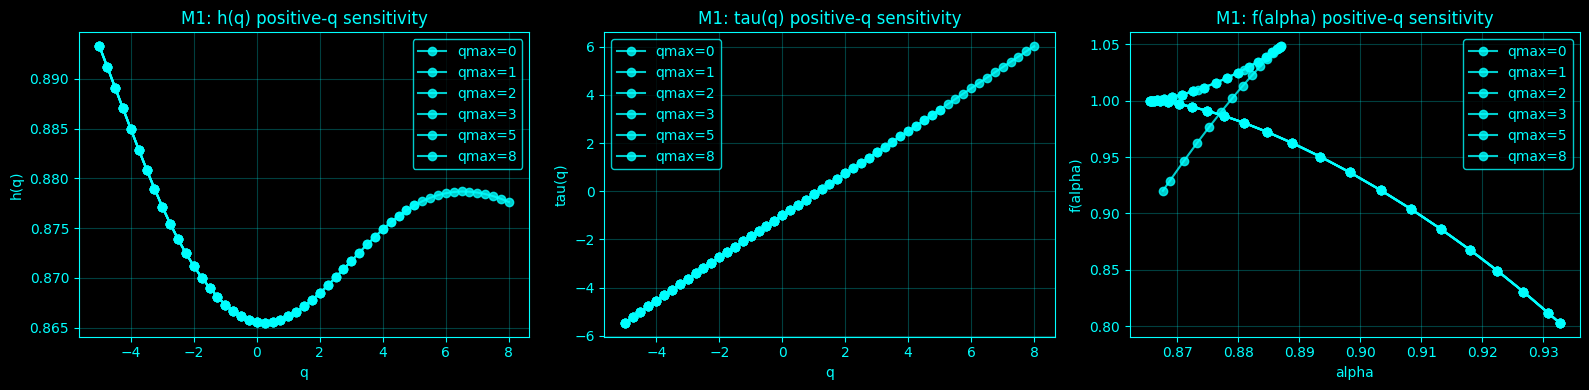

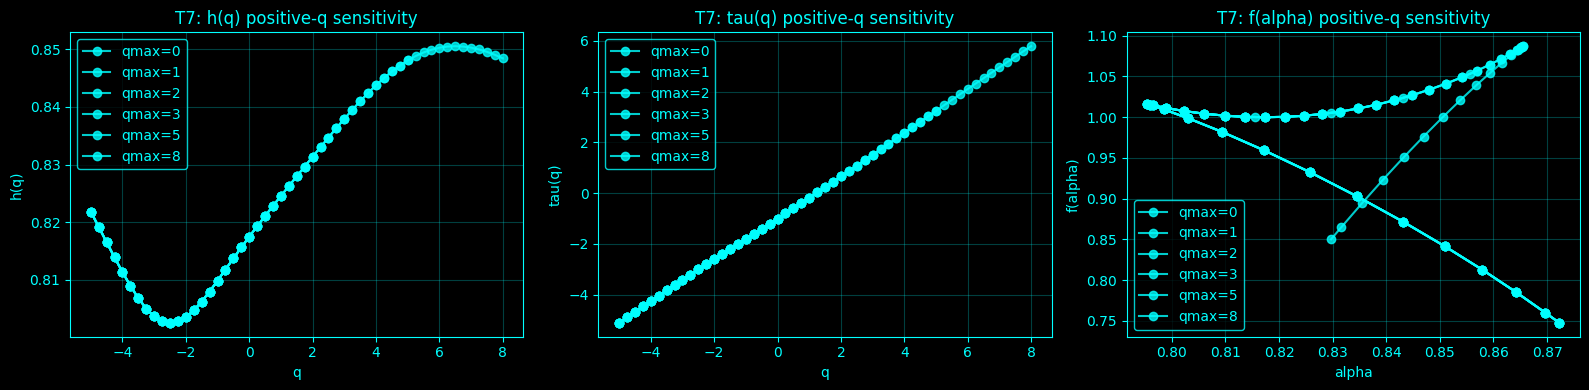

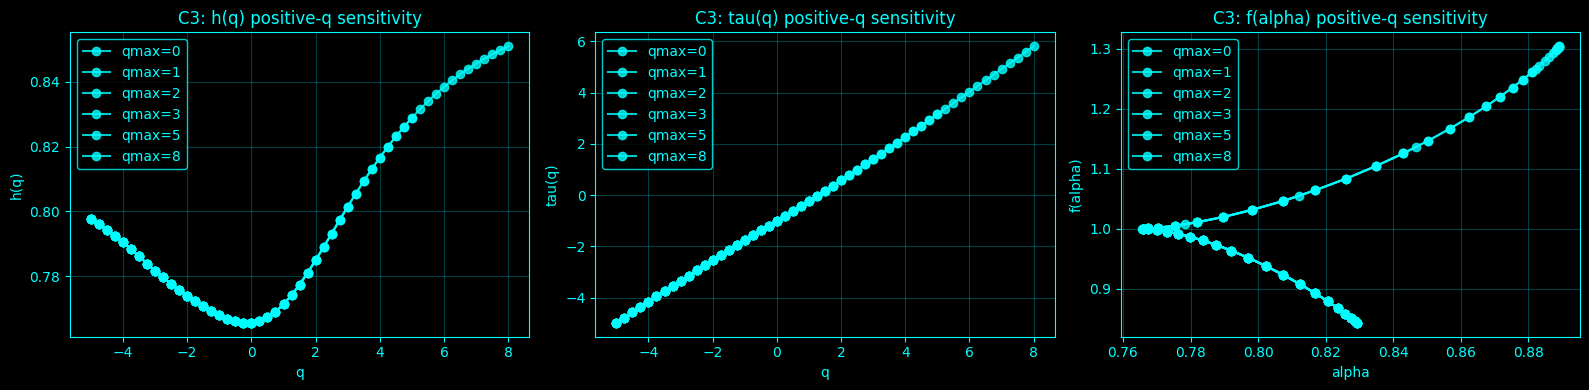

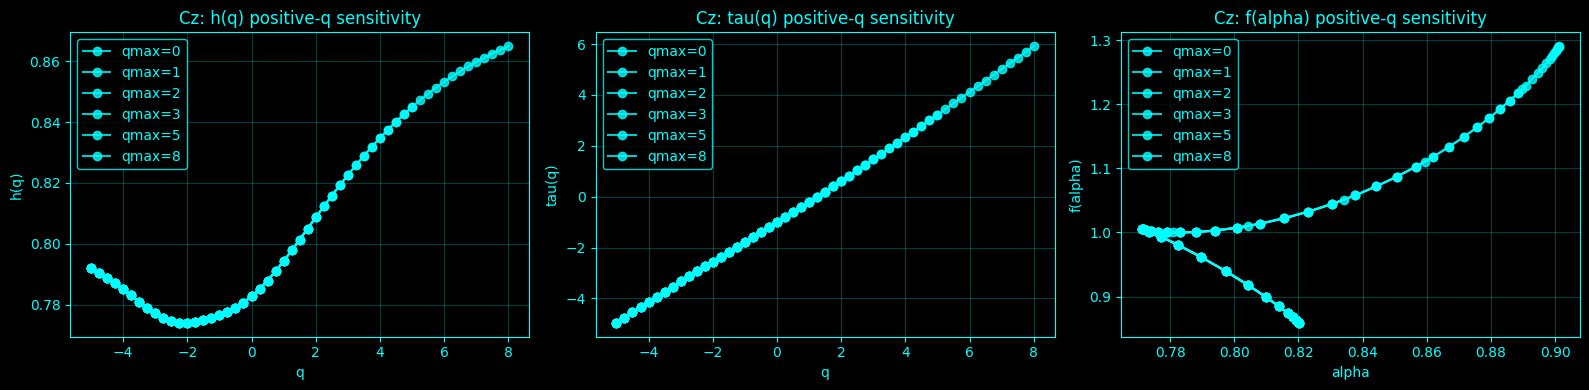

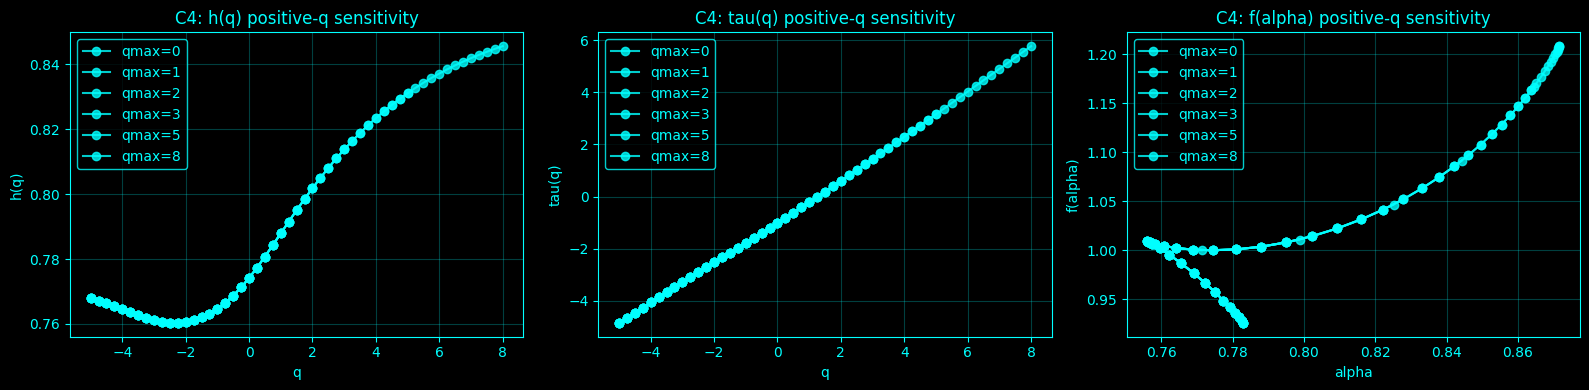

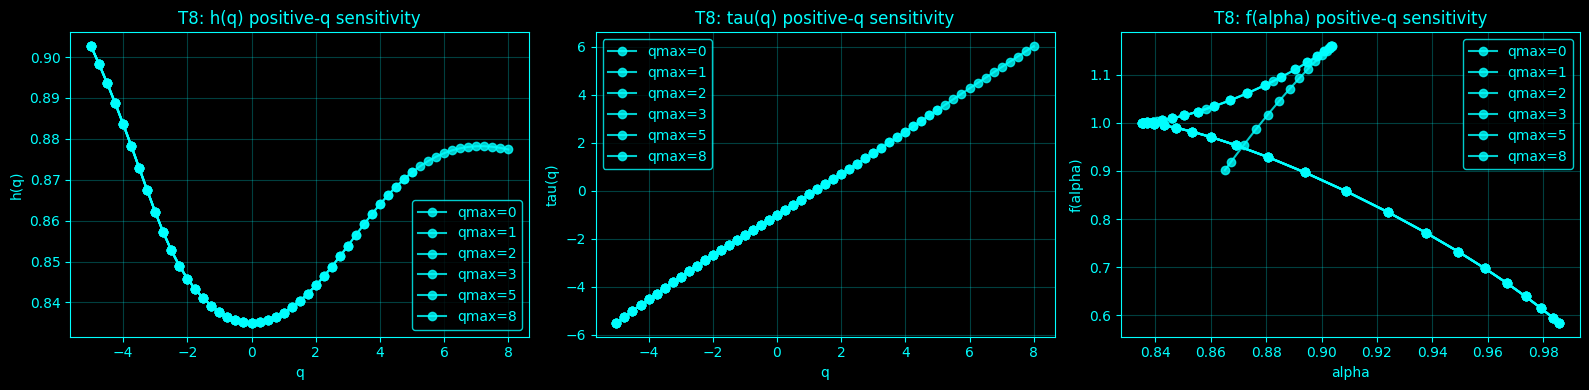

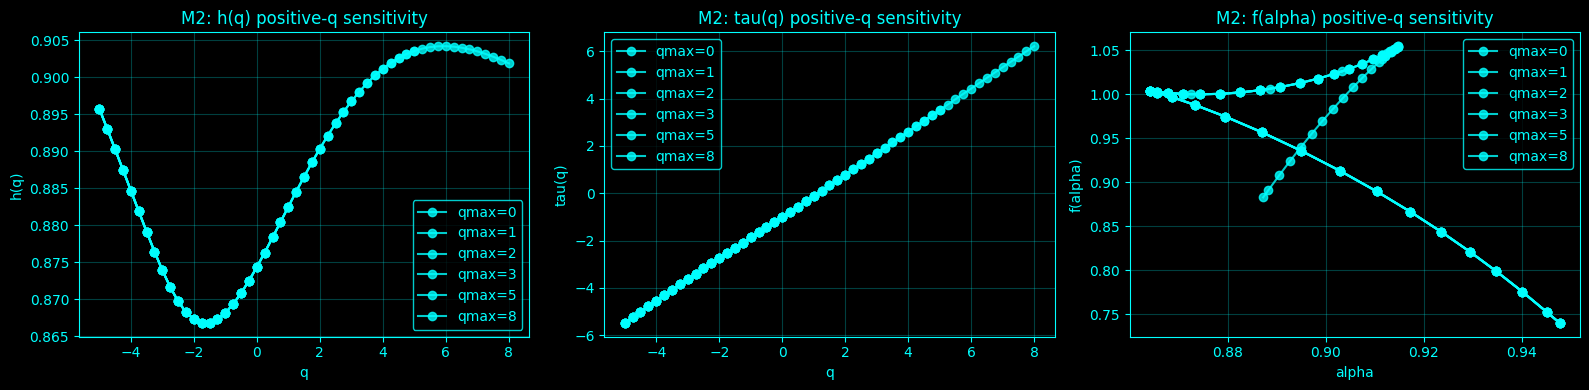

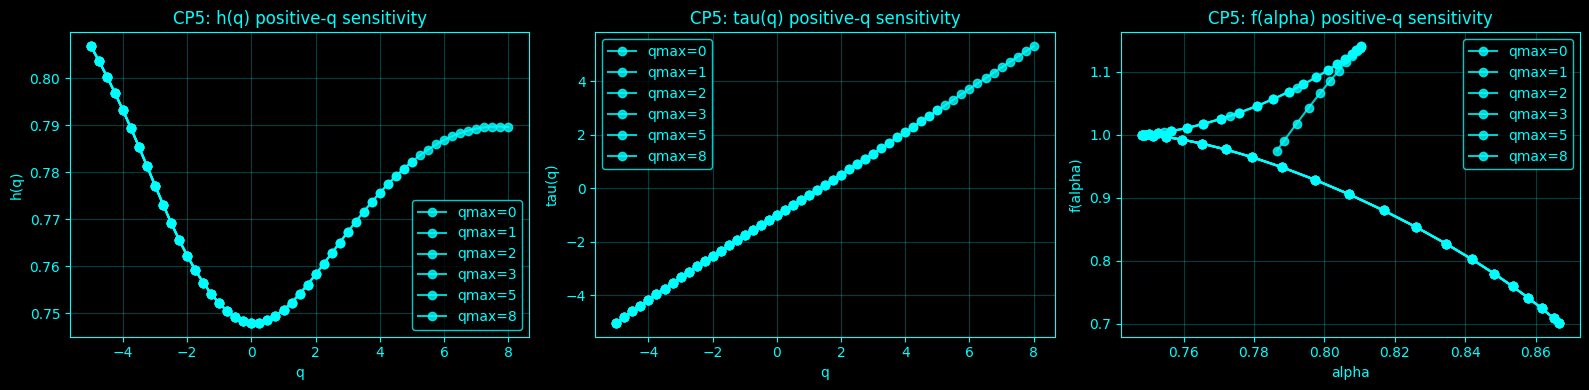

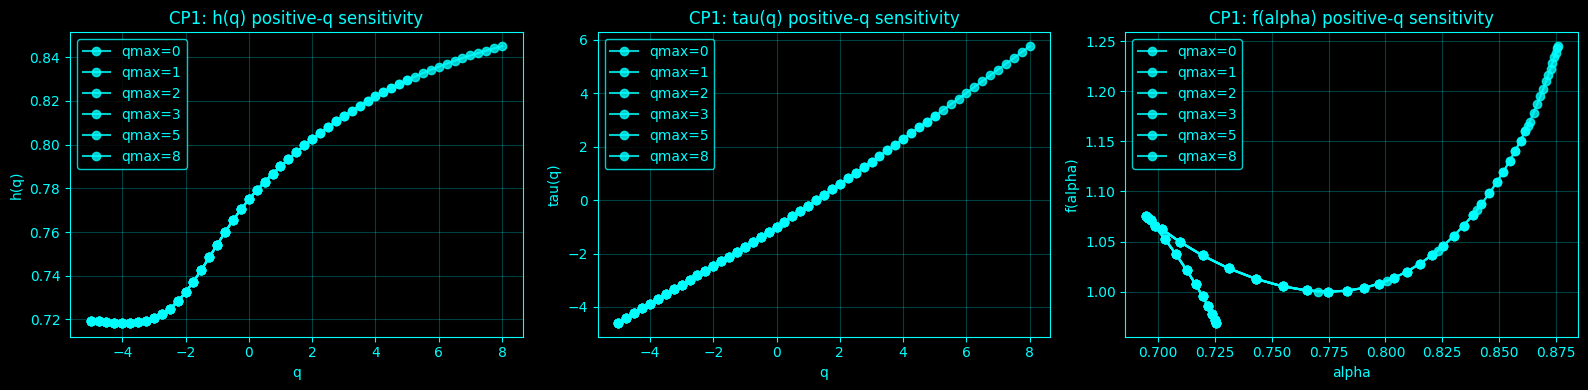

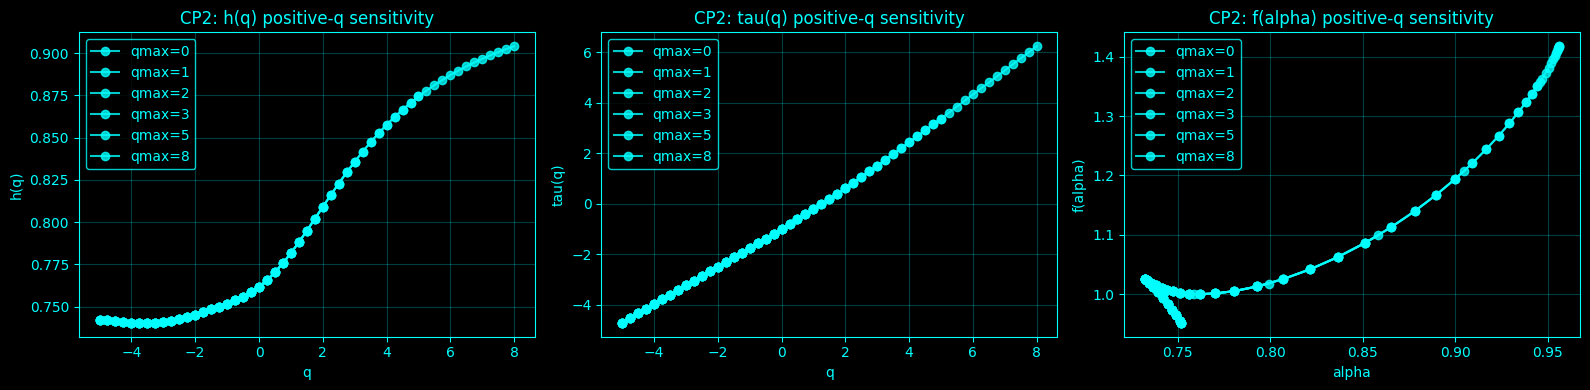

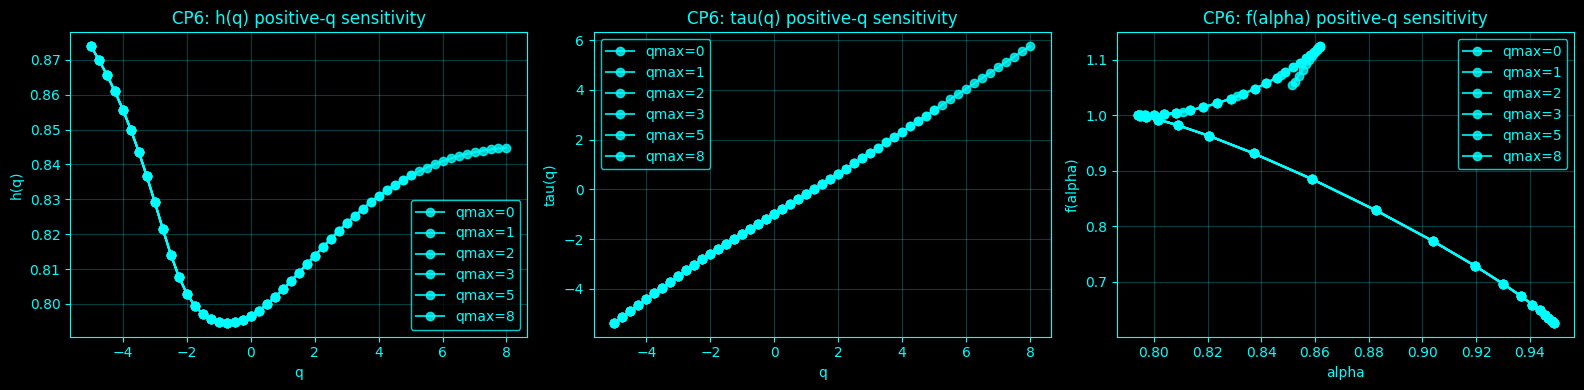

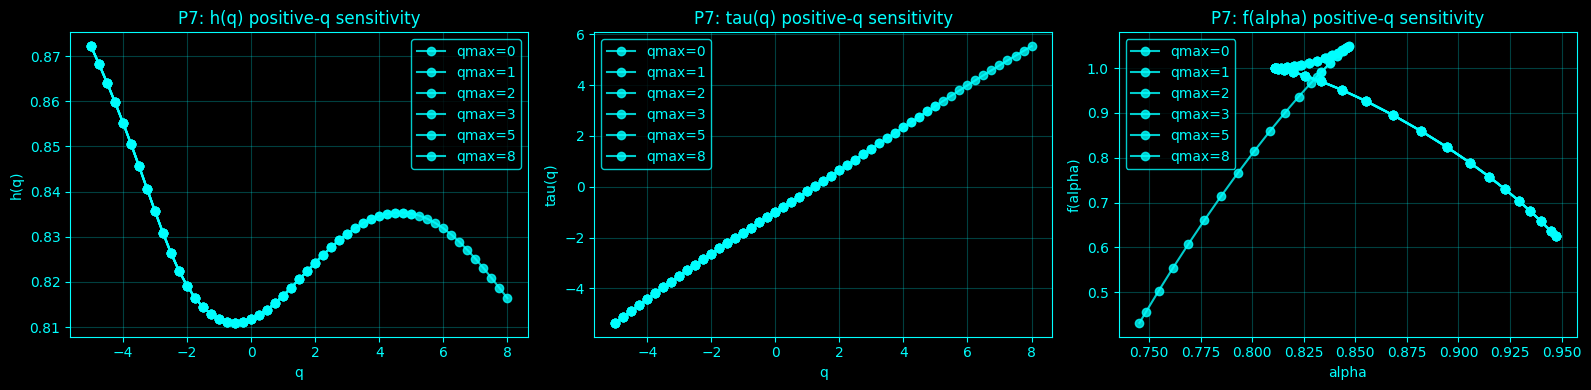

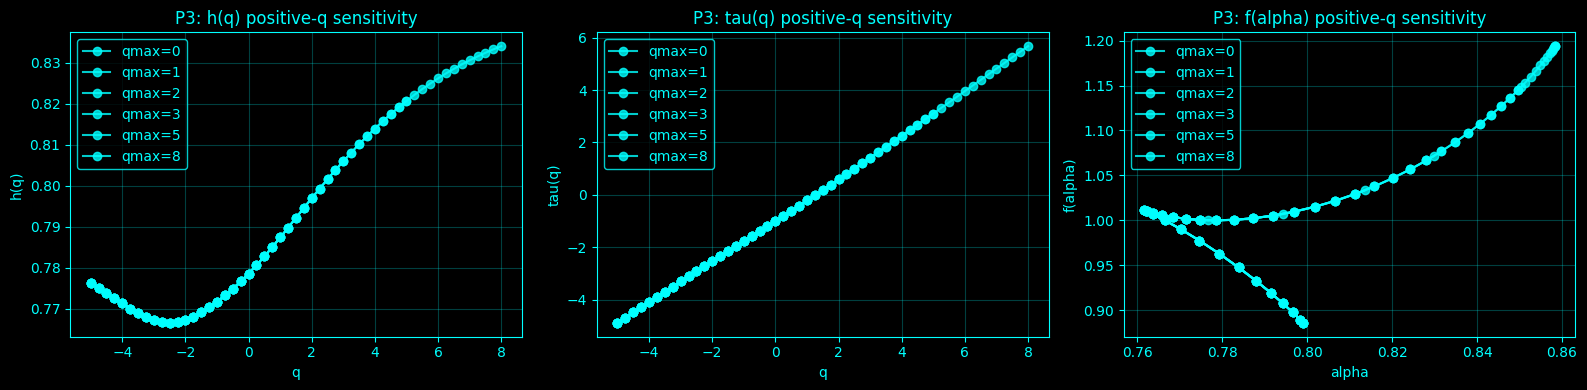

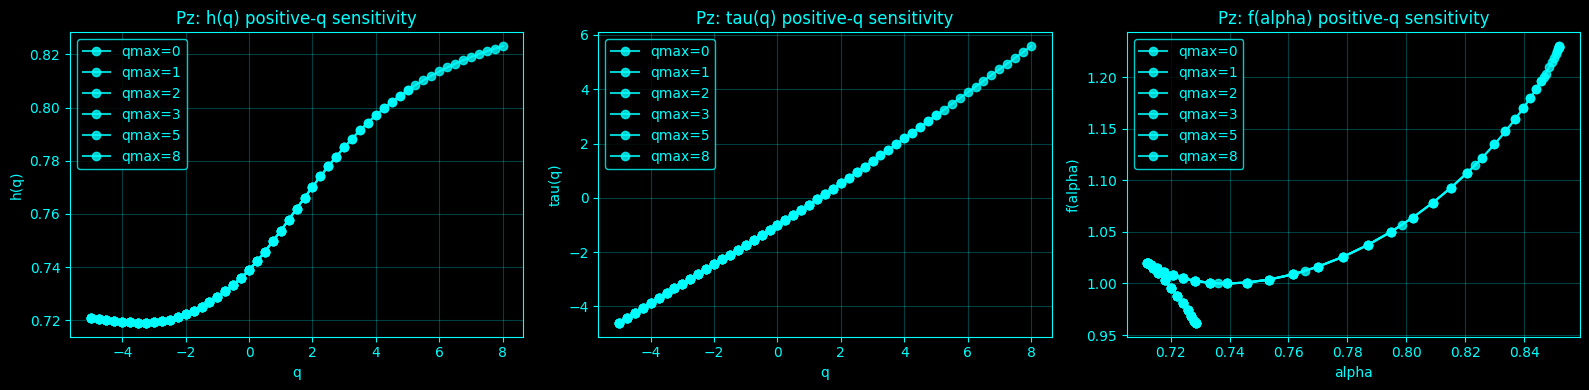

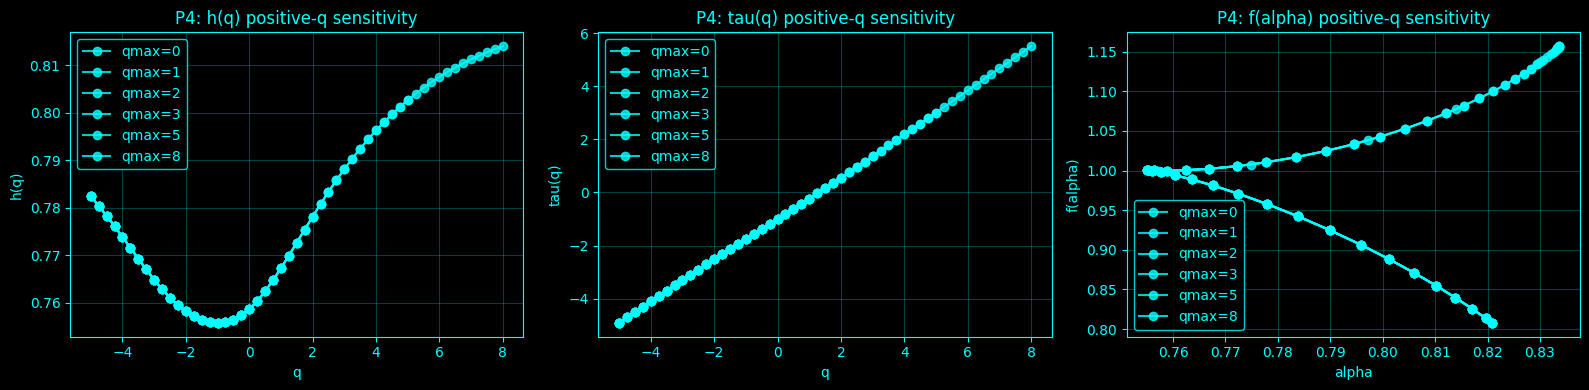

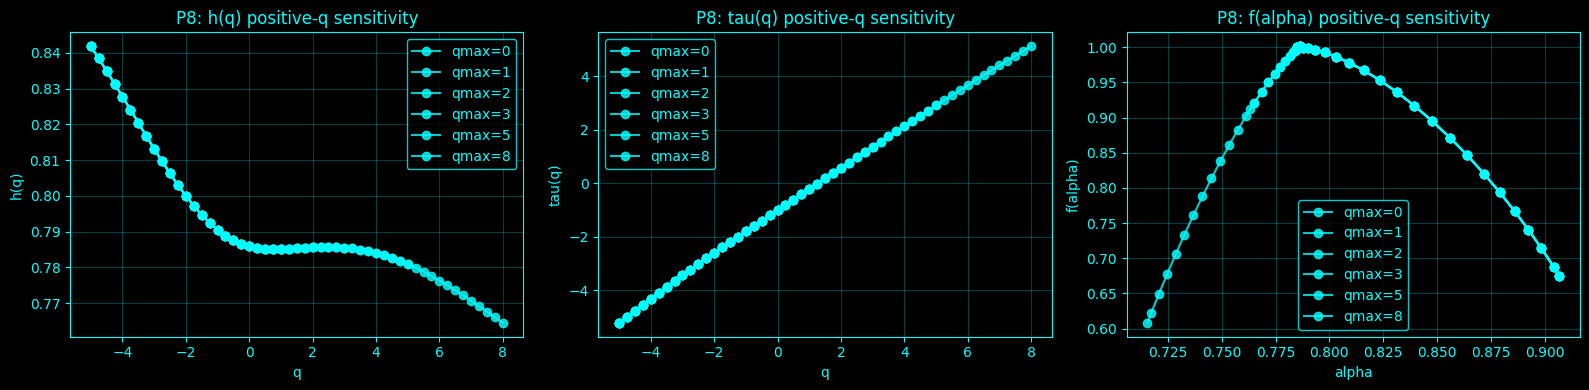

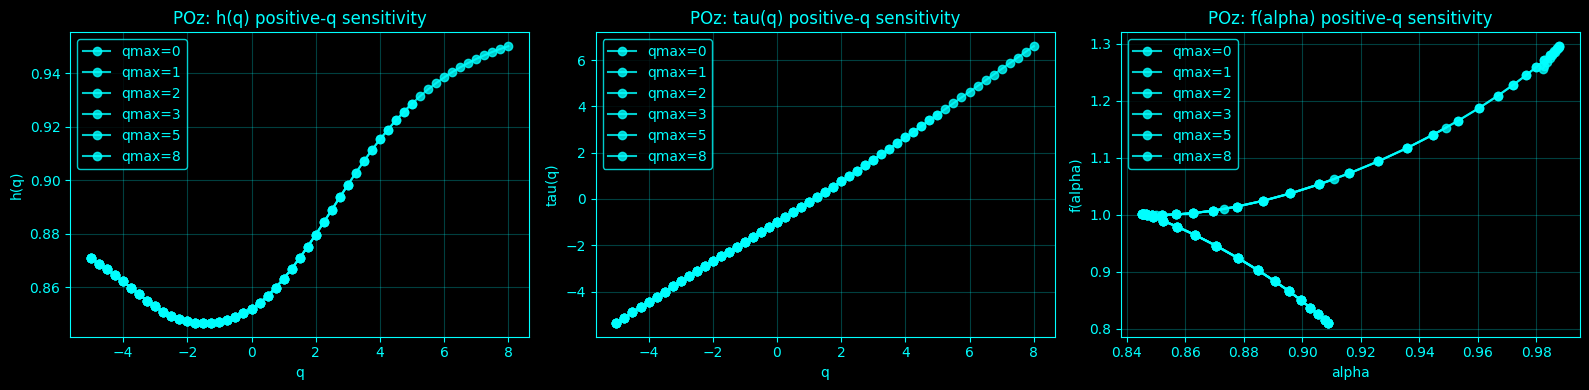

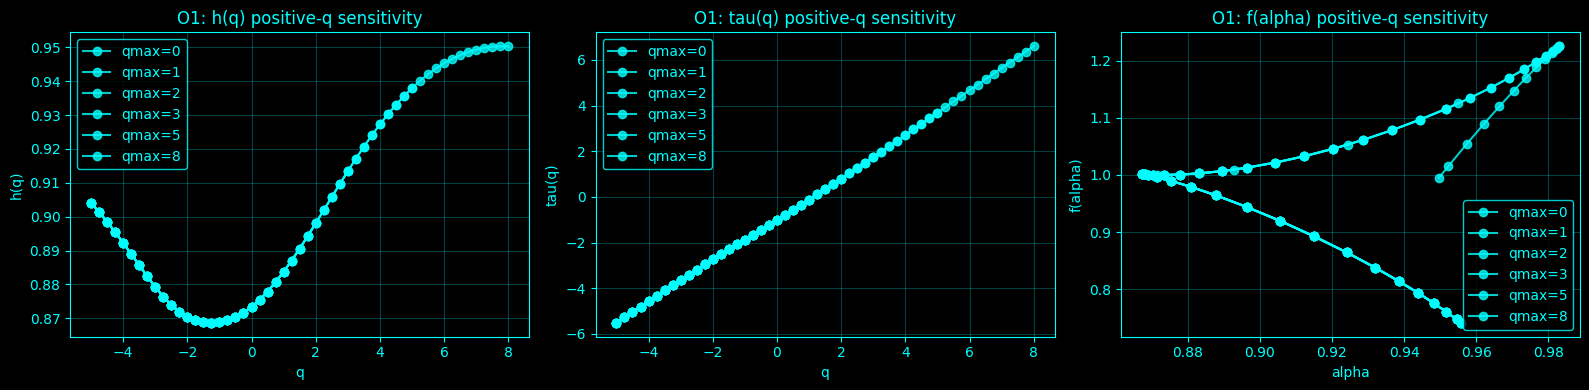

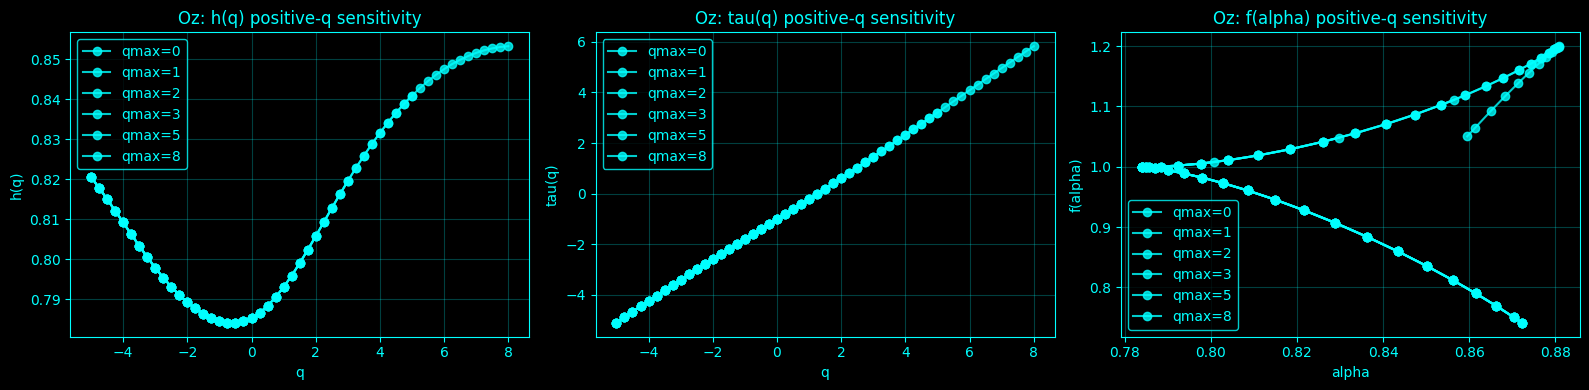

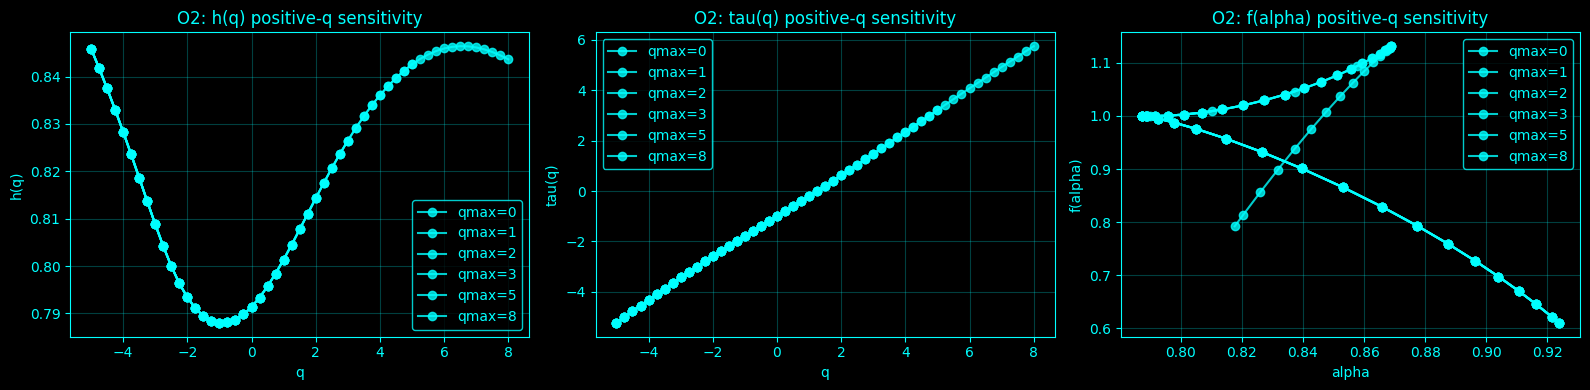


Positive-q dominance summary:
    channel  q_min  q_max  n_q  alpha_min  alpha_max  alpha_width  \
0       Fp1     -5      0   21   0.928410   0.992301     0.063892   
1       Fp1     -5      1   25   0.928410   1.031548     0.103138   
2       Fp1     -5      2   29   0.928410   1.081562     0.153152   
3       Fp1     -5      3   33   0.928410   1.081400     0.152990   
4       Fp1     -5      5   41   0.928410   1.081400     0.152990   
..      ...    ...    ...  ...        ...        ...          ...   
187      O2     -5      1   25   0.787248   0.923863     0.136615   
188      O2     -5      2   29   0.787248   0.923863     0.136615   
189      O2     -5      3   33   0.787248   0.923863     0.136615   
190      O2     -5      5   41   0.787248   0.923863     0.136615   
191      O2     -5      8   53   0.787248   0.923863     0.136615   

     alpha_at_peak    f_peak  asymmetry  peak_locked_min  peak_locked_max  \
0         0.928410  1.024333   0.063892                1       

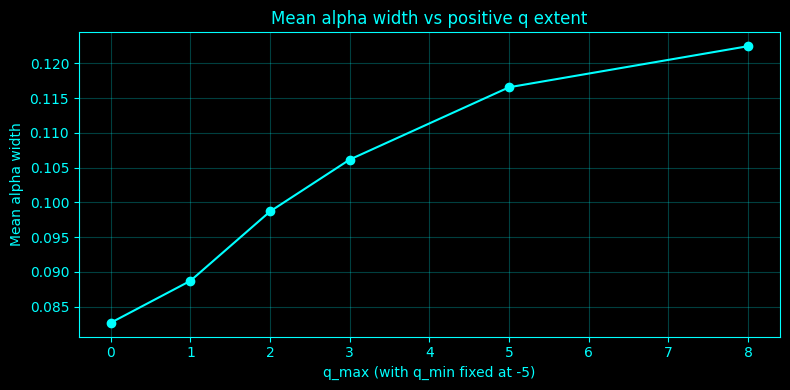

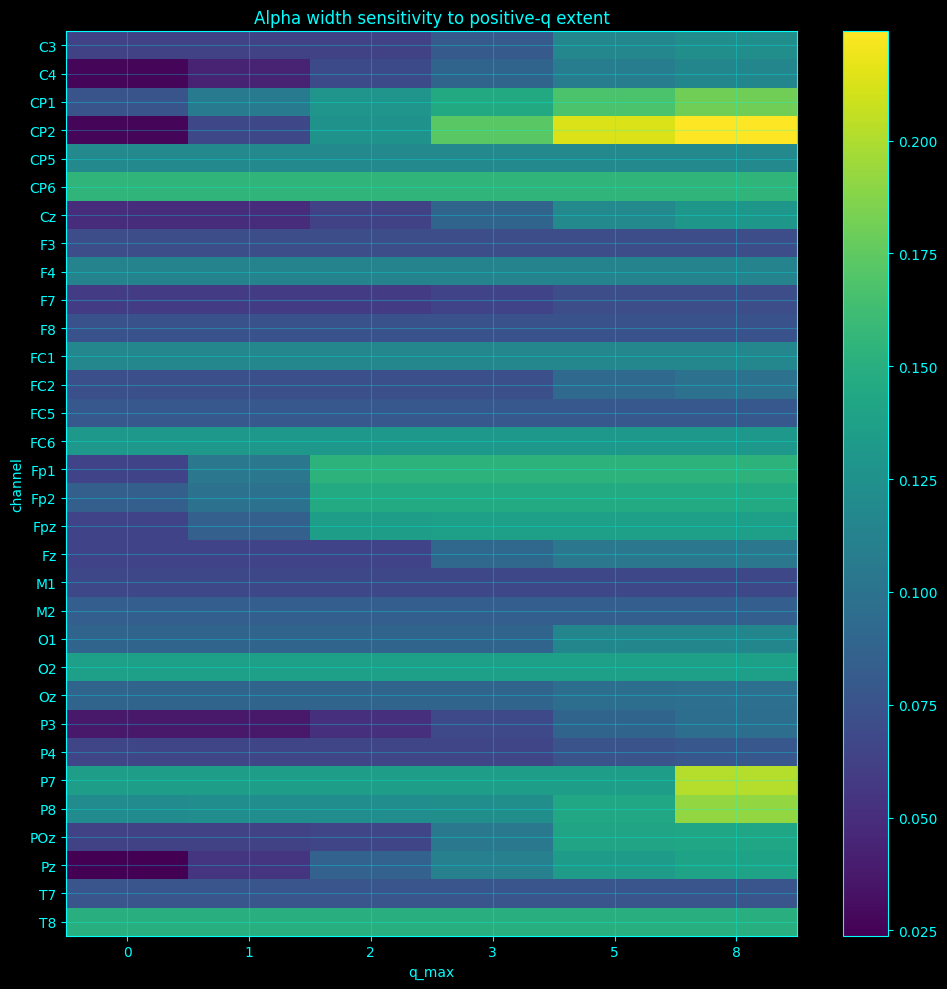


Saved outputs to: /home/a/projects/Complete-Neural-Signal-Analysis/mfdfa_positive_q_dominance
Saved summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/mfdfa_positive_q_dominance/positive_q_dominance_summary.csv


In [14]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")
out_dir = os.path.join(base_dir, "mfdfa_positive_q_dominance")
os.makedirs(out_dir, exist_ok=True)

# Same segment as before
sampling_rate = 1000
start_time, end_time = 814.571, 921.515
start_idx = int(start_time * sampling_rate)
end_idx   = int(end_time * sampling_rate)

eeg_channels = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

channels_to_run = eeg_channels.copy()

# Positive-q study:
# hold q_min fixed, progressively extend q_max rightward
q_min_fixed = -5
q_max_list = [0, 1, 2, 3, 5, 8]
q_step = 0.25

poly_order = 1
lag = np.logspace(0.7, 4, 30).astype(int)
lag = np.unique(lag)

# Plot style
ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.grid(True, alpha=0.25, color=ACCENT)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
    ax.xaxis.label.set_color(ACCENT)
    ax.yaxis.label.set_color(ACCENT)
    ax.title.set_color(ACCENT)

def mfdfa_manual(x, scales, q_vals, order=1):
    x = np.asarray(x, dtype=float)
    N = len(x)
    profile = np.cumsum(x - np.mean(x))
    Fq = np.full((len(scales), len(q_vals)), np.nan, dtype=float)

    for si, s in enumerate(scales):
        s = int(s)
        Ns = N // s
        if Ns < 2:
            continue

        F2_segments = []

        # forward
        for v in range(Ns):
            start = v * s
            stop = start + s
            seg = profile[start:stop]
            t = np.arange(s)
            coeffs = np.polyfit(t, seg, order)
            trend = np.polyval(coeffs, t)
            F2_segments.append(np.mean((seg - trend) ** 2))

        # backward
        for v in range(Ns):
            start = N - (v + 1) * s
            stop = start + s
            seg = profile[start:stop]
            t = np.arange(s)
            coeffs = np.polyfit(t, seg, order)
            trend = np.polyval(coeffs, t)
            F2_segments.append(np.mean((seg - trend) ** 2))

        F2_segments = np.asarray(F2_segments, dtype=float)
        F2_segments = np.maximum(F2_segments, 1e-12)

        for qi, q in enumerate(q_vals):
            if np.isclose(q, 0.0):
                Fq[si, qi] = np.exp(0.5 * np.mean(np.log(F2_segments)))
            else:
                Fq[si, qi] = (np.mean(F2_segments ** (q / 2.0))) ** (1.0 / q)

    return scales, Fq

def estimate_hq(scales, Fq):
    log_s = np.log(scales)
    hq = np.full(Fq.shape[1], np.nan, dtype=float)

    for qi in range(Fq.shape[1]):
        y = Fq[:, qi]
        mask = np.isfinite(y) & (y > 0)
        if np.sum(mask) >= 5:
            coef = np.polyfit(log_s[mask], np.log(y[mask]), 1)
            hq[qi] = coef[0]

    return hq

def compute_multifractal_spectrum(q_vals, hq):
    q_vals = np.asarray(q_vals, dtype=float)
    hq = np.asarray(hq, dtype=float)

    valid = np.isfinite(q_vals) & np.isfinite(hq)
    if np.sum(valid) < 5:
        return {
            "tau": np.full_like(q_vals, np.nan, dtype=float),
            "alpha": np.full_like(q_vals, np.nan, dtype=float),
            "f_alpha": np.full_like(q_vals, np.nan, dtype=float),
        }

    qv = q_vals[valid]
    hv = hq[valid]

    tau_v = qv * hv - 1.0
    alpha_v = np.gradient(tau_v, qv)
    f_alpha_v = qv * alpha_v - tau_v

    tau = np.full_like(q_vals, np.nan, dtype=float)
    alpha = np.full_like(q_vals, np.nan, dtype=float)
    f_alpha = np.full_like(q_vals, np.nan, dtype=float)

    tau[valid] = tau_v
    alpha[valid] = alpha_v
    f_alpha[valid] = f_alpha_v

    return {
        "tau": tau,
        "alpha": alpha,
        "f_alpha": f_alpha,
    }

def summarize_spectrum(alpha, f_alpha):
    alpha = np.asarray(alpha, dtype=float)
    f_alpha = np.asarray(f_alpha, dtype=float)

    valid = np.isfinite(alpha) & np.isfinite(f_alpha)
    if np.sum(valid) < 5:
        return {
            "alpha_min": np.nan,
            "alpha_max": np.nan,
            "alpha_width": np.nan,
            "alpha_at_peak": np.nan,
            "f_peak": np.nan,
            "asymmetry": np.nan,
            "peak_locked_min": np.nan,
            "peak_locked_max": np.nan,
        }

    a = alpha[valid]
    f = f_alpha[valid]

    alpha_min = np.min(a)
    alpha_max = np.max(a)
    alpha_width = alpha_max - alpha_min

    peak_idx = np.argmax(f)
    alpha_at_peak = a[peak_idx]
    f_peak = f[peak_idx]

    left_width = alpha_at_peak - alpha_min
    right_width = alpha_max - alpha_at_peak
    asymmetry = right_width - left_width

    peak_locked_min = np.isclose(alpha_at_peak, alpha_min)
    peak_locked_max = np.isclose(alpha_at_peak, alpha_max)

    return {
        "alpha_min": alpha_min,
        "alpha_max": alpha_max,
        "alpha_width": alpha_width,
        "alpha_at_peak": alpha_at_peak,
        "f_peak": f_peak,
        "asymmetry": asymmetry,
        "peak_locked_min": peak_locked_min,
        "peak_locked_max": peak_locked_max,
    }

def run_mfdfa_setting(x, lag, q_vals, poly_order):
    scales_out, Fq = mfdfa_manual(x, lag, q_vals, order=poly_order)
    hq = estimate_hq(scales_out, Fq)
    spec = compute_multifractal_spectrum(q_vals, hq)
    summary = summarize_spectrum(spec["alpha"], spec["f_alpha"])
    return {
        "scales": scales_out,
        "Fq": Fq,
        "hq": hq,
        "tau": spec["tau"],
        "alpha": spec["alpha"],
        "f_alpha": spec["f_alpha"],
        **summary
    }

# -------------------------------------------------------
# LOAD EEG SEGMENT
# -------------------------------------------------------
EEG_data = np.load(eeg_path, allow_pickle=True)

if EEG_data.ndim != 2:
    raise ValueError(f"Expected 2D EEG array, got shape {EEG_data.shape}")

if EEG_data.shape[1] == len(eeg_channels):
    EEG_segment = EEG_data[start_idx:end_idx, :]
elif EEG_data.shape[0] == len(eeg_channels):
    EEG_segment = EEG_data[:, start_idx:end_idx].T
else:
    raise ValueError(f"Unexpected EEG shape: {EEG_data.shape}")

num_timepoints, num_channels = EEG_segment.shape
print(f"Loaded EEG segment: {num_timepoints} samples x {num_channels} channels")
print(f"Segment: [{start_time}, {end_time}] sec")

lag = lag[(lag > poly_order + 2) & (lag < num_timepoints // 4)]
print("Using scales:", lag)

channel_to_idx = {ch: i for i, ch in enumerate(eeg_channels)}

# -------------------------------------------------------
# RUN POSITIVE-Q DOMINANCE STUDY
# -------------------------------------------------------
summary_rows = []

for channel_name in channels_to_run:
    if channel_name not in channel_to_idx:
        continue

    ch_idx = channel_to_idx[channel_name]
    x = EEG_segment[:, ch_idx].astype(float)

    channel_results = []

    for q_max in q_max_list:
        q_vals = np.arange(q_min_fixed, q_max + q_step / 2, q_step)
        if not np.any(np.isclose(q_vals, 0.0)):
            q_vals = np.sort(np.unique(np.append(q_vals, 0.0)))

        res = run_mfdfa_setting(x, lag, q_vals, poly_order)

        tag = f"qmin_{str(q_min_fixed).replace('-', 'm').replace('.', 'p')}_qmax_{str(q_max).replace('-', 'm').replace('.', 'p')}"
        npz_path = os.path.join(out_dir, f"{channel_name}_{tag}.npz")
        np.savez(
            npz_path,
            channel=channel_name,
            start_time=start_time,
            end_time=end_time,
            sampling_rate=sampling_rate,
            q_vals=q_vals,
            scales=res["scales"],
            Fq=res["Fq"],
            hq=res["hq"],
            tau=res["tau"],
            alpha=res["alpha"],
            f_alpha=res["f_alpha"],
            alpha_min=res["alpha_min"],
            alpha_max=res["alpha_max"],
            alpha_width=res["alpha_width"],
            alpha_at_peak=res["alpha_at_peak"],
            f_peak=res["f_peak"],
            asymmetry=res["asymmetry"],
            peak_locked_min=res["peak_locked_min"],
            peak_locked_max=res["peak_locked_max"],
        )

        channel_results.append((q_max, q_vals, res))

        summary_rows.append({
            "channel": channel_name,
            "q_min": q_min_fixed,
            "q_max": q_max,
            "n_q": len(q_vals),
            "alpha_min": res["alpha_min"],
            "alpha_max": res["alpha_max"],
            "alpha_width": res["alpha_width"],
            "alpha_at_peak": res["alpha_at_peak"],
            "f_peak": res["f_peak"],
            "asymmetry": res["asymmetry"],
            "peak_locked_min": int(bool(res["peak_locked_min"])) if np.isfinite(res["peak_locked_min"]) else np.nan,
            "peak_locked_max": int(bool(res["peak_locked_max"])) if np.isfinite(res["peak_locked_max"]) else np.nan,
            "h_qmin": res["hq"][0] if len(res["hq"]) > 0 else np.nan,
            "h_qmax": res["hq"][-1] if len(res["hq"]) > 0 else np.nan,
            "delta_h": (res["hq"][-1] - res["hq"][0]) if len(res["hq"]) > 1 else np.nan,
        })

    # ---------------------------------------------------
    # PER-CHANNEL PLOTS
    # ---------------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(16, 4), facecolor=BG)
    for ax in axes:
        style_ax(ax)

    for q_max, q_vals, res in channel_results:
        label = f"qmax={q_max}"

        axes[0].plot(
            q_vals, res["hq"],
            marker='o',
            color=ACCENT,
            markerfacecolor=ACCENT,
            markeredgecolor=ACCENT,
            alpha=0.8,
            label=label
        )

        axes[1].plot(
            q_vals, res["tau"],
            marker='o',
            color=ACCENT,
            markerfacecolor=ACCENT,
            markeredgecolor=ACCENT,
            alpha=0.8,
            label=label
        )

        mask = np.isfinite(res["alpha"]) & np.isfinite(res["f_alpha"])
        axes[2].plot(
            res["alpha"][mask], res["f_alpha"][mask],
            marker='o',
            color=ACCENT,
            markerfacecolor=ACCENT,
            markeredgecolor=ACCENT,
            alpha=0.8,
            label=label
        )

    axes[0].set_title(f"{channel_name}: h(q) positive-q sensitivity")
    axes[0].set_xlabel("q")
    axes[0].set_ylabel("h(q)")
    axes[0].legend()

    axes[1].set_title(f"{channel_name}: tau(q) positive-q sensitivity")
    axes[1].set_xlabel("q")
    axes[1].set_ylabel("tau(q)")
    axes[1].legend()

    axes[2].set_title(f"{channel_name}: f(alpha) positive-q sensitivity")
    axes[2].set_xlabel("alpha")
    axes[2].set_ylabel("f(alpha)")
    axes[2].legend()

    plt.tight_layout()
    fig_path = os.path.join(out_dir, f"{channel_name}_positive_q_sensitivity.png")
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

# -------------------------------------------------------
# SAVE SUMMARY TABLE
# -------------------------------------------------------
summary_df = pd.DataFrame(summary_rows)
summary_csv = os.path.join(out_dir, "positive_q_dominance_summary.csv")
summary_df.to_csv(summary_csv, index=False)

print("\nPositive-q dominance summary:")
print(summary_df)

# -------------------------------------------------------
# GLOBAL SUMMARY PLOTS
# -------------------------------------------------------
mean_width = summary_df.groupby("q_max")["alpha_width"].mean().reset_index()

fig, ax = plt.subplots(figsize=(8, 4), facecolor=BG)
style_ax(ax)
ax.plot(
    mean_width["q_max"], mean_width["alpha_width"],
    marker='o',
    color=ACCENT,
    markerfacecolor=ACCENT,
    markeredgecolor=ACCENT
)
ax.set_title("Mean alpha width vs positive q extent")
ax.set_xlabel("q_max (with q_min fixed at -5)")
ax.set_ylabel("Mean alpha width")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "mean_alpha_width_vs_qmax.png"), dpi=150, bbox_inches="tight")
plt.show()
plt.close()

pivot = summary_df.pivot_table(
    index="channel",
    columns="q_max",
    values="alpha_width",
    aggfunc="mean"
).sort_index(axis=1)

fig, ax = plt.subplots(figsize=(10, 10), facecolor=BG)
style_ax(ax)
im = ax.imshow(pivot.values, aspect="auto")
ax.set_title("Alpha width sensitivity to positive-q extent")
ax.set_xlabel("q_max")
ax.set_ylabel("channel")
ax.set_xticks(np.arange(len(pivot.columns)))
ax.set_xticklabels([str(c) for c in pivot.columns], color=ACCENT)
ax.set_yticks(np.arange(len(pivot.index)))
ax.set_yticklabels(list(pivot.index), color=ACCENT)

cbar = plt.colorbar(im, ax=ax)
cbar.ax.yaxis.set_tick_params(color=ACCENT)
plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)

plt.tight_layout()
plt.savefig(os.path.join(out_dir, "alpha_width_positive_q_heatmap.png"), dpi=150, bbox_inches="tight")
plt.show()
plt.close()

print(f"\nSaved outputs to: {out_dir}")
print(f"Saved summary CSV: {summary_csv}")

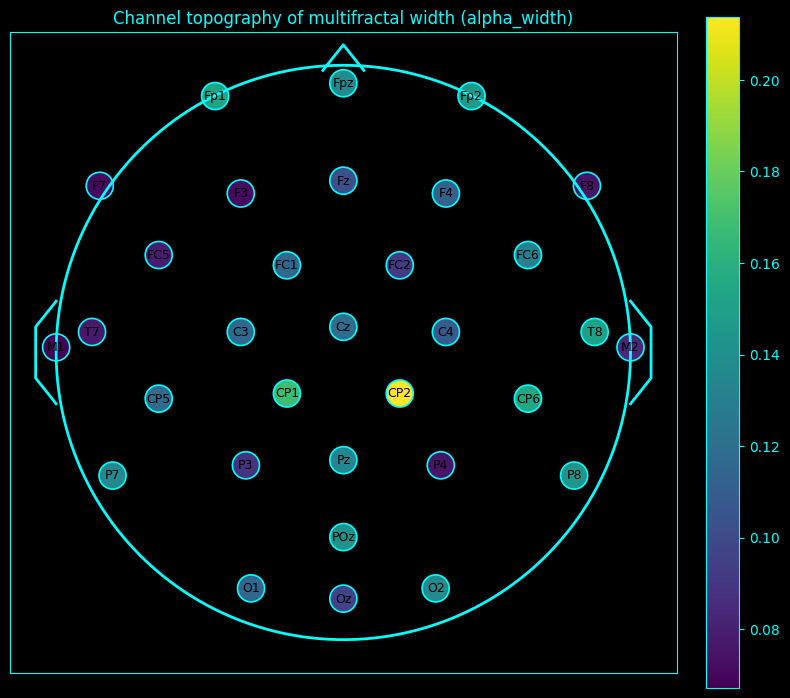

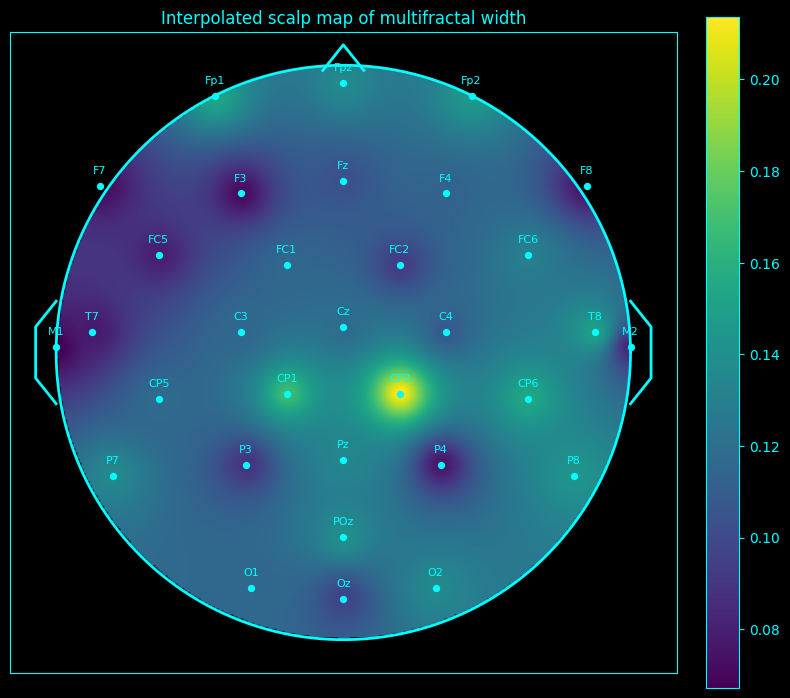


Saved outputs to: /home/a/projects/Complete-Neural-Signal-Analysis/mfdfa_topography
Scatter map: /home/a/projects/Complete-Neural-Signal-Analysis/mfdfa_topography/alpha_width_topography_scatter.png
Interpolated map: /home/a/projects/Complete-Neural-Signal-Analysis/mfdfa_topography/alpha_width_topography_interpolated.png
Table: /home/a/projects/Complete-Neural-Signal-Analysis/mfdfa_topography/alpha_width_topography_table.csv


In [15]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"

# Baseline multifractal summary from the standard [-5,5] run
summary_path = os.path.join(
    base_dir,
    "mfdfa_manual_spectrum_results",
    "mfdfa_manual_spectrum_summary.csv"
)

out_dir = os.path.join(base_dir, "mfdfa_topography")
os.makedirs(out_dir, exist_ok=True)

ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

# -------------------------------------------------------
# STYLE HELPER
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
    ax.xaxis.label.set_color(ACCENT)
    ax.yaxis.label.set_color(ACCENT)
    ax.title.set_color(ACCENT)

# -------------------------------------------------------
# LOAD SUMMARY
# -------------------------------------------------------
summary_df = pd.read_csv(summary_path)

required_cols = {"channel", "alpha_width"}
missing = required_cols - set(summary_df.columns)
if missing:
    raise ValueError(f"Missing required columns in summary: {missing}")

# -------------------------------------------------------
# APPROXIMATE 10-20 2D POSITIONS
# Manual coordinates for plotting only
# x: left(-) to right(+)
# y: posterior(-) to anterior(+)
# -------------------------------------------------------
channel_pos = {
    "Fp1": (-0.50,  1.00),
    "Fpz": ( 0.00,  1.05),
    "Fp2": ( 0.50,  1.00),

    "F7":  (-0.95,  0.65),
    "F3":  (-0.40,  0.62),
    "Fz":  ( 0.00,  0.67),
    "F4":  ( 0.40,  0.62),
    "F8":  ( 0.95,  0.65),

    "FC5": (-0.72,  0.38),
    "FC1": (-0.22,  0.34),
    "FC2": ( 0.22,  0.34),
    "FC6": ( 0.72,  0.38),

    "M1":  (-1.12,  0.02),
    "T7":  (-0.98,  0.08),
    "C3":  (-0.40,  0.08),
    "Cz":  ( 0.00,  0.10),
    "C4":  ( 0.40,  0.08),
    "T8":  ( 0.98,  0.08),
    "M2":  ( 1.12,  0.02),

    "CP5": (-0.72, -0.18),
    "CP1": (-0.22, -0.16),
    "CP2": ( 0.22, -0.16),
    "CP6": ( 0.72, -0.18),

    "P7":  (-0.90, -0.48),
    "P3":  (-0.38, -0.44),
    "Pz":  ( 0.00, -0.42),
    "P4":  ( 0.38, -0.44),
    "P8":  ( 0.90, -0.48),

    "POz": ( 0.00, -0.72),
    "O1":  (-0.36, -0.92),
    "Oz":  ( 0.00, -0.96),
    "O2":  ( 0.36, -0.92),
}

plot_df = summary_df[summary_df["channel"].isin(channel_pos.keys())].copy()

plot_df["x"] = plot_df["channel"].map(lambda c: channel_pos[c][0])
plot_df["y"] = plot_df["channel"].map(lambda c: channel_pos[c][1])

# -------------------------------------------------------
# SIMPLE IDW INTERPOLATION
# -------------------------------------------------------
def idw_interpolate(xy_points, values, grid_x, grid_y, power=2, eps=1e-12):
    """
    Inverse-distance weighting interpolation.
    """
    gx = grid_x[..., None]
    gy = grid_y[..., None]

    px = xy_points[:, 0][None, None, :]
    py = xy_points[:, 1][None, None, :]

    dist2 = (gx - px)**2 + (gy - py)**2
    dist2 = np.maximum(dist2, eps)

    weights = 1.0 / (dist2 ** (power / 2.0))
    z = np.sum(weights * values[None, None, :], axis=2) / np.sum(weights, axis=2)
    return z

# -------------------------------------------------------
# HEAD GEOMETRY
# -------------------------------------------------------
theta = np.linspace(0, 2 * np.pi, 400)
head_r = 1.12
head_x = head_r * np.cos(theta)
head_y = head_r * np.sin(theta)

# nose
nose_x = np.array([-0.08, 0.00, 0.08])
nose_y = np.array([1.10, 1.20, 1.10])

# ears
ear_left_x  = np.array([-1.12, -1.20, -1.20, -1.12])
ear_left_y  = np.array([ 0.20,  0.10, -0.10, -0.20])
ear_right_x = -ear_left_x
ear_right_y = ear_left_y

# -------------------------------------------------------
# GRID FOR INTERPOLATION
# -------------------------------------------------------
gx = np.linspace(-1.2, 1.2, 300)
gy = np.linspace(-1.2, 1.2, 300)
GX, GY = np.meshgrid(gx, gy)

points = plot_df[["x", "y"]].values
values = plot_df["alpha_width"].values.astype(float)

Z = idw_interpolate(points, values, GX, GY, power=2)

# mask outside head
mask = (GX**2 + GY**2) <= (head_r**2)
Z_masked = np.where(mask, Z, np.nan)

# -------------------------------------------------------
# 1) LABELLED ELECTRODE SCATTER MAP
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 8), facecolor=BG)
style_ax(ax)

sc = ax.scatter(
    plot_df["x"], plot_df["y"],
    c=plot_df["alpha_width"],
    s=380,
    edgecolors=ACCENT,
    linewidths=1.2
)

for _, row in plot_df.iterrows():
    ax.text(row["x"], row["y"], row["channel"], ha="center", va="center", fontsize=9, color="black")

ax.plot(head_x, head_y, color=ACCENT, linewidth=2)
ax.plot(nose_x, nose_y, color=ACCENT, linewidth=2)
ax.plot(ear_left_x, ear_left_y, color=ACCENT, linewidth=2)
ax.plot(ear_right_x, ear_right_y, color=ACCENT, linewidth=2)

ax.set_title("Channel topography of multifractal width (alpha_width)")
ax.set_xlim(-1.3, 1.3)
ax.set_ylim(-1.25, 1.25)
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])

cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.yaxis.set_tick_params(color=ACCENT)
plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)

scatter_path = os.path.join(out_dir, "alpha_width_topography_scatter.png")
plt.tight_layout()
plt.savefig(scatter_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# 2) INTERPOLATED SCALP MAP
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 8), facecolor=BG)
style_ax(ax)

im = ax.imshow(
    Z_masked,
    origin="lower",
    extent=[gx.min(), gx.max(), gy.min(), gy.max()],
    aspect="equal"
)

ax.scatter(
    plot_df["x"], plot_df["y"],
    color=ACCENT,
    s=18
)

for _, row in plot_df.iterrows():
    ax.text(row["x"], row["y"] + 0.04, row["channel"], ha="center", va="bottom", fontsize=8, color=ACCENT)

ax.plot(head_x, head_y, color=ACCENT, linewidth=2)
ax.plot(nose_x, nose_y, color=ACCENT, linewidth=2)
ax.plot(ear_left_x, ear_left_y, color=ACCENT, linewidth=2)
ax.plot(ear_right_x, ear_right_y, color=ACCENT, linewidth=2)

ax.set_title("Interpolated scalp map of multifractal width")
ax.set_xlim(-1.3, 1.3)
ax.set_ylim(-1.25, 1.25)
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.yaxis.set_tick_params(color=ACCENT)
plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)

interp_path = os.path.join(out_dir, "alpha_width_topography_interpolated.png")
plt.tight_layout()
plt.savefig(interp_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# 3) SAVE TOPOGRAPHY TABLE
# -------------------------------------------------------
topo_table_path = os.path.join(out_dir, "alpha_width_topography_table.csv")
plot_df[["channel", "alpha_width", "x", "y"]].to_csv(topo_table_path, index=False)

print("\nSaved outputs to:", out_dir)
print("Scatter map:", scatter_path)
print("Interpolated map:", interp_path)
print("Table:", topo_table_path)

Cluster assignments:
   channel  cluster       pc1       pc2  alpha_min  alpha_max  alpha_width  \
0      CP1        0 -5.885881  1.079863   0.694686   0.862500     0.167814   
1       Pz        0 -4.997667  2.032502   0.712140   0.846551     0.134411   
2      CP2        0 -4.827311  2.419641   0.732067   0.945807     0.213740   
3       C4        0 -4.297838  1.450182   0.756056   0.864513     0.108457   
4       P3        0 -4.013995  0.909669   0.761683   0.850430     0.088748   
5       Cz        0 -3.245225  1.464655   0.771201   0.889686     0.118485   
6       T7        0 -3.216857 -1.272211   0.795449   0.872312     0.076863   
7       F7        0 -3.097096 -0.621779   0.808386   0.879728     0.071342   
8      POz        0 -2.674771  1.852127   0.845105   0.985663     0.140558   
9      Fp1        1 -3.575554 -6.950057   0.928410   1.081400     0.152990   
10     Fpz        1 -3.311333 -5.488482   0.941263   1.077939     0.136676   
11     Fp2        1 -3.130901 -5.614268   0

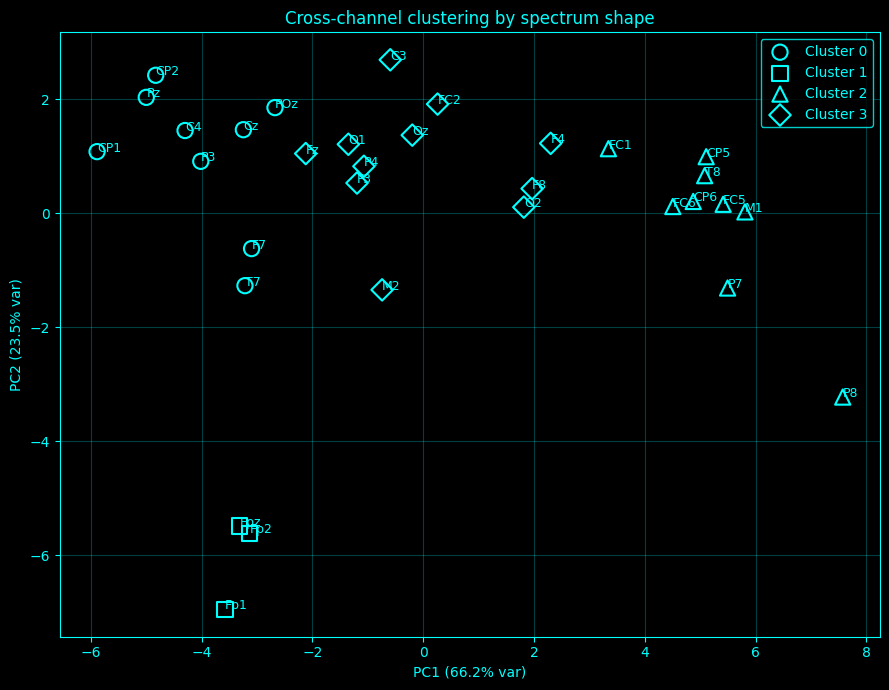

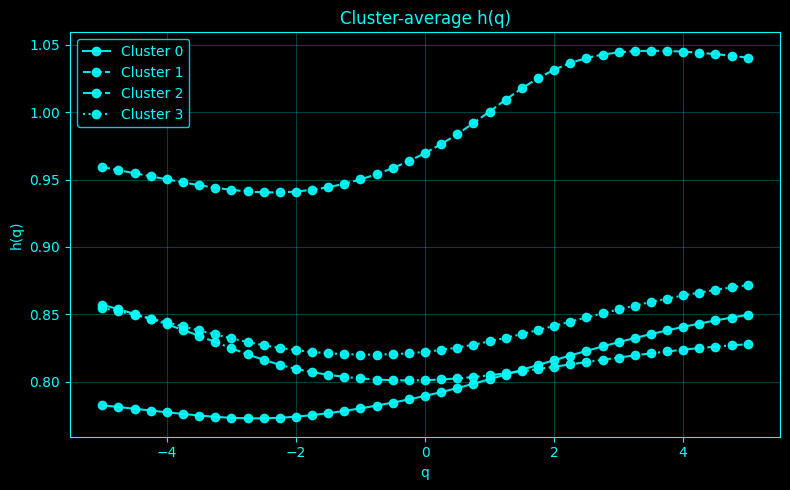

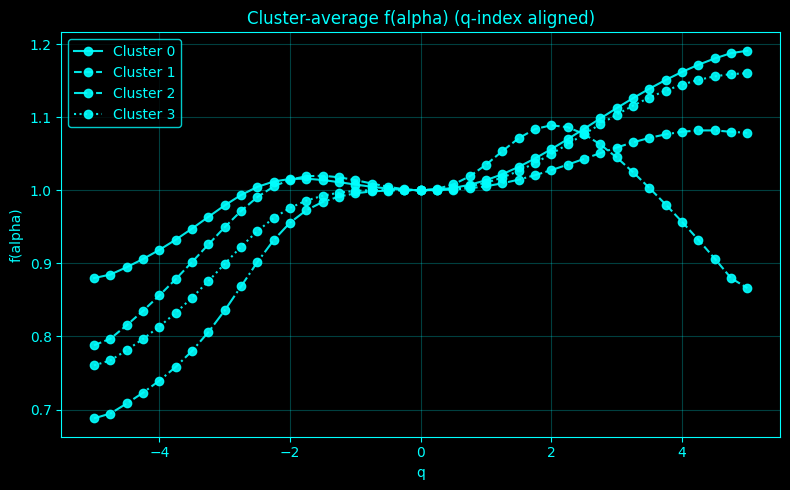

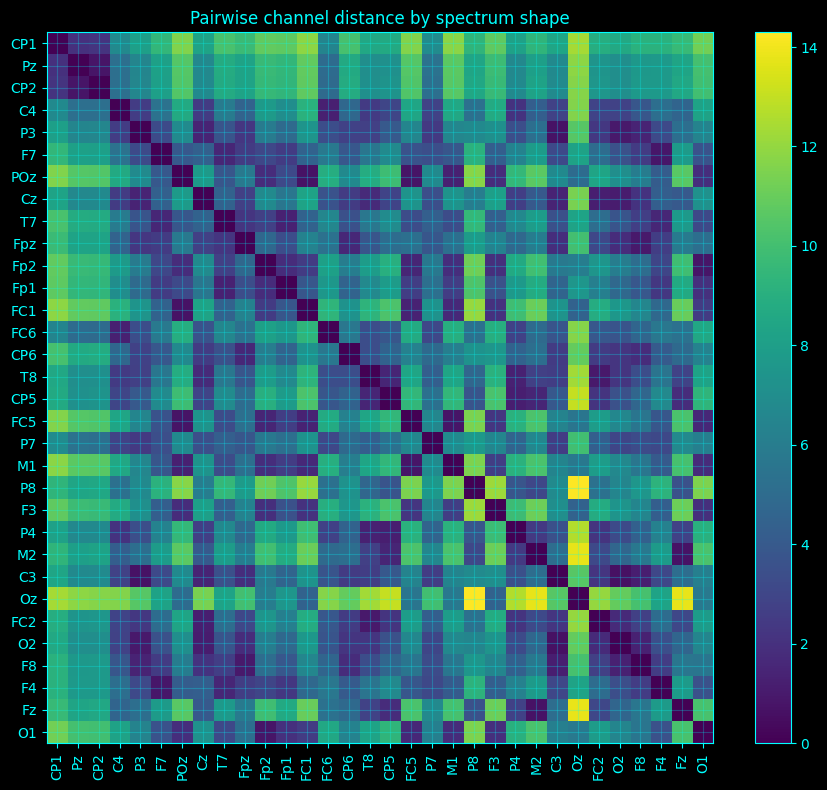


Saved outputs to: /home/a/projects/Complete-Neural-Signal-Analysis/mfdfa_cross_channel_clustering
Cluster assignments: /home/a/projects/Complete-Neural-Signal-Analysis/mfdfa_cross_channel_clustering/cross_channel_cluster_assignments.csv
Cluster mean curves: /home/a/projects/Complete-Neural-Signal-Analysis/mfdfa_cross_channel_clustering/cluster_mean_curves.csv
PCA scatter: /home/a/projects/Complete-Neural-Signal-Analysis/mfdfa_cross_channel_clustering/cluster_pca_scatter.png
Mean h(q): /home/a/projects/Complete-Neural-Signal-Analysis/mfdfa_cross_channel_clustering/cluster_mean_hq.png
Mean f(alpha): /home/a/projects/Complete-Neural-Signal-Analysis/mfdfa_cross_channel_clustering/cluster_mean_falpha.png
Distance matrix: /home/a/projects/Complete-Neural-Signal-Analysis/mfdfa_cross_channel_clustering/pairwise_distance_matrix.png
Text summary: /home/a/projects/Complete-Neural-Signal-Analysis/mfdfa_cross_channel_clustering/cluster_summary.txt


In [16]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
source_dir = os.path.join(base_dir, "mfdfa_manual_spectrum_results")
summary_path = os.path.join(source_dir, "mfdfa_manual_spectrum_summary.csv")

out_dir = os.path.join(base_dir, "mfdfa_cross_channel_clustering")
os.makedirs(out_dir, exist_ok=True)

eeg_channels = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

# Clustering settings
n_clusters = 4
n_init = 50
max_iter = 300
seed = 0

# Use full curve shape, not just width
use_hq = True
use_falpha = True
use_tau = False   # set True if you want to include tau(q) too

# Plot style
ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

# -------------------------------------------------------
# STYLE HELPER
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.grid(True, alpha=0.25, color=ACCENT)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
    ax.xaxis.label.set_color(ACCENT)
    ax.yaxis.label.set_color(ACCENT)
    ax.title.set_color(ACCENT)

# -------------------------------------------------------
# NUMERICAL HELPERS
# -------------------------------------------------------
def fill_nan_interp(y):
    y = np.asarray(y, dtype=float)
    idx = np.arange(len(y))
    valid = np.isfinite(y)

    if np.sum(valid) == 0:
        return None
    if np.sum(valid) == 1:
        out = np.full_like(y, y[valid][0], dtype=float)
        return out

    out = y.copy()
    out[~valid] = np.interp(idx[~valid], idx[valid], y[valid])
    return out

def zscore_vector(y, eps=1e-12):
    y = np.asarray(y, dtype=float)
    mu = np.mean(y)
    sd = np.std(y)
    if not np.isfinite(sd) or sd < eps:
        return np.zeros_like(y)
    return (y - mu) / sd

def build_shape_feature(hq, tau, f_alpha):
    parts = []

    if use_hq:
        hq_f = fill_nan_interp(hq)
        if hq_f is None:
            return None
        parts.append(zscore_vector(hq_f))

    if use_tau:
        tau_f = fill_nan_interp(tau)
        if tau_f is None:
            return None
        parts.append(zscore_vector(tau_f))

    if use_falpha:
        f_f = fill_nan_interp(f_alpha)
        if f_f is None:
            return None
        parts.append(zscore_vector(f_f))

    if len(parts) == 0:
        return None

    return np.concatenate(parts)

def pairwise_distance_matrix(X):
    X = np.asarray(X, dtype=float)
    sq = np.sum(X**2, axis=1, keepdims=True)
    D2 = np.maximum(sq + sq.T - 2 * (X @ X.T), 0.0)
    return np.sqrt(D2)

# -------------------------------------------------------
# MANUAL K-MEANS
# -------------------------------------------------------
def kmeans_manual(X, k, n_init=20, max_iter=200, seed=0):
    X = np.asarray(X, dtype=float)
    n, p = X.shape
    rng = np.random.default_rng(seed)

    best = None

    for run in range(n_init):
        init_idx = rng.choice(n, size=k, replace=False)
        centers = X[init_idx].copy()

        labels = np.full(n, -1, dtype=int)

        for _ in range(max_iter):
            # assign
            d2 = np.sum((X[:, None, :] - centers[None, :, :])**2, axis=2)
            new_labels = np.argmin(d2, axis=1)

            if np.array_equal(new_labels, labels):
                break

            labels = new_labels

            # update
            for j in range(k):
                mask = labels == j
                if np.any(mask):
                    centers[j] = np.mean(X[mask], axis=0)
                else:
                    # re-seed empty cluster
                    centers[j] = X[rng.integers(0, n)]

        inertia = np.sum((X - centers[labels])**2)

        if best is None or inertia < best["inertia"]:
            best = {
                "labels": labels.copy(),
                "centers": centers.copy(),
                "inertia": float(inertia),
            }

    return best["labels"], best["centers"], best["inertia"]

# -------------------------------------------------------
# MANUAL PCA VIA SVD
# -------------------------------------------------------
def pca_2d(X):
    X = np.asarray(X, dtype=float)
    Xc = X - np.mean(X, axis=0, keepdims=True)
    U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
    scores = Xc @ Vt[:2].T

    var = (S**2) / max(X.shape[0] - 1, 1)
    frac = var / np.sum(var)

    return scores, Vt[:2], frac[:2]

# -------------------------------------------------------
# LOAD SAVED PER-CHANNEL MFDFA RESULTS
# -------------------------------------------------------
rows = []
q_ref = None

for ch in eeg_channels:
    npz_path = os.path.join(source_dir, f"{ch}_mfdfa_manual_spectrum.npz")
    if not os.path.exists(npz_path):
        print(f"Missing file for {ch}: {npz_path}")
        continue

    dat = np.load(npz_path, allow_pickle=True)

    q_vals = np.asarray(dat["q_vals"], dtype=float)
    hq = np.asarray(dat["hq"], dtype=float)
    tau = np.asarray(dat["tau"], dtype=float)
    f_alpha = np.asarray(dat["f_alpha"], dtype=float)

    if q_ref is None:
        q_ref = q_vals.copy()
    else:
        if len(q_vals) != len(q_ref) or not np.allclose(q_vals, q_ref):
            raise ValueError(f"q-grid mismatch for channel {ch}")

    feat = build_shape_feature(hq, tau, f_alpha)
    if feat is None:
        print(f"Skipping {ch}: could not build feature vector")
        continue

    rows.append({
        "channel": ch,
        "q_vals": q_vals,
        "hq": hq,
        "tau": tau,
        "f_alpha": f_alpha,
        "feature": feat
    })

if len(rows) < n_clusters:
    raise RuntimeError(f"Need at least {n_clusters} usable channels, got {len(rows)}")

channels = [r["channel"] for r in rows]
X = np.vstack([r["feature"] for r in rows])

# -------------------------------------------------------
# CLUSTER
# -------------------------------------------------------
labels, centers, inertia = kmeans_manual(
    X, k=n_clusters, n_init=n_init, max_iter=max_iter, seed=seed
)

# PCA projection for visualization
scores, pcs, explained = pca_2d(X)

# Optional merge with summary widths
if os.path.exists(summary_path):
    summary_df = pd.read_csv(summary_path)
else:
    summary_df = pd.DataFrame(columns=["channel", "alpha_width", "alpha_at_peak", "asymmetry"])

cluster_df = pd.DataFrame({
    "channel": channels,
    "cluster": labels,
    "pc1": scores[:, 0],
    "pc2": scores[:, 1],
})
cluster_df = cluster_df.merge(summary_df, on="channel", how="left")
cluster_df = cluster_df.sort_values(["cluster", "pc1"]).reset_index(drop=True)

cluster_csv = os.path.join(out_dir, "cross_channel_cluster_assignments.csv")
cluster_df.to_csv(cluster_csv, index=False)

print("Cluster assignments:")
print(cluster_df)
print("\nK-means inertia:", inertia)
print("Explained variance (PC1, PC2):", explained)

# -------------------------------------------------------
# CLUSTER-AVERAGE CURVES
# -------------------------------------------------------
cluster_curve_rows = []

for cl in range(n_clusters):
    idx = np.where(labels == cl)[0]
    if len(idx) == 0:
        continue

    hq_stack = np.vstack([rows[i]["hq"] for i in idx])
    falpha_stack = np.vstack([rows[i]["f_alpha"] for i in idx])

    hq_mean = np.nanmean(hq_stack, axis=0)
    hq_std = np.nanstd(hq_stack, axis=0)

    falpha_mean = np.nanmean(falpha_stack, axis=0)
    falpha_std = np.nanstd(falpha_stack, axis=0)

    for qi, q in enumerate(q_ref):
        cluster_curve_rows.append({
            "cluster": cl,
            "q": q,
            "hq_mean": hq_mean[qi],
            "hq_std": hq_std[qi],
            "falpha_mean": falpha_mean[qi],
            "falpha_std": falpha_std[qi],
        })

cluster_curve_df = pd.DataFrame(cluster_curve_rows)
cluster_curve_csv = os.path.join(out_dir, "cluster_mean_curves.csv")
cluster_curve_df.to_csv(cluster_curve_csv, index=False)

# -------------------------------------------------------
# 1) PCA SCATTER OF CHANNELS
# -------------------------------------------------------
markers = ['o', 's', '^', 'D', 'v', 'P', 'X', '*']

fig, ax = plt.subplots(figsize=(9, 7), facecolor=BG)
style_ax(ax)

for cl in range(n_clusters):
    mask = cluster_df["cluster"] == cl
    if np.sum(mask) == 0:
        continue

    m = markers[cl % len(markers)]
    ax.scatter(
        cluster_df.loc[mask, "pc1"],
        cluster_df.loc[mask, "pc2"],
        s=120,
        marker=m,
        facecolors="none",
        edgecolors=ACCENT,
        linewidths=1.5,
        label=f"Cluster {cl}"
    )

for _, row in cluster_df.iterrows():
    ax.text(row["pc1"], row["pc2"], row["channel"], fontsize=9, color=ACCENT)

ax.set_title("Cross-channel clustering by spectrum shape")
ax.set_xlabel(f"PC1 ({explained[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({explained[1]*100:.1f}% var)")
ax.legend()

pca_path = os.path.join(out_dir, "cluster_pca_scatter.png")
plt.tight_layout()
plt.savefig(pca_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# 2) CLUSTER-MEAN h(q)
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5), facecolor=BG)
style_ax(ax)

linestyles = ['-', '--', '-.', ':']

for cl in range(n_clusters):
    dfc = cluster_curve_df[cluster_curve_df["cluster"] == cl]
    if len(dfc) == 0:
        continue

    ls = linestyles[cl % len(linestyles)]
    ax.plot(
        dfc["q"], dfc["hq_mean"],
        linestyle=ls,
        color=ACCENT,
        marker='o',
        markerfacecolor=ACCENT,
        markeredgecolor=ACCENT,
        alpha=0.9,
        label=f"Cluster {cl}"
    )

ax.set_title("Cluster-average h(q)")
ax.set_xlabel("q")
ax.set_ylabel("h(q)")
ax.legend()

hq_path = os.path.join(out_dir, "cluster_mean_hq.png")
plt.tight_layout()
plt.savefig(hq_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# 3) CLUSTER-MEAN f(alpha) vs q-index-aligned values
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5), facecolor=BG)
style_ax(ax)

for cl in range(n_clusters):
    dfc = cluster_curve_df[cluster_curve_df["cluster"] == cl]
    if len(dfc) == 0:
        continue

    ls = linestyles[cl % len(linestyles)]
    ax.plot(
        dfc["q"], dfc["falpha_mean"],
        linestyle=ls,
        color=ACCENT,
        marker='o',
        markerfacecolor=ACCENT,
        markeredgecolor=ACCENT,
        alpha=0.9,
        label=f"Cluster {cl}"
    )

ax.set_title("Cluster-average f(alpha) (q-index aligned)")
ax.set_xlabel("q")
ax.set_ylabel("f(alpha)")
ax.legend()

fa_path = os.path.join(out_dir, "cluster_mean_falpha.png")
plt.tight_layout()
plt.savefig(fa_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# 4) PAIRWISE DISTANCE MATRIX SORTED BY CLUSTER
# -------------------------------------------------------
D = pairwise_distance_matrix(X)

sort_idx = np.argsort(cluster_df["cluster"].values * 1000 + np.argsort(cluster_df["pc1"].values))
cluster_df_sorted = cluster_df.iloc[sort_idx].reset_index(drop=True)
D_sorted = D[sort_idx][:, sort_idx]

fig, ax = plt.subplots(figsize=(9, 8), facecolor=BG)
style_ax(ax)

im = ax.imshow(D_sorted, aspect="auto")
ax.set_title("Pairwise channel distance by spectrum shape")
ax.set_xticks(np.arange(len(cluster_df_sorted)))
ax.set_xticklabels(cluster_df_sorted["channel"], rotation=90, color=ACCENT)
ax.set_yticks(np.arange(len(cluster_df_sorted)))
ax.set_yticklabels(cluster_df_sorted["channel"], color=ACCENT)

cbar = plt.colorbar(im, ax=ax)
cbar.ax.yaxis.set_tick_params(color=ACCENT)
plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)

dist_path = os.path.join(out_dir, "pairwise_distance_matrix.png")
plt.tight_layout()
plt.savefig(dist_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# 5) TEXT SUMMARY PER CLUSTER
# -------------------------------------------------------
txt_path = os.path.join(out_dir, "cluster_summary.txt")
with open(txt_path, "w") as f:
    f.write("Cross-channel clustering by multifractal spectrum shape\n")
    f.write("=====================================================\n\n")
    f.write(f"Number of clusters: {n_clusters}\n")
    f.write(f"Inertia: {inertia}\n")
    f.write(f"Explained variance PC1: {explained[0]:.6f}\n")
    f.write(f"Explained variance PC2: {explained[1]:.6f}\n\n")

    for cl in range(n_clusters):
        members = cluster_df[cluster_df["cluster"] == cl]["channel"].tolist()
        f.write(f"Cluster {cl} ({len(members)} channels):\n")
        f.write(", ".join(members) + "\n\n")

print("\nSaved outputs to:", out_dir)
print("Cluster assignments:", cluster_csv)
print("Cluster mean curves:", cluster_curve_csv)
print("PCA scatter:", pca_path)
print("Mean h(q):", hq_path)
print("Mean f(alpha):", fa_path)
print("Distance matrix:", dist_path)
print("Text summary:", txt_path)

Asymmetry decomposition table:
   channel  alpha_min  alpha_at_peak  alpha_max  left_width  right_width  \
0       C3   0.765867       0.882090   0.882090    0.116223     0.000000   
1       C4   0.756056       0.864513   0.864513    0.108457     0.000000   
2      CP1   0.694686       0.862500   0.862500    0.167814     0.000000   
3      CP2   0.732067       0.945807   0.945807    0.213740     0.000000   
4      CP5   0.748152       0.810350   0.866648    0.062198     0.056297   
5      CP6   0.794090       0.861600   0.948815    0.067510     0.087215   
6       Cz   0.771201       0.889686   0.889686    0.118485     0.000000   
7       F3   0.813601       0.884610   0.884761    0.071009     0.000151   
8       F4   0.854307       0.946370   0.967664    0.092064     0.021294   
9       F7   0.808386       0.879728   0.879728    0.071342     0.000000   
10      F8   0.843007       0.887478   0.917111    0.044471     0.029634   
11     FC1   0.791435       0.874228   0.907689    0.0827

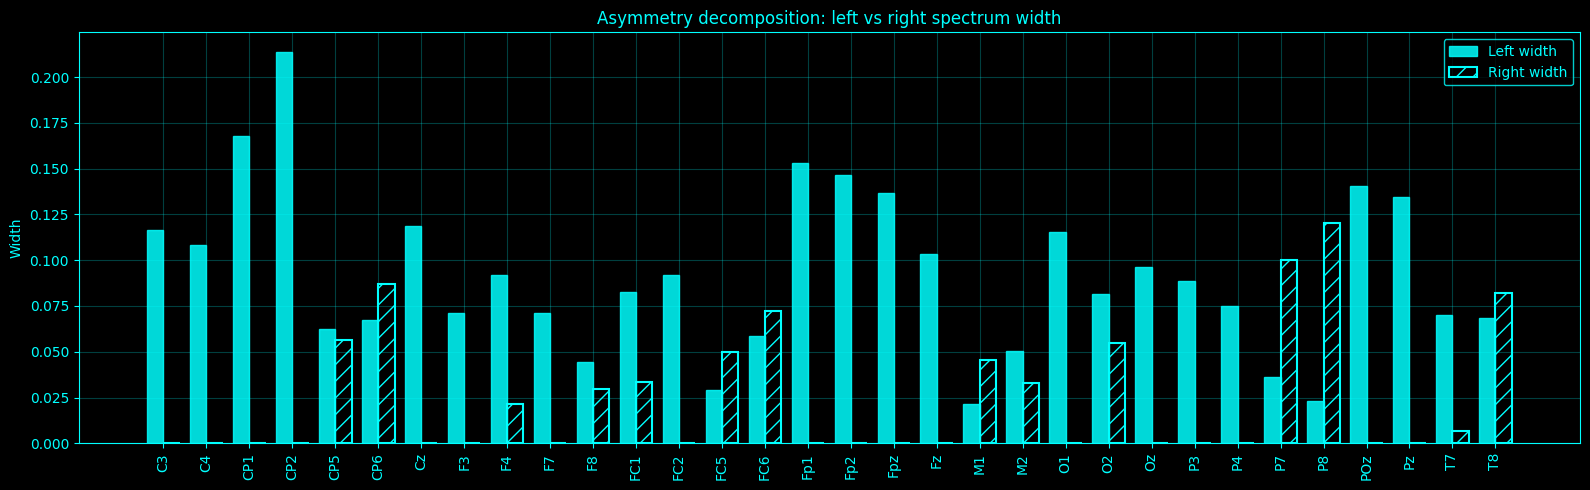

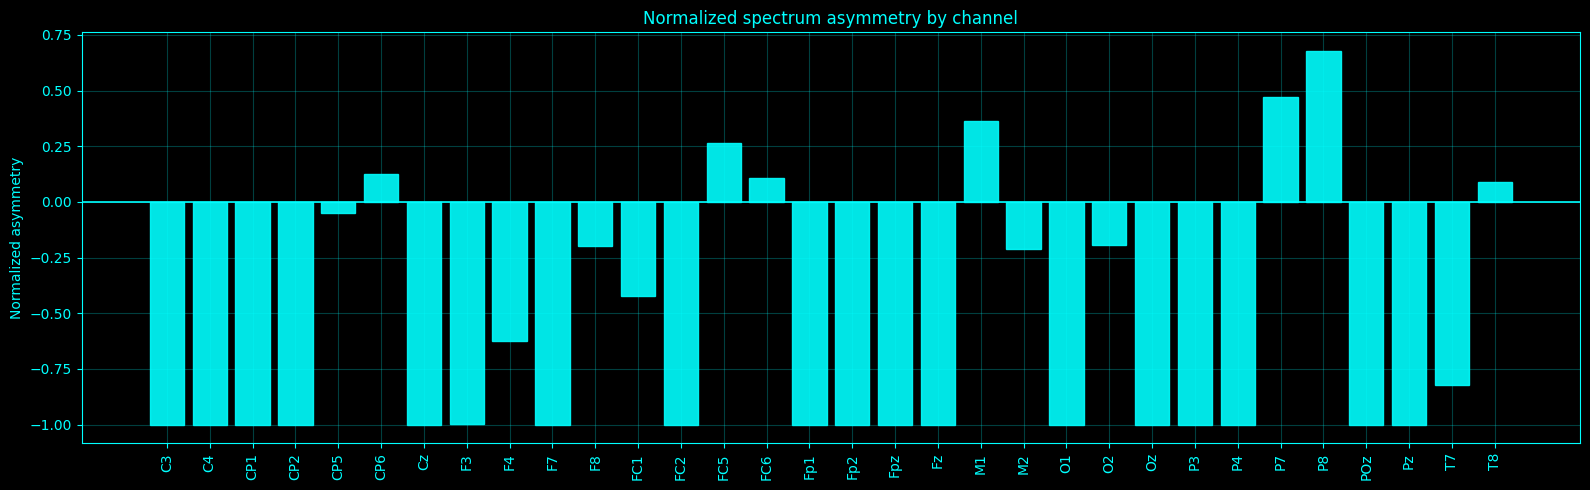

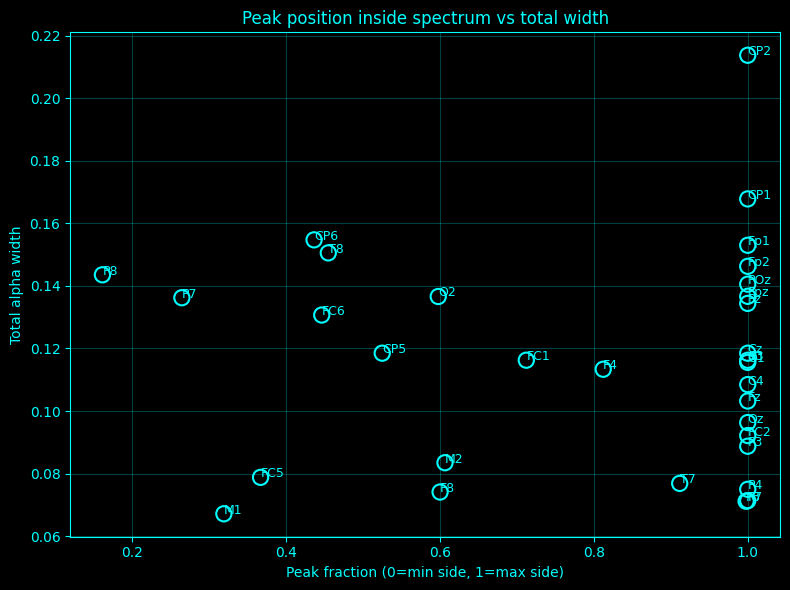


Top broader-left-side channels:
   channel  left_width  right_width  asymmetry_norm
0       C3    0.116223          0.0            -1.0
29      Pz    0.134411          0.0            -1.0
28     POz    0.140558          0.0            -1.0
25      P4    0.074976          0.0            -1.0
24      P3    0.088748          0.0            -1.0
23      Oz    0.096316          0.0            -1.0
21      O1    0.115548          0.0            -1.0
18      Fz    0.103202          0.0            -1.0
17     Fpz    0.136676          0.0            -1.0
16     Fp2    0.146259          0.0            -1.0

Top broader-right-side channels:
   channel  left_width  right_width  asymmetry_norm
27      P8    0.023143     0.120412        0.677576
26      P7    0.036031     0.100195        0.471015
19      M1    0.021424     0.045722        0.361877
13     FC5    0.028900     0.049899        0.266478
5      CP6    0.067510     0.087215        0.127354
14     FC6    0.058326     0.072362        0.1074

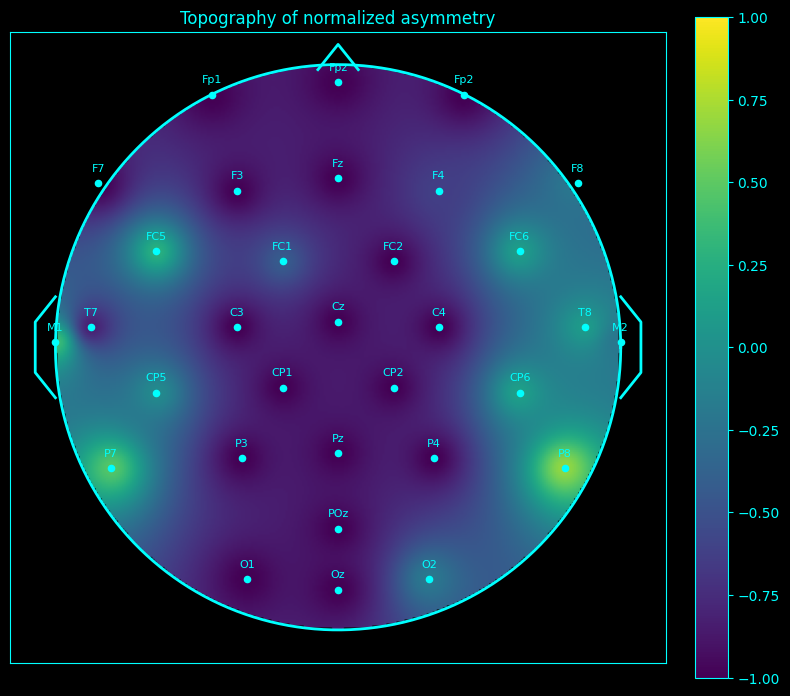


Saved outputs to: /home/a/projects/Complete-Neural-Signal-Analysis/mfdfa_asymmetry_decomposition
Main table: /home/a/projects/Complete-Neural-Signal-Analysis/mfdfa_asymmetry_decomposition/asymmetry_decomposition_table.csv
Left/right widths plot: /home/a/projects/Complete-Neural-Signal-Analysis/mfdfa_asymmetry_decomposition/left_vs_right_width.png
Normalized asymmetry plot: /home/a/projects/Complete-Neural-Signal-Analysis/mfdfa_asymmetry_decomposition/normalized_asymmetry_bar.png
Peak-vs-width plot: /home/a/projects/Complete-Neural-Signal-Analysis/mfdfa_asymmetry_decomposition/peak_fraction_vs_width.png
Topography: /home/a/projects/Complete-Neural-Signal-Analysis/mfdfa_asymmetry_decomposition/asymmetry_topography.png
Left-dominant CSV: /home/a/projects/Complete-Neural-Signal-Analysis/mfdfa_asymmetry_decomposition/top_left_dominant_channels.csv
Right-dominant CSV: /home/a/projects/Complete-Neural-Signal-Analysis/mfdfa_asymmetry_decomposition/top_right_dominant_channels.csv
Summary text:

In [17]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
summary_path = os.path.join(
    base_dir,
    "mfdfa_manual_spectrum_results",
    "mfdfa_manual_spectrum_summary.csv"
)

out_dir = os.path.join(base_dir, "mfdfa_asymmetry_decomposition")
os.makedirs(out_dir, exist_ok=True)

ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

# -------------------------------------------------------
# STYLE HELPER
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.grid(True, alpha=0.25, color=ACCENT)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
    ax.xaxis.label.set_color(ACCENT)
    ax.yaxis.label.set_color(ACCENT)
    ax.title.set_color(ACCENT)

# -------------------------------------------------------
# LOAD SUMMARY
# -------------------------------------------------------
df = pd.read_csv(summary_path)

required = {
    "channel",
    "alpha_min",
    "alpha_max",
    "alpha_width",
    "alpha_at_peak",
    "f_peak",
    "asymmetry",
}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# -------------------------------------------------------
# ASYMMETRY DECOMPOSITION
# -------------------------------------------------------
# left side of spectrum: from alpha_min to peak
df["left_width"] = df["alpha_at_peak"] - df["alpha_min"]

# right side of spectrum: from peak to alpha_max
df["right_width"] = df["alpha_max"] - df["alpha_at_peak"]

# recomputed total width for consistency check
df["width_recomputed"] = df["left_width"] + df["right_width"]

# signed asymmetry: positive => broader right side, negative => broader left side
df["asymmetry_signed"] = df["right_width"] - df["left_width"]

# normalized asymmetry in [-1, 1]
df["asymmetry_norm"] = df["asymmetry_signed"] / np.maximum(df["width_recomputed"], 1e-12)

# peak position inside the spectrum
# 0 = peak at alpha_min, 1 = peak at alpha_max
df["peak_fraction"] = df["left_width"] / np.maximum(df["width_recomputed"], 1e-12)

# side dominance labels
def classify_side(row):
    if row["asymmetry_signed"] > 1e-10:
        return "broader_right_side"
    elif row["asymmetry_signed"] < -1e-10:
        return "broader_left_side"
    else:
        return "balanced"

df["side_dominance"] = df.apply(classify_side, axis=1)

# peak locking diagnostics
df["peak_locked_min"] = np.isclose(df["alpha_at_peak"], df["alpha_min"])
df["peak_locked_max"] = np.isclose(df["alpha_at_peak"], df["alpha_max"])

# sort for readability
df = df.sort_values("channel").reset_index(drop=True)

# save table
csv_path = os.path.join(out_dir, "asymmetry_decomposition_table.csv")
df.to_csv(csv_path, index=False)

print("Asymmetry decomposition table:")
print(df[[
    "channel",
    "alpha_min",
    "alpha_at_peak",
    "alpha_max",
    "left_width",
    "right_width",
    "alpha_width",
    "asymmetry_signed",
    "asymmetry_norm",
    "peak_fraction",
    "side_dominance",
    "peak_locked_min",
    "peak_locked_max",
]].round(6))

# -------------------------------------------------------
# 1) LEFT VS RIGHT WIDTH PER CHANNEL
# -------------------------------------------------------
x = np.arange(len(df))
w = 0.38

fig, ax = plt.subplots(figsize=(16, 5), facecolor=BG)
style_ax(ax)

ax.bar(
    x - w/2,
    df["left_width"],
    width=w,
    color=ACCENT,
    edgecolor=ACCENT,
    alpha=0.85,
    label="Left width"
)
ax.bar(
    x + w/2,
    df["right_width"],
    width=w,
    color="none",
    edgecolor=ACCENT,
    hatch="//",
    linewidth=1.5,
    label="Right width"
)

ax.set_xticks(x)
ax.set_xticklabels(df["channel"], rotation=90)
ax.set_ylabel("Width")
ax.set_title("Asymmetry decomposition: left vs right spectrum width")
ax.legend()

left_right_path = os.path.join(out_dir, "left_vs_right_width.png")
plt.tight_layout()
plt.savefig(left_right_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# 2) NORMALIZED ASYMMETRY BAR PLOT
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(16, 5), facecolor=BG)
style_ax(ax)

ax.bar(
    x,
    df["asymmetry_norm"],
    color=ACCENT,
    edgecolor=ACCENT,
    alpha=0.9
)
ax.axhline(0, color=ACCENT, linewidth=1.2)

ax.set_xticks(x)
ax.set_xticklabels(df["channel"], rotation=90)
ax.set_ylabel("Normalized asymmetry")
ax.set_title("Normalized spectrum asymmetry by channel")

asym_bar_path = os.path.join(out_dir, "normalized_asymmetry_bar.png")
plt.tight_layout()
plt.savefig(asym_bar_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# 3) PEAK POSITION VS TOTAL WIDTH
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6), facecolor=BG)
style_ax(ax)

ax.scatter(
    df["peak_fraction"],
    df["alpha_width"],
    s=120,
    facecolors="none",
    edgecolors=ACCENT,
    linewidths=1.5
)

for _, row in df.iterrows():
    ax.text(row["peak_fraction"], row["alpha_width"], row["channel"], fontsize=9, color=ACCENT)

ax.set_xlabel("Peak fraction (0=min side, 1=max side)")
ax.set_ylabel("Total alpha width")
ax.set_title("Peak position inside spectrum vs total width")

scatter_path = os.path.join(out_dir, "peak_fraction_vs_width.png")
plt.tight_layout()
plt.savefig(scatter_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# 4) TOP CHANNELS BY LEFT/RIGHT DOMINANCE
# -------------------------------------------------------
left_dom = df.sort_values("asymmetry_norm").head(10)[
    ["channel", "left_width", "right_width", "asymmetry_norm"]
].copy()

right_dom = df.sort_values("asymmetry_norm", ascending=False).head(10)[
    ["channel", "left_width", "right_width", "asymmetry_norm"]
].copy()

left_dom_path = os.path.join(out_dir, "top_left_dominant_channels.csv")
right_dom_path = os.path.join(out_dir, "top_right_dominant_channels.csv")
left_dom.to_csv(left_dom_path, index=False)
right_dom.to_csv(right_dom_path, index=False)

print("\nTop broader-left-side channels:")
print(left_dom.round(6))

print("\nTop broader-right-side channels:")
print(right_dom.round(6))

# -------------------------------------------------------
# 5) MANUAL TOPOGRAPHY OF NORMALIZED ASYMMETRY
# -------------------------------------------------------
channel_pos = {
    "Fp1": (-0.50,  1.00),
    "Fpz": ( 0.00,  1.05),
    "Fp2": ( 0.50,  1.00),

    "F7":  (-0.95,  0.65),
    "F3":  (-0.40,  0.62),
    "Fz":  ( 0.00,  0.67),
    "F4":  ( 0.40,  0.62),
    "F8":  ( 0.95,  0.65),

    "FC5": (-0.72,  0.38),
    "FC1": (-0.22,  0.34),
    "FC2": ( 0.22,  0.34),
    "FC6": ( 0.72,  0.38),

    "M1":  (-1.12,  0.02),
    "T7":  (-0.98,  0.08),
    "C3":  (-0.40,  0.08),
    "Cz":  ( 0.00,  0.10),
    "C4":  ( 0.40,  0.08),
    "T8":  ( 0.98,  0.08),
    "M2":  ( 1.12,  0.02),

    "CP5": (-0.72, -0.18),
    "CP1": (-0.22, -0.16),
    "CP2": ( 0.22, -0.16),
    "CP6": ( 0.72, -0.18),

    "P7":  (-0.90, -0.48),
    "P3":  (-0.38, -0.44),
    "Pz":  ( 0.00, -0.42),
    "P4":  ( 0.38, -0.44),
    "P8":  ( 0.90, -0.48),

    "POz": ( 0.00, -0.72),
    "O1":  (-0.36, -0.92),
    "Oz":  ( 0.00, -0.96),
    "O2":  ( 0.36, -0.92),
}

topo_df = df[df["channel"].isin(channel_pos.keys())].copy()
topo_df["x"] = topo_df["channel"].map(lambda c: channel_pos[c][0])
topo_df["y"] = topo_df["channel"].map(lambda c: channel_pos[c][1])

def idw_interpolate(xy_points, values, grid_x, grid_y, power=2, eps=1e-12):
    gx = grid_x[..., None]
    gy = grid_y[..., None]
    px = xy_points[:, 0][None, None, :]
    py = xy_points[:, 1][None, None, :]
    dist2 = (gx - px)**2 + (gy - py)**2
    dist2 = np.maximum(dist2, eps)
    weights = 1.0 / (dist2 ** (power / 2.0))
    z = np.sum(weights * values[None, None, :], axis=2) / np.sum(weights, axis=2)
    return z

theta = np.linspace(0, 2*np.pi, 400)
head_r = 1.12
head_x = head_r * np.cos(theta)
head_y = head_r * np.sin(theta)

nose_x = np.array([-0.08, 0.00, 0.08])
nose_y = np.array([1.10, 1.20, 1.10])

ear_left_x  = np.array([-1.12, -1.20, -1.20, -1.12])
ear_left_y  = np.array([ 0.20,  0.10, -0.10, -0.20])
ear_right_x = -ear_left_x
ear_right_y = ear_left_y

gx = np.linspace(-1.2, 1.2, 300)
gy = np.linspace(-1.2, 1.2, 300)
GX, GY = np.meshgrid(gx, gy)

points = topo_df[["x", "y"]].values
values = topo_df["asymmetry_norm"].values.astype(float)

Z = idw_interpolate(points, values, GX, GY, power=2)
mask = (GX**2 + GY**2) <= (head_r**2)
Z_masked = np.where(mask, Z, np.nan)

fig, ax = plt.subplots(figsize=(8, 8), facecolor=BG)
style_ax(ax)

im = ax.imshow(
    Z_masked,
    origin="lower",
    extent=[gx.min(), gx.max(), gy.min(), gy.max()],
    aspect="equal",
    vmin=-np.nanmax(np.abs(values)),
    vmax= np.nanmax(np.abs(values)),
)

ax.scatter(topo_df["x"], topo_df["y"], color=ACCENT, s=20)

for _, row in topo_df.iterrows():
    ax.text(row["x"], row["y"] + 0.04, row["channel"], ha="center", va="bottom", fontsize=8, color=ACCENT)

ax.plot(head_x, head_y, color=ACCENT, linewidth=2)
ax.plot(nose_x, nose_y, color=ACCENT, linewidth=2)
ax.plot(ear_left_x, ear_left_y, color=ACCENT, linewidth=2)
ax.plot(ear_right_x, ear_right_y, color=ACCENT, linewidth=2)

ax.set_title("Topography of normalized asymmetry")
ax.set_xlim(-1.3, 1.3)
ax.set_ylim(-1.25, 1.25)
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.yaxis.set_tick_params(color=ACCENT)
plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)

topo_path = os.path.join(out_dir, "asymmetry_topography.png")
plt.tight_layout()
plt.savefig(topo_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# 6) TEXT SUMMARY
# -------------------------------------------------------
txt_path = os.path.join(out_dir, "asymmetry_summary.txt")
with open(txt_path, "w") as f:
    f.write("Asymmetry decomposition of multifractal spectrum\n")
    f.write("===============================================\n\n")
    f.write("Definitions:\n")
    f.write("left_width  = alpha_at_peak - alpha_min\n")
    f.write("right_width = alpha_max - alpha_at_peak\n")
    f.write("signed_asymmetry = right_width - left_width\n")
    f.write("normalized_asymmetry = (right_width - left_width) / (left_width + right_width)\n\n")

    f.write("Most broader-left-side channels:\n")
    for _, row in left_dom.iterrows():
        f.write(f"{row['channel']}: asym_norm={row['asymmetry_norm']:.6f}\n")

    f.write("\nMost broader-right-side channels:\n")
    for _, row in right_dom.iterrows():
        f.write(f"{row['channel']}: asym_norm={row['asymmetry_norm']:.6f}\n")

print("\nSaved outputs to:", out_dir)
print("Main table:", csv_path)
print("Left/right widths plot:", left_right_path)
print("Normalized asymmetry plot:", asym_bar_path)
print("Peak-vs-width plot:", scatter_path)
print("Topography:", topo_path)
print("Left-dominant CSV:", left_dom_path)
print("Right-dominant CSV:", right_dom_path)
print("Summary text:", txt_path)